In [16]:
import sys
# sys.path.append('/home/cmu/github/LPBFDiffusionSR/datasets')
import numpy as np
from pylab import gca
import numpy as np
import math
from tqdm import tqdm
import torch
import torchvision
import torch.nn as nn
from torch.utils import data
import torch.nn.functional as F
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import MNIST
import torchvision.transforms.functional as TF
from torch.optim import lr_scheduler
import time
import os
from skimage.metrics import structural_similarity as ssim_id

import cv2
import os
from torchvision import transforms
from torch.utils.data import DataLoader
from pathlib import Path
from torch.utils.data import Dataset
import pdb
from PIL import Image
import matplotlib.pyplot as plt 
# print(os.listdir('.'))
# from datasets.dataset import TemperatureXZDataset
from runners.train_diffusion import forwardpass
from analysis_functions import predict_lrenc, predict_mobilenet, predict_ddim_diffusion,predict_modified_diffusion, predict_diffusion, plot_images, get_profile, load_mobilenet, load_encoder, load_diffusion, PSNR, SSIM, multifield_plot_images

In [17]:
def frame_tick(frame_width = 2, tick_width = 1.5):
    ax = gca()
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(frame_width)
    plt.tick_params(direction = 'in', 
                    width = tick_width)
def legend(location = 'best', fontsize = 8):
        plt.legend(loc = location, fontsize = fontsize, frameon = False)

### Define results directory

In [18]:
diffusion_results_dir = '/home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_03_20_16_11_43/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_03_19_22_56_20/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_03_17_03_43_34/rescaling/n_steps_1'
encoder_results_dir = '/home/oogoke/DiffusionSR/runs/direct/encoder/2023_03_20_16_11_43/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_03_19_22_56_20/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_03_17_03_43_34/rescaling/n_steps_1'
mobilenet_results_dir = '/home/oogoke/DiffusionSR/runs/clean/direct/mobilenet/2022_12_05_03_17_09'


### Plot Train, Test Loss for diffusion

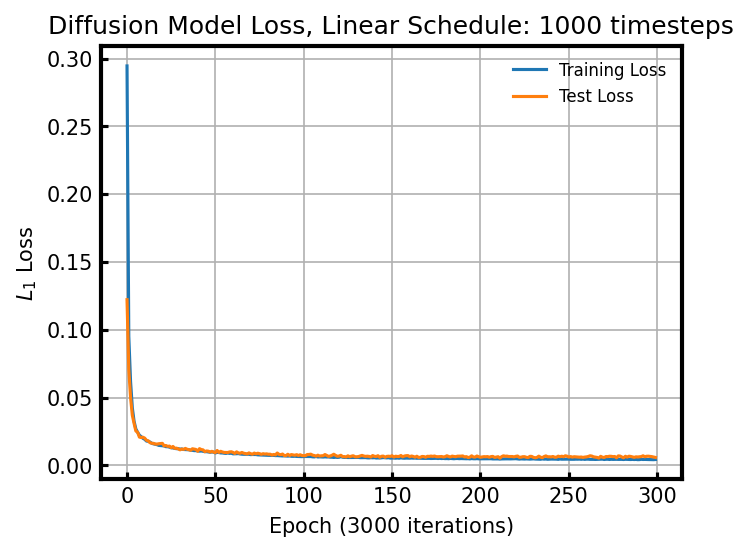

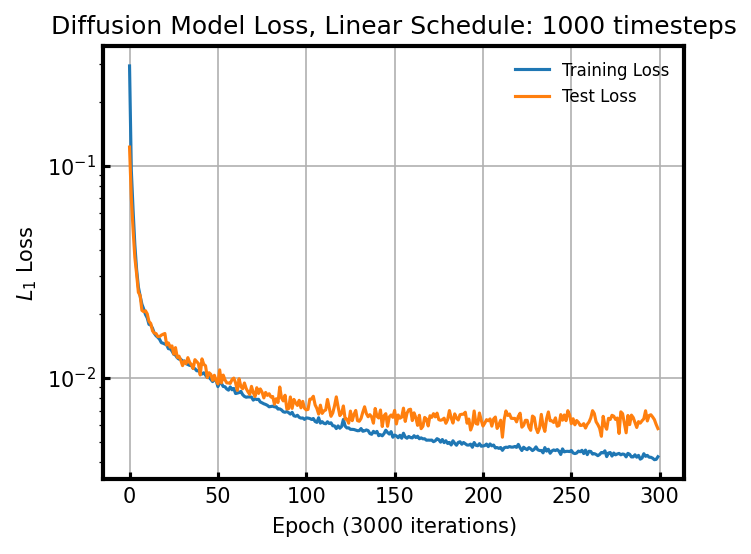

In [19]:
import numpy as np
test_loss = np.loadtxt(os.path.join(diffusion_results_dir, 'validation_loss_epoch.txt'))
train_loss = np.loadtxt(os.path.join(diffusion_results_dir, 'loss_epoch.txt'))

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss[:], label = 'Test Loss')

# plt.plot(np.mean(test_loss[:24*70].reshape(-1, 24), axis=1), label = "Validation Loss")

plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()

plt.title('Diffusion Model Loss, Linear Schedule: 1000 timesteps')
plt.grid(which = 'major')
frame_tick()

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss[:], label = 'Test Loss')

# plt.plot(np.mean(test_loss[:24*70].reshape(-1, 24), axis=1), label = "Validation Loss")

plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()

plt.title('Diffusion Model Loss, Linear Schedule: 1000 timesteps')
plt.grid(which = 'major')
frame_tick()
plt.yscale('log')

In [20]:
p_dir = '/home/oogoke/DiffusionSR/runs/clean/direct/diffusionno_residual'
sub_p_dirs = ['2022_12_19_02_51_24/standardize/n_steps_1', '2022_12_19_02_51_11/standardize/n_steps_1']
timesteps = [1000, 1500]

In [21]:

class Simulation():
    def __init__(self, folder, diff_steps, schedule):
        self.folder = folder
        self.diff_steps = diff_steps
        self.schedule = schedule
        self.kp = None
        self.profile = None
        self.max_depth = None
        self.kp_depth = None
    def get_loss_curve(self):
        test_loss = np.loadtxt(os.path.join(self.folder, 'test_loss_epoch.txt'))
        train_loss = np.loadtxt(os.path.join(self.folder, 'loss_epoch.txt'))
        return train_loss, test_loss
simlinear1000 = Simulation(os.path.join(p_dir, '2022_12_19_02_51_24/standardize/n_steps_1'), 1000, 'linear')


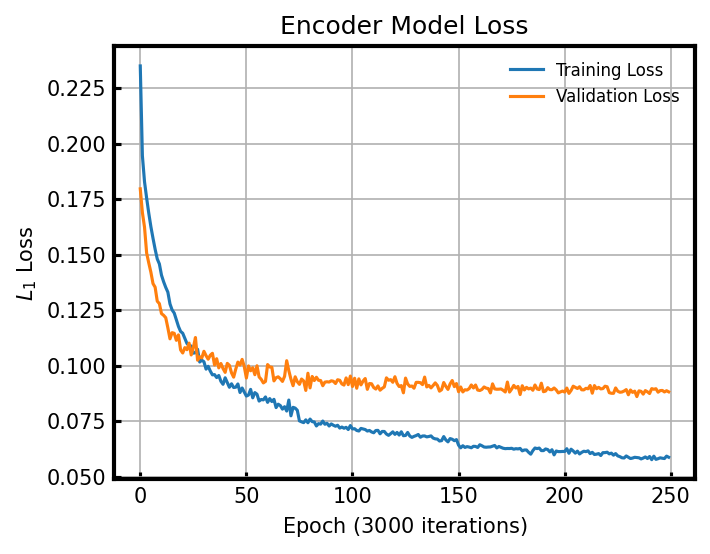

In [22]:
import numpy as np
test_loss = np.loadtxt(os.path.join(encoder_results_dir, 'test_loss.txt'))
train_loss = np.loadtxt(os.path.join(encoder_results_dir, 'train_loss.txt'))

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss, label = "Validation Loss")

plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()

plt.title('Encoder Model Loss')
plt.grid(which = 'major')
frame_tick()

In [23]:
from datasets.dataset import SimulationXZDataset
image_size = 80
channels = 1
batch_size =16
field_names = ['temperature']
train_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'train', root_folder = '/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data', return_info = True, field_names =  field_names, normalize = 'standardize')
test_dataset = SimulationXZDataset(downscale_method ='direct', split = 'test', root_folder = '/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data', return_info = True, field_names =  field_names, normalize = 'standardize')
dev_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'dev', root_folder = '/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data', return_info = True, field_names =  field_names, normalize = 'standardize')

dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=1, shuffle=False, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=True)


Using normalize method: ... standardize
Using specific fields,  ['temperature']
Processing dataset with 1 fields
Using normalize method: ... standardize
Using specific fields,  ['temperature']
Processing dataset with 1 fields
Using normalize method: ... standardize
Using specific fields,  ['temperature']
Processing dataset with 1 fields


In [24]:
from models.diffusion_model import Unet
from models.lr_encoder_model import rrdbnet_encoder as rrdbnet_x4
os.environ['CUDA_VISIBLE_DEVICES']  = "5"
device = 'cuda'
criterion = torch.nn.L1Loss()
multi_field_results_dir = 'expanded_results'
lr_enc = load_encoder(encoder_results_dir, dataset = train_dataset)
model = load_diffusion(diffusion_results_dir, dataset = train_dataset)
batch_size = 2
dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, drop_last=True)



In [25]:


def compute_alpha(beta, t):
    beta = torch.cat([torch.zeros(1).to(beta.device), beta], dim=0).to(device)
    # print(beta.device, t.device)
    a = (1 - beta).cumprod(dim=0).index_select(0, t + 1).view(-1, 1, 1, 1)
    return a

def predict_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, dataset, seq, factor = 2, timesteps = 200, skip = 1, schedule = 'linear', **kwargs):
    
    # skip =timesteps // self.args.timesteps
    seq = range(0, timesteps, skip)
    
    def cosine_beta_schedule(timesteps, s=0.008):

        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(
            ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def linear_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start, beta_end, timesteps)


    def quadratic_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

    def sigmoid_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        betas = torch.linspace(-6, 6, timesteps)
        return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
    if schedule == 'linear':
        betas = linear_beta_schedule(timesteps=timesteps)
    elif schedule == 'quadratic':
        betas = quadratic_beta_schedule(timesteps=timesteps)
    elif schedule == 'cosine':
        betas = cosine_beta_schedule(timesteps=timesteps)
    elif schedule == 'sigmoid':
        betas = sigmoid_beta_schedule(timesteps=timesteps)
    b = betas

    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if len(lr.shape)< 4:

        x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float(), factor = factor)
    else:
        x_e = forwardpass(lr_enc, lr.to(device).float(), factor = factor)
    # batches = num_to_groups(1, lr.shape[0])
    shape=hr.shape
    # print(timesteps, batches, img.shape[0])
    # print(x_e.shape)
    # with torch.no_grad():
    #     n = img.size(0)
    #     seq_next = [-1] + list(seq[:-1])
    #     x0_preds = []
        
    #     x = torch.randn(shape, device=device)
    #     xs = [x]
    #     for i, j in zip(reversed(seq), reversed(seq_next)):
    #         t = (torch.ones(n) * i).to(x.device)
    #         next_t = (torch.ones(n) * j).to(x.device)
    #         at = compute_alpha(b, t.long())
    #         at_next = compute_alpha(b, next_t.long())
    #         xt = xs[-1].to('cuda')
    #         et = model(x, t, x_e)#model(xt, t)
    #         x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
    #         x0_preds.append(x0_t.to('cpu'))
    #         c1 = (
    #             kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
    #         )
    #         c2 = ((1 - at_next) - c1 ** 2).sqrt()
    #         xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
    #         xs.append(xt_next.to('cpu'))
    with torch.no_grad():
        x = torch.randn(shape, device=device)
        n = x.size(0)
        seq_next = [-1] + list(seq[:-1])
        x0_preds = []
        xs = [x]
        for i, j in zip(reversed(seq), reversed(seq_next)):
            t = (torch.ones(n) * i).to(x.device)
            next_t = (torch.ones(n) * j).to(x.device)
            at = compute_alpha(b, t.long())
            at_next = compute_alpha(b, next_t.long())
            xt = xs[-1].to('cuda')
            et = model(xt, t, x_e)
            x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
            x0_preds.append(x0_t.to('cpu'))
            c1 = (
                kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
            )
            c2 = ((1 - at_next) - c1 ** 2).sqrt()
            xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
            xs.append(xt_next.to('cpu'))
    # print(len(x0_preds),x0_preds[0].shape, len(xs))
    # return xs, x0_preds
    result = dataset.unscale_data(xs[-1], input_type = 'hr') 
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr'), xs, b


def compute_alpha(beta, t):
    beta = torch.cat([torch.zeros(1).to(beta.device), beta], dim=0).to(device)
    # print(beta.device, t.device)
    a = (1 - beta).cumprod(dim=0).index_select(0, t + 1).view(-1, 1, 1, 1)
    return a

def predict_ddpm_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, dataset, seq, timesteps = 200, skip = 1, schedule = 'linear', **kwargs):
    
    # skip =timesteps // self.args.timesteps
    seq = range(0, timesteps, skip)
    
    def cosine_beta_schedule(timesteps, s=0.008):

        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(
            ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def linear_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start, beta_end, timesteps)


    def quadratic_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

    def sigmoid_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        betas = torch.linspace(-6, 6, timesteps)
        return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
    if schedule == 'linear':
        betas = linear_beta_schedule(timesteps=timesteps)
    elif schedule == 'quadratic':
        betas = quadratic_beta_schedule(timesteps=timesteps)
    elif schedule == 'cosine':
        betas = cosine_beta_schedule(timesteps=timesteps)
    elif schedule == 'sigmoid':
        betas = sigmoid_beta_schedule(timesteps=timesteps)
    b = betas

    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if len(lr.shape)< 4:

        x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float(), factor = dataset.factor)
    else:
        x_e = forwardpass(lr_enc, lr.to(device).float(), factor = dataset.factor)
    # batches = num_to_groups(1, lr.shape[0])
    shape=hr.shape
    # print(timesteps, batches, img.shape[0])
    # print(x_e.shape)
    with torch.no_grad():
        x = torch.randn(shape, device=device)
        n = x.size(0)
        seq_next = [-1] + list(seq[:-1])
        xs = [x]
        x0_preds = []
        betas = b
        for i, j in zip(reversed(seq), reversed(seq_next)):

            noise = torch.randn_like(x)


            t = (torch.ones(n) * i).to(x.device)
            next_t = (torch.ones(n) * j).to(x.device)
            at = compute_alpha(betas, t.long())
            atm1 = compute_alpha(betas, next_t.long())
            beta_t = 1 - at / atm1
            x = xs[-1].to('cuda')

            et =model(x, t, x_e)
            # e = output

            x0_from_e = (1.0 / at).sqrt() * x - (1.0 / at - 1).sqrt() * et
            # x0_from_e = torch.clamp(x0_from_e, -1, 1)
            x0_preds.append(x0_from_e.to('cpu'))
            mean_eps = (
                (atm1.sqrt() * beta_t) * x0_from_e + ((1 - beta_t).sqrt() * (1 - atm1)) * x
            ) / (1.0 - at)

            mean = mean_eps
            # noise = torch.randn_like(x)
            mask = 1 - (t == 0).float()
            mask = mask.view(-1, 1, 1, 1)
            logvar = beta_t.log()
            sample = mean + mask * torch.exp(0.5 * logvar) * noise
            # sample = mean + mask * c1 * noise

            # print(torch.sum(sample-xt_next))
            xs.append(sample.to('cpu'))
    # print(len(x0_preds),x0_preds[0].shape, len(xs))
    # return xs, x0_preds
    result = dataset.unscale_data(xs[-1], input_type = 'hr') 
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr'), xs, b



In [26]:

device = 'cuda'


def compute_alpha(beta, t):
    beta = torch.cat([torch.zeros(1).to(beta.device), beta], dim=0).to(device)
    # print(beta.device, t.device)
    a = (1 - beta).cumprod(dim=0).index_select(0, t + 1).view(-1, 1, 1, 1)
    return a



def predict_modified_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, encoding, dataset, seq, timesteps = 200, skip = 1, schedule = 'linear', **kwargs):
    
    # skip =timesteps // self.args.timesteps
    seq = range(0, timesteps, skip)
    
    def cosine_beta_schedule(timesteps, s=0.008):

        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(
            ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def linear_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start, beta_end, timesteps)


    def quadratic_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

    def sigmoid_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        betas = torch.linspace(-6, 6, timesteps)
        return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
    if schedule == 'linear':
        betas = linear_beta_schedule(timesteps=timesteps)
    elif schedule == 'quadratic':
        betas = quadratic_beta_schedule(timesteps=timesteps)
    elif schedule == 'cosine':
        betas = cosine_beta_schedule(timesteps=timesteps)
    elif schedule == 'sigmoid':
        betas = sigmoid_beta_schedule(timesteps=timesteps)
    b = betas

    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if encoding:
            # x_e = forwardpass(lr_enc, lr.to(device).float(), factor = train_dataset.factor)
        if len(lr.shape)< 4:
            x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float(), factor = 2)
        else:
            x_e = forwardpass(lr_enc, lr.to(device).float(), factor = 2)
    else:
        x_e = upscaled_lr.to(device).float().repeat(1,1,1, 1)
    
    # batches = num_to_groups(1, lr.shape[0])
    shape=hr.shape
    # print(timesteps, batches, img.shape[0])
    # print(x_e.shape)
    # with torch.no_grad():
    #     n = img.size(0)
    #     seq_next = [-1] + list(seq[:-1])
    #     x0_preds = []
        
    #     x = torch.randn(shape, device=device)
    #     xs = [x]
    #     for i, j in zip(reversed(seq), reversed(seq_next)):
    #         t = (torch.ones(n) * i).to(x.device)
    #         next_t = (torch.ones(n) * j).to(x.device)
    #         at = compute_alpha(b, t.long())
    #         at_next = compute_alpha(b, next_t.long())
    #         xt = xs[-1].to('cuda')
    #         et = model(x, t, x_e)#model(xt, t)
    #         x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
    #         x0_preds.append(x0_t.to('cpu'))
    #         c1 = (
    #             kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
    #         )
    #         c2 = ((1 - at_next) - c1 ** 2).sqrt()
    #         xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
    #         xs.append(xt_next.to('cpu'))
    with torch.no_grad():
        x = torch.randn(shape, device=device)
        n = x.size(0)
        seq_next = [-1] + list(seq[:-1])
        x0_preds = []
        xs = [x]
        for i, j in zip(reversed(seq), reversed(seq_next)):
            t = (torch.ones(n) * i).to(x.device)
            next_t = (torch.ones(n) * j).to(x.device)
            at = compute_alpha(b, t.long())
            at_next = compute_alpha(b, next_t.long())
            xt = xs[-1].to('cuda')
            et = model(xt, t, x_e)
            x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
            x0_preds.append(x0_t.to('cpu'))
            c1 = (
                kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
            )
            c2 = ((1 - at_next) - c1 ** 2).sqrt()
            xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
            xs.append(xt_next.to('cpu'))
    # print(len(x0_preds),x0_preds[0].shape, len(xs))
    # return xs, x0_preds
    result = dataset.unscale_data(xs[-1], input_type = 'hr') 
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr'), xs, b





 42%|████▏     | 1709/4094 [00:11<00:15, 152.10it/s]


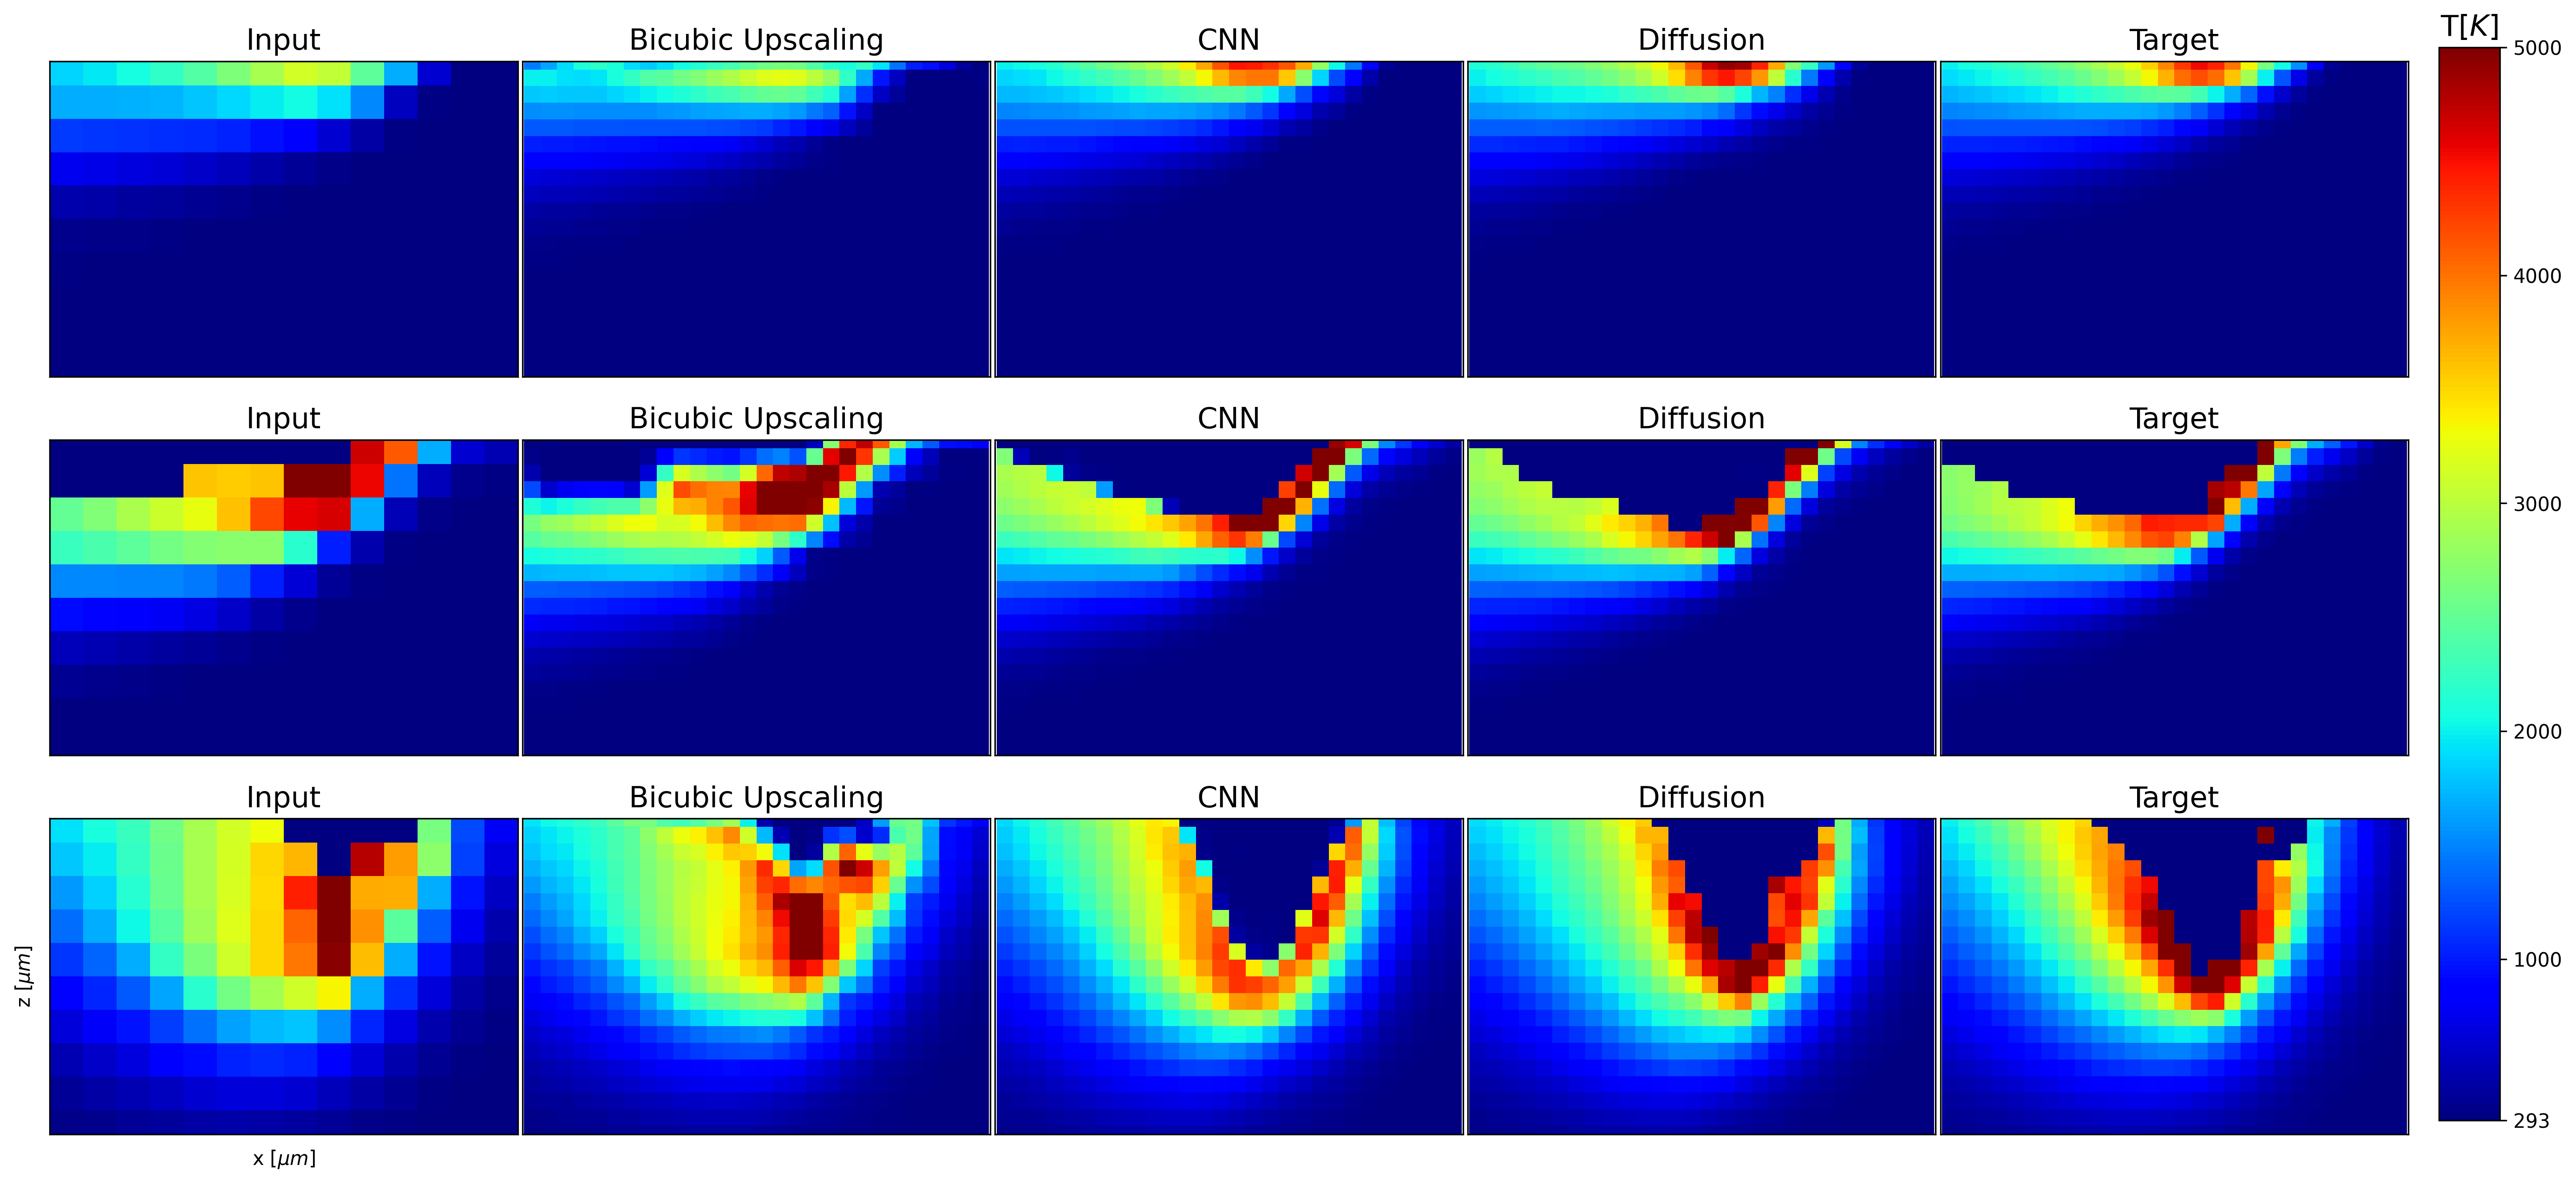

 42%|████▏     | 1709/4094 [00:11<00:15, 152.11it/s] 


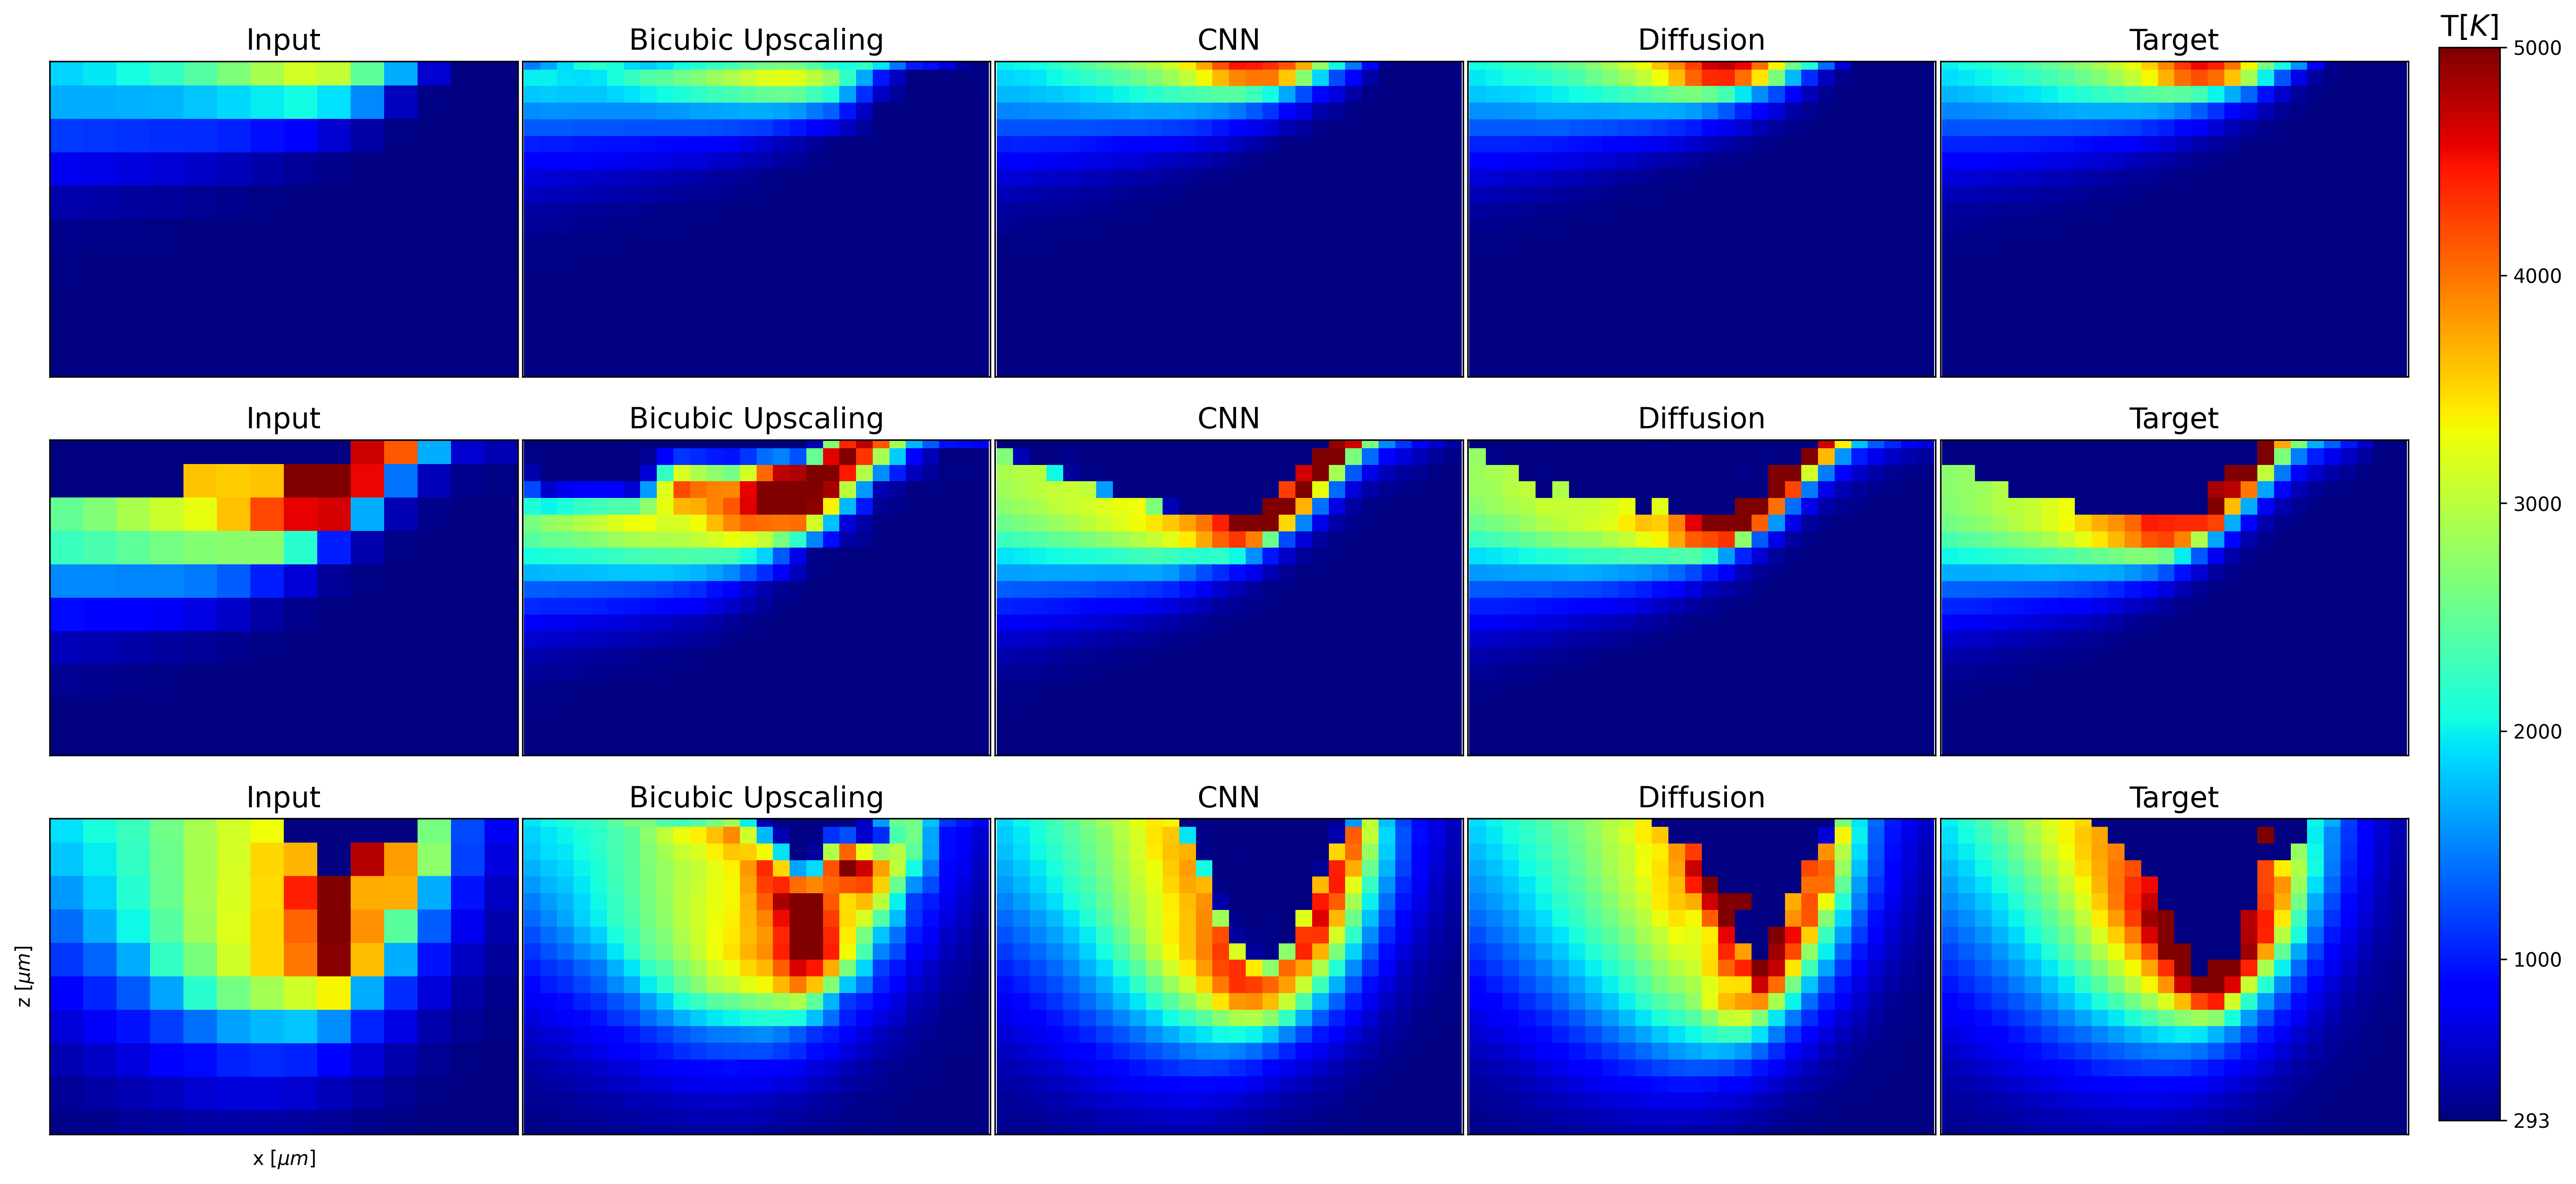

 42%|████▏     | 1709/4094 [00:11<00:15, 150.33it/s]


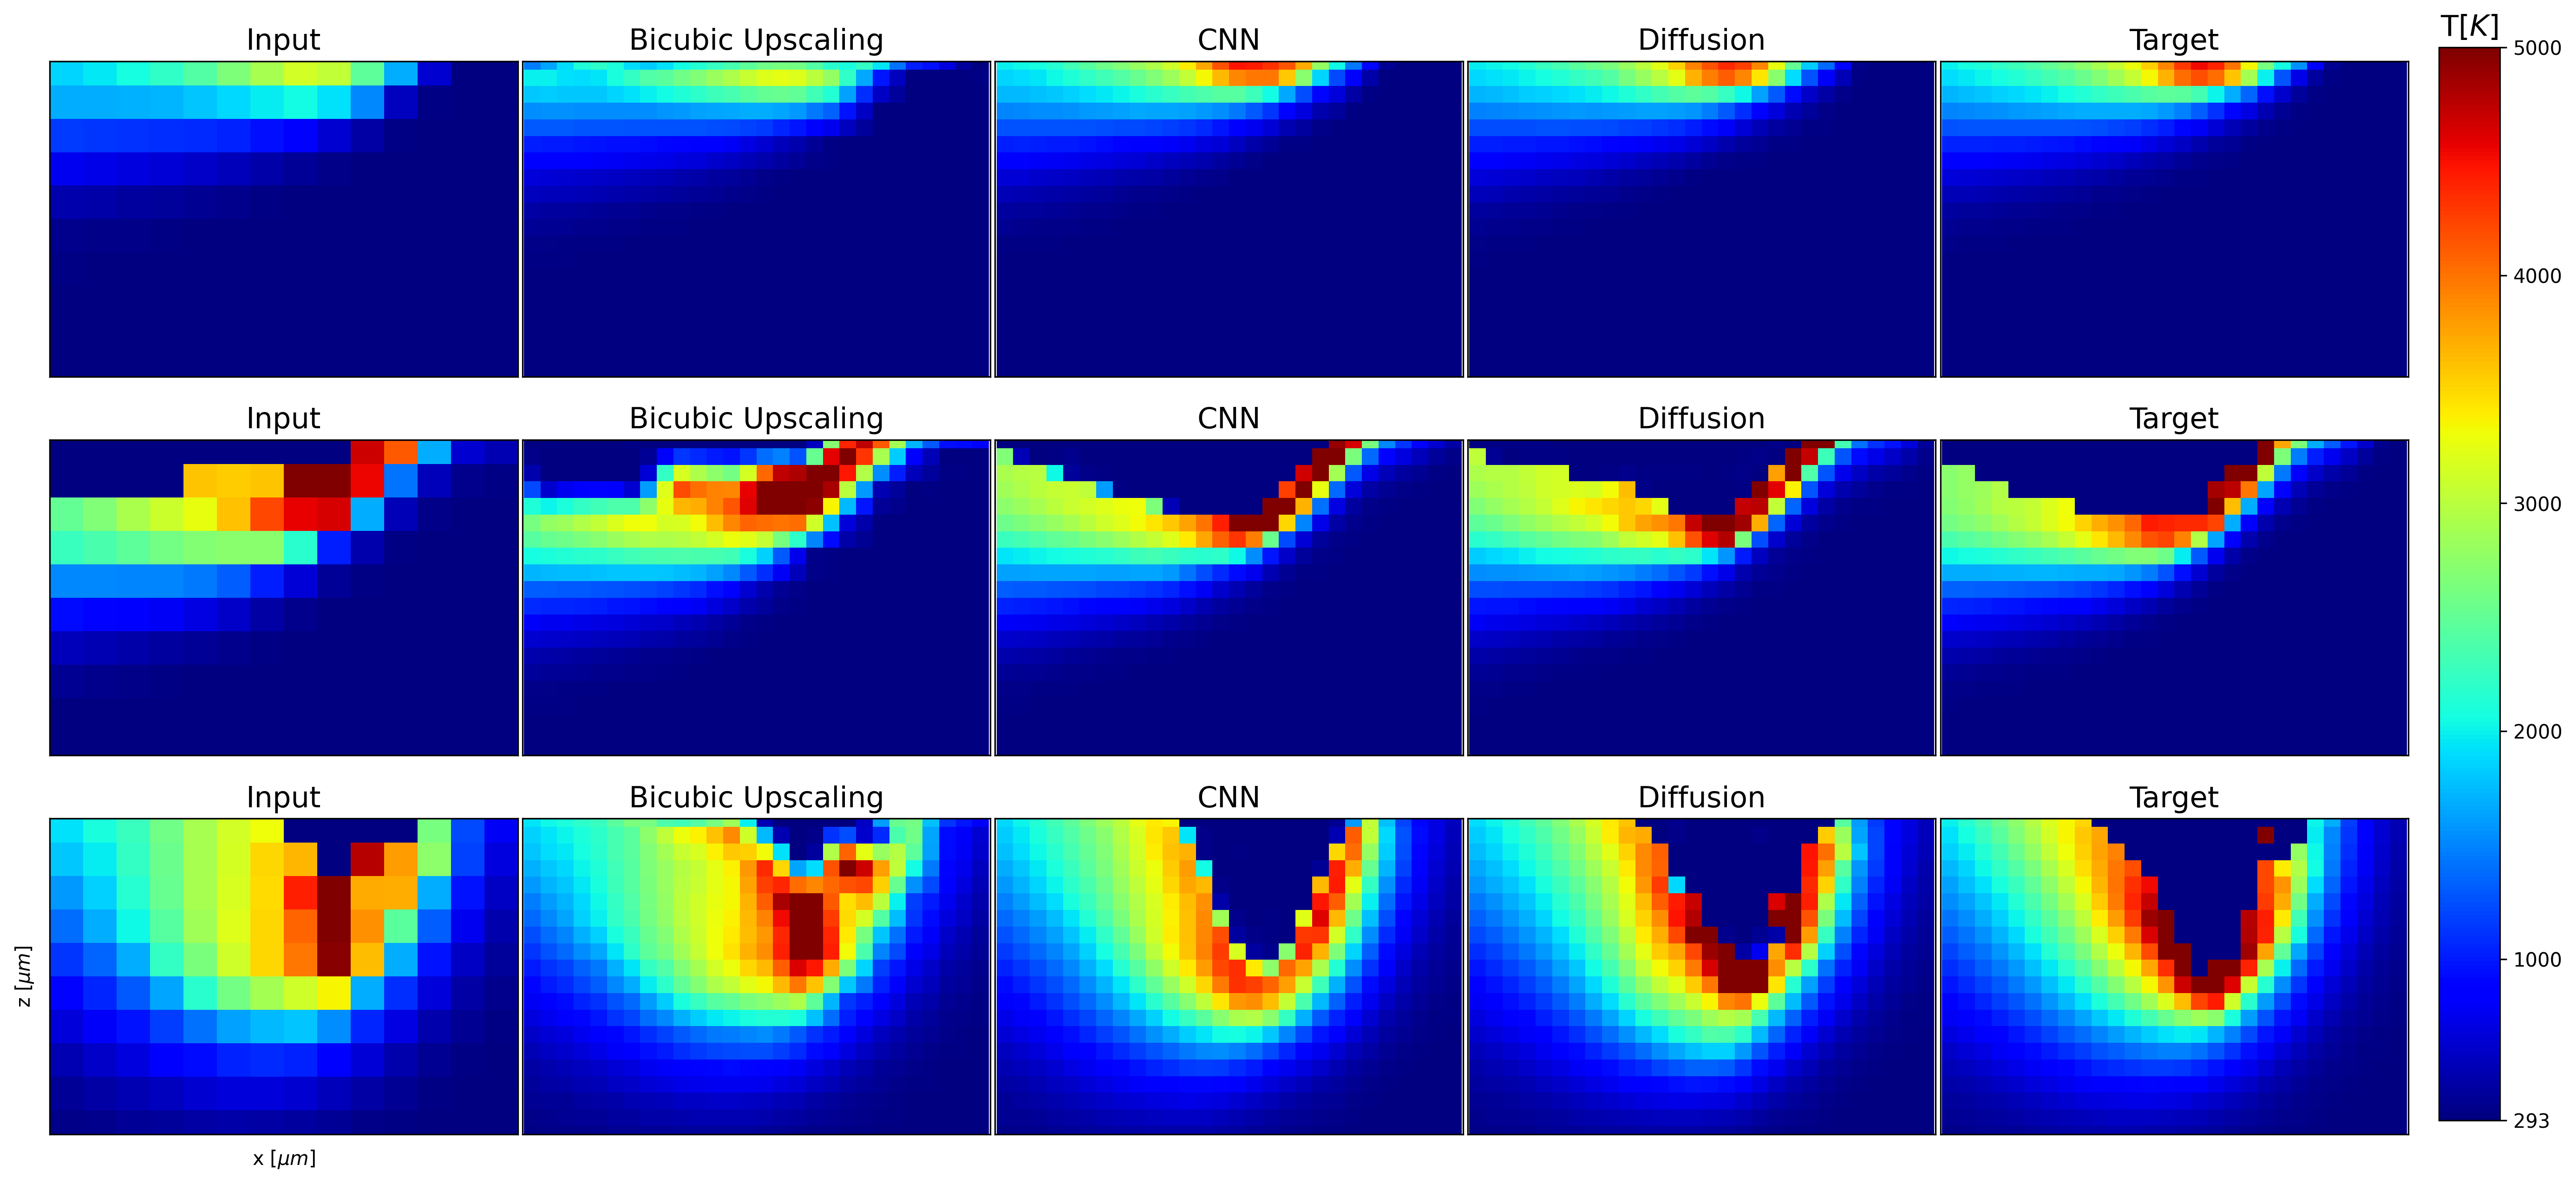

 42%|████▏     | 1709/4094 [00:11<00:15, 151.61it/s] 


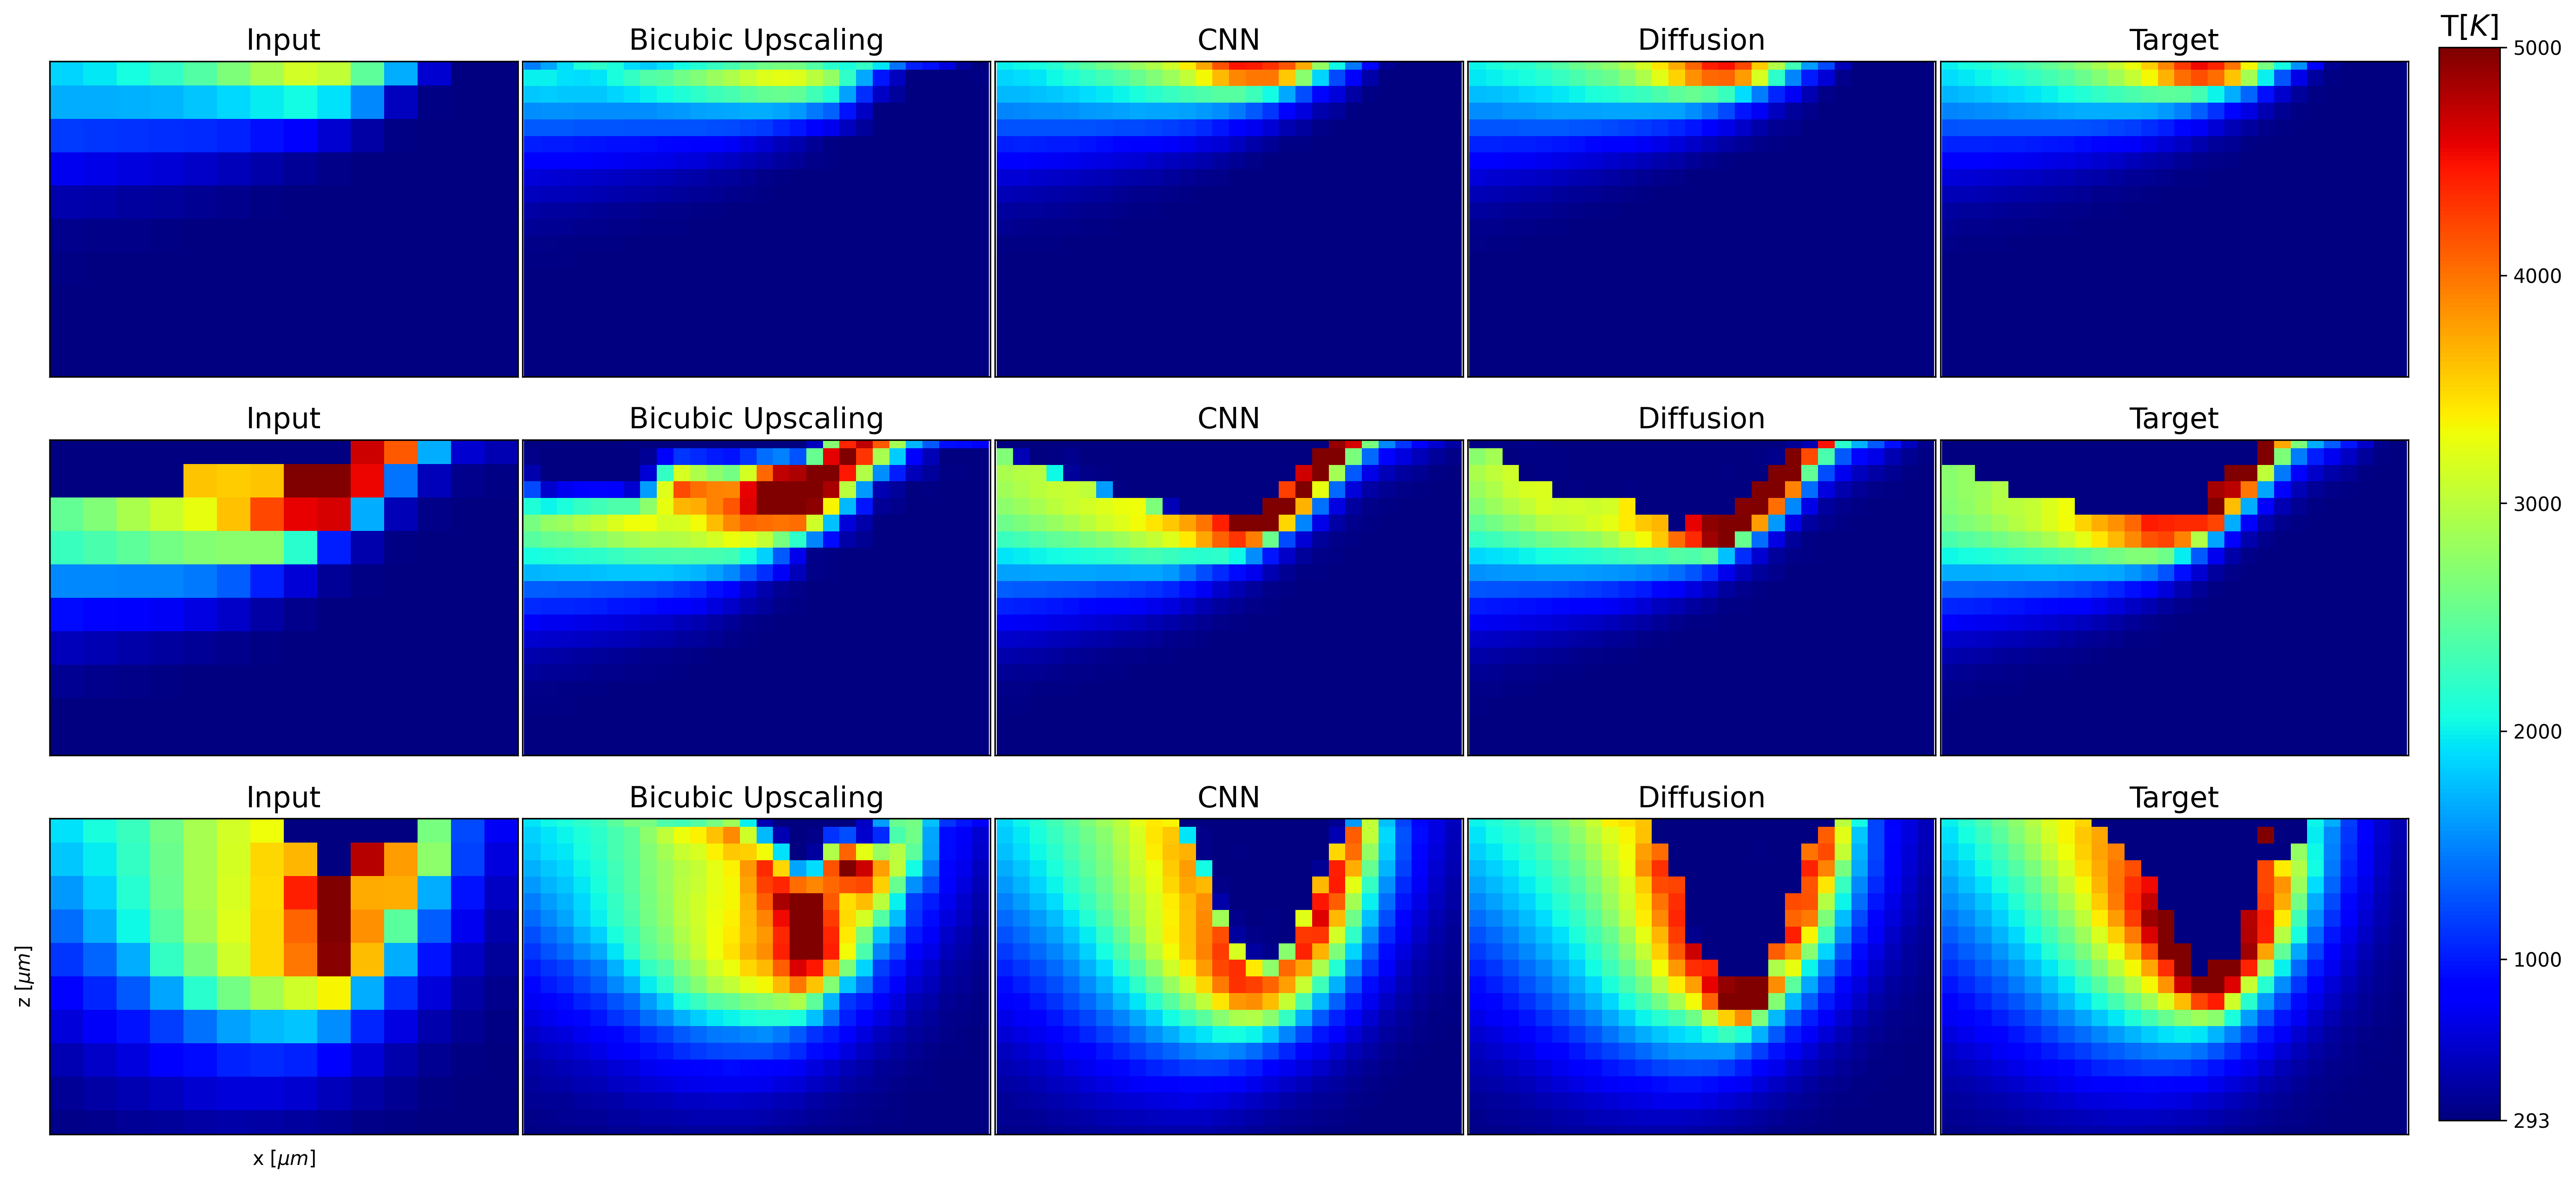

 42%|████▏     | 1709/4094 [00:11<00:15, 150.87it/s]


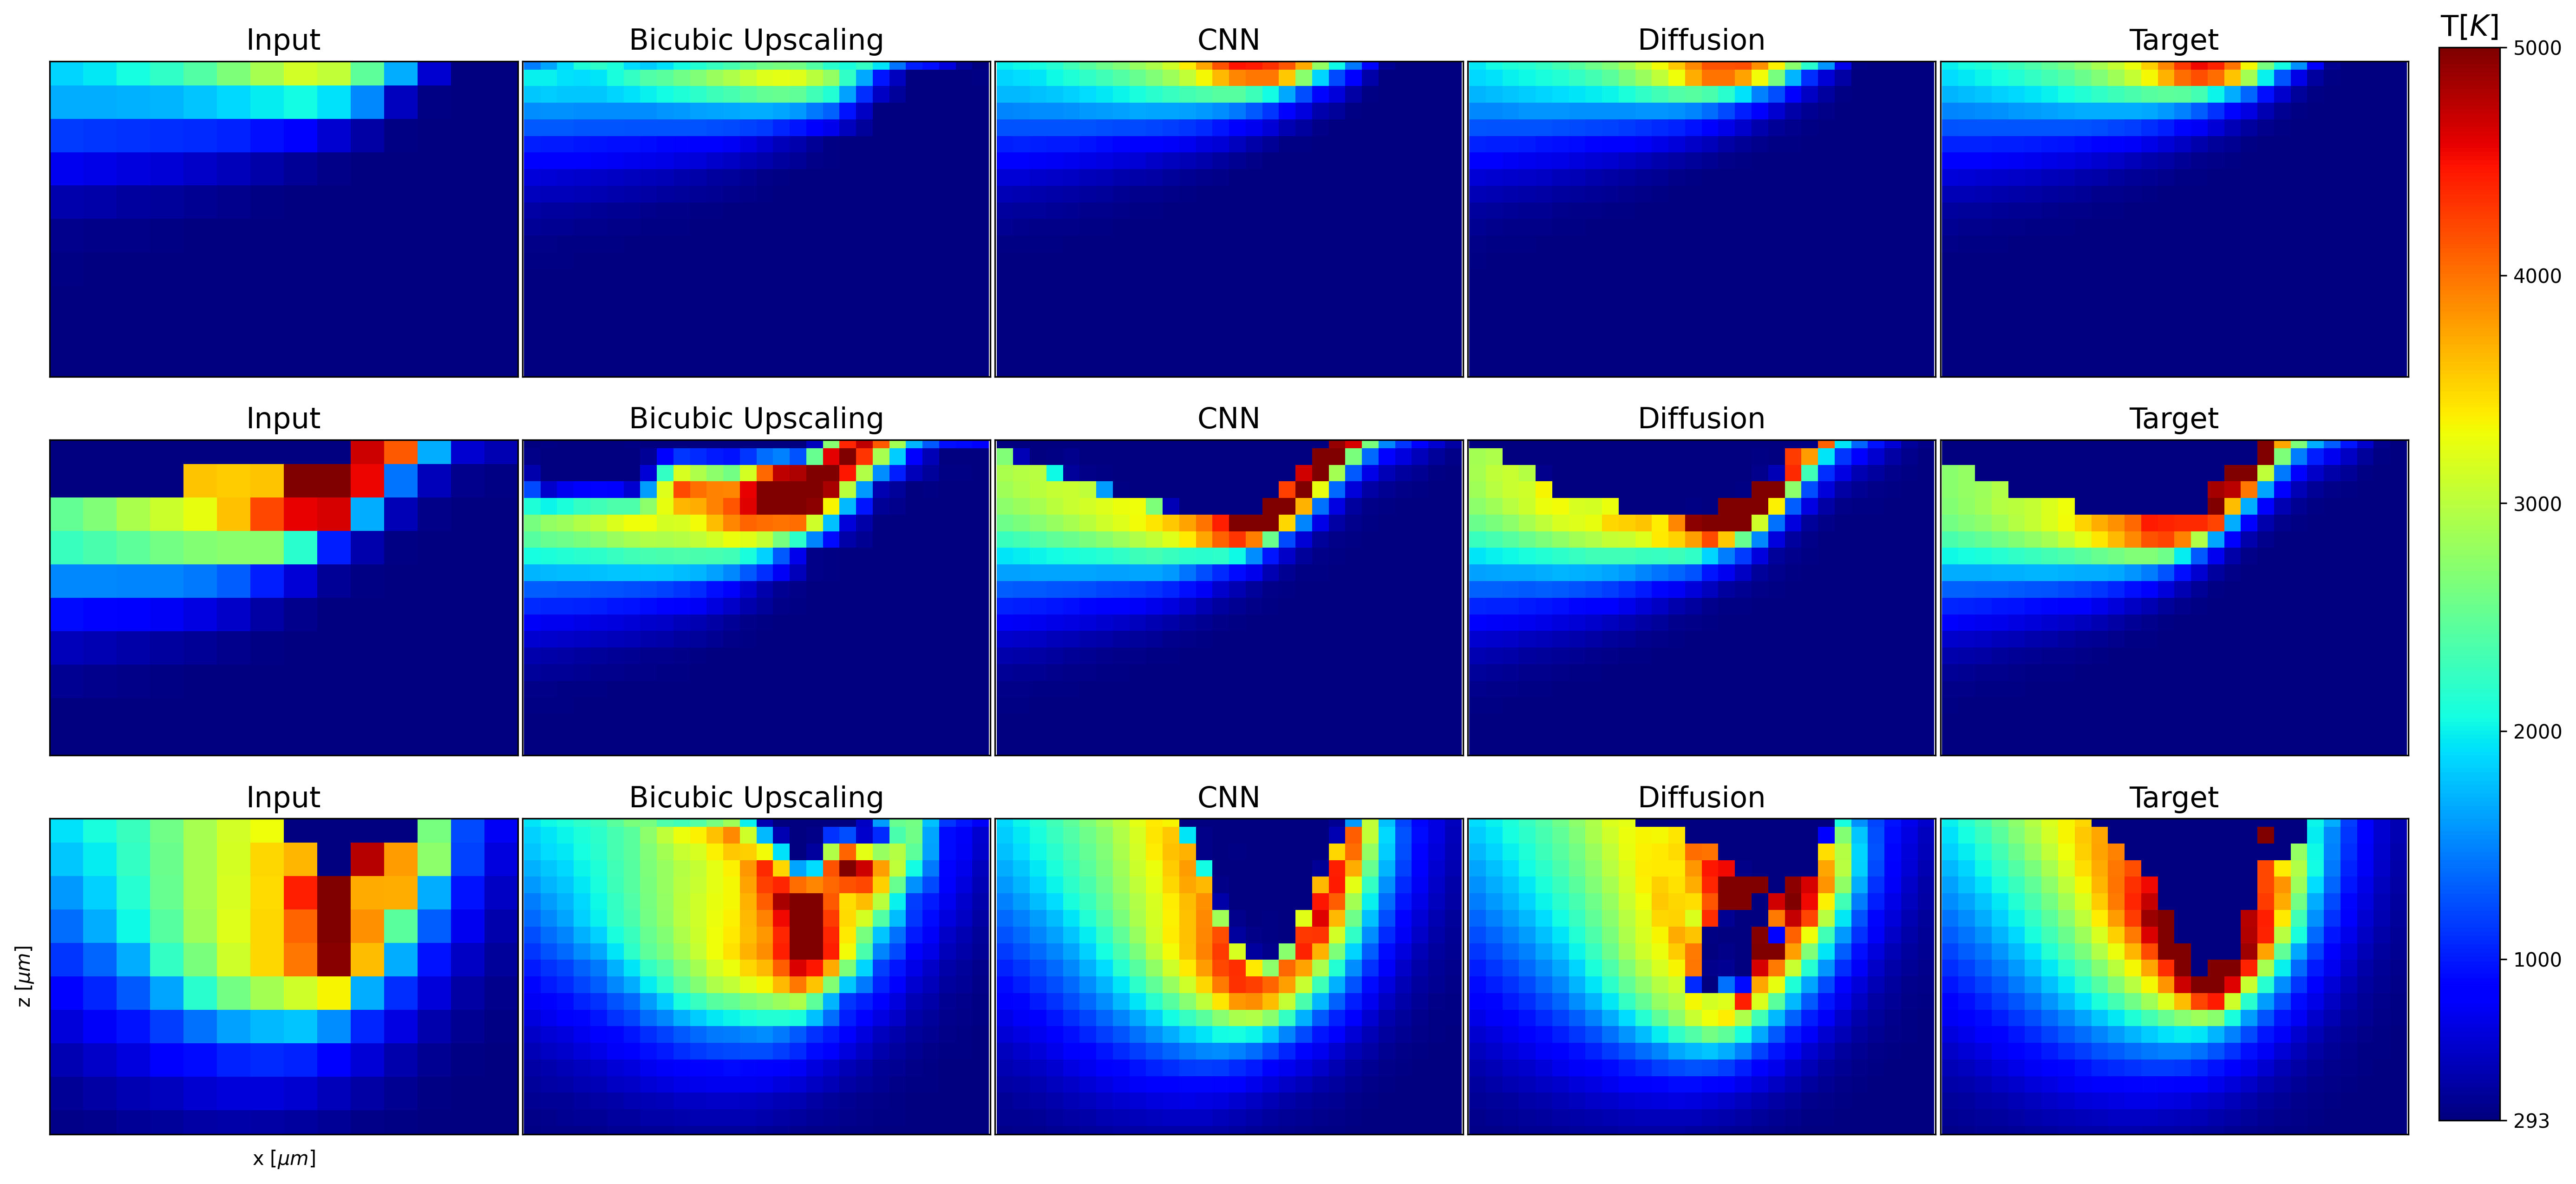

 42%|████▏     | 1709/4094 [00:11<00:15, 149.87it/s]


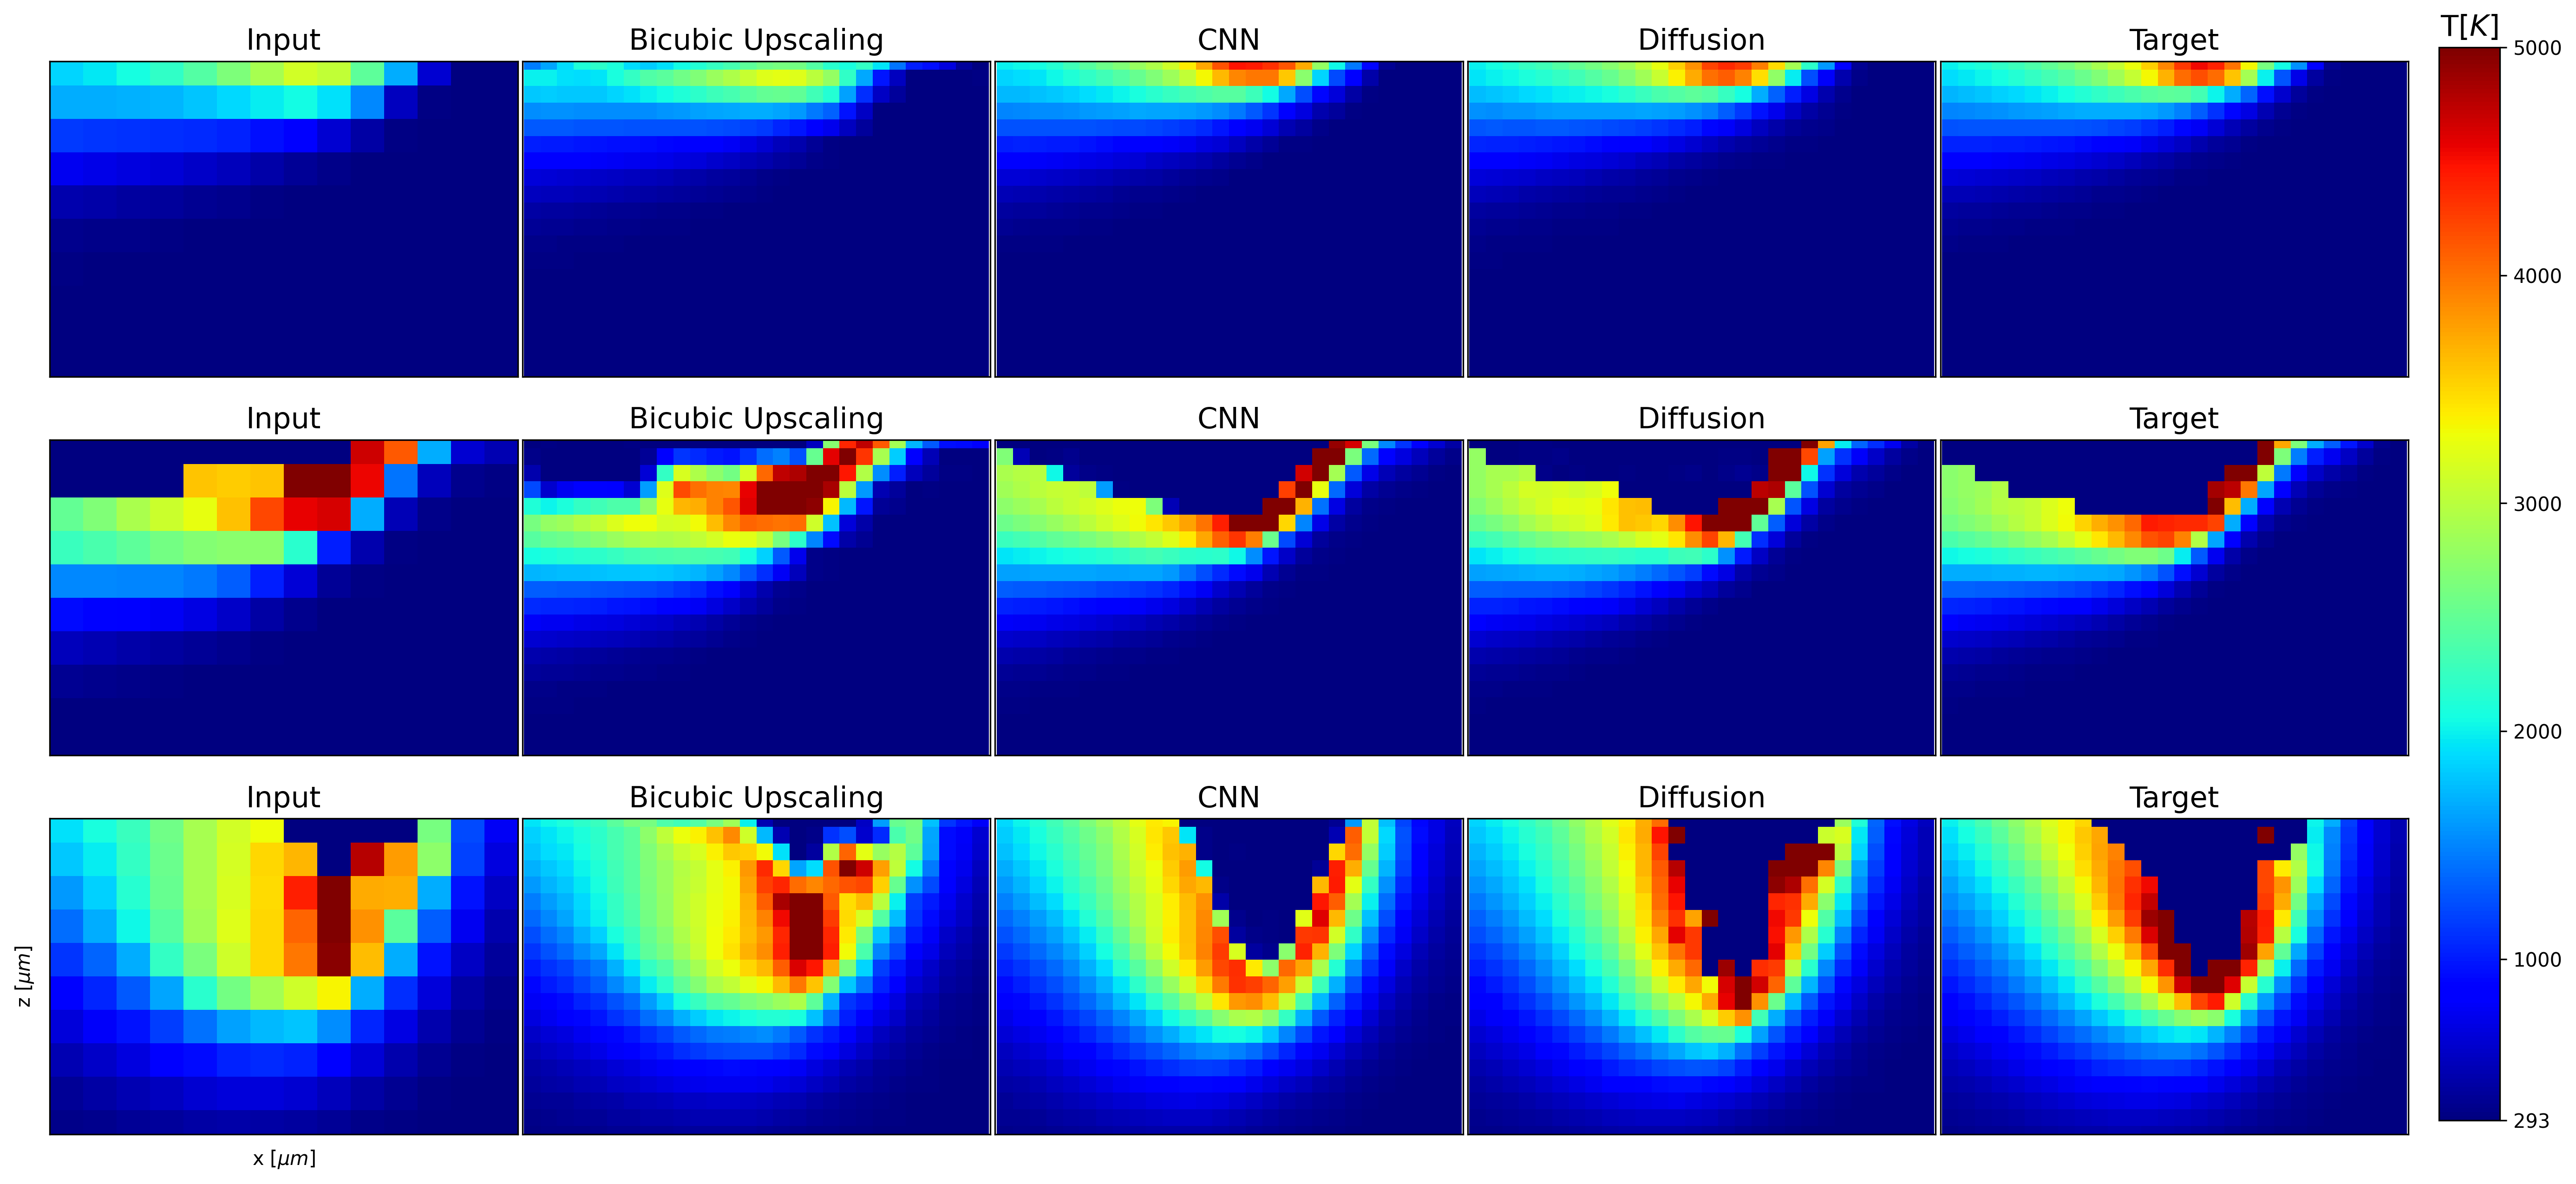

 42%|████▏     | 1709/4094 [00:11<00:16, 143.45it/s]


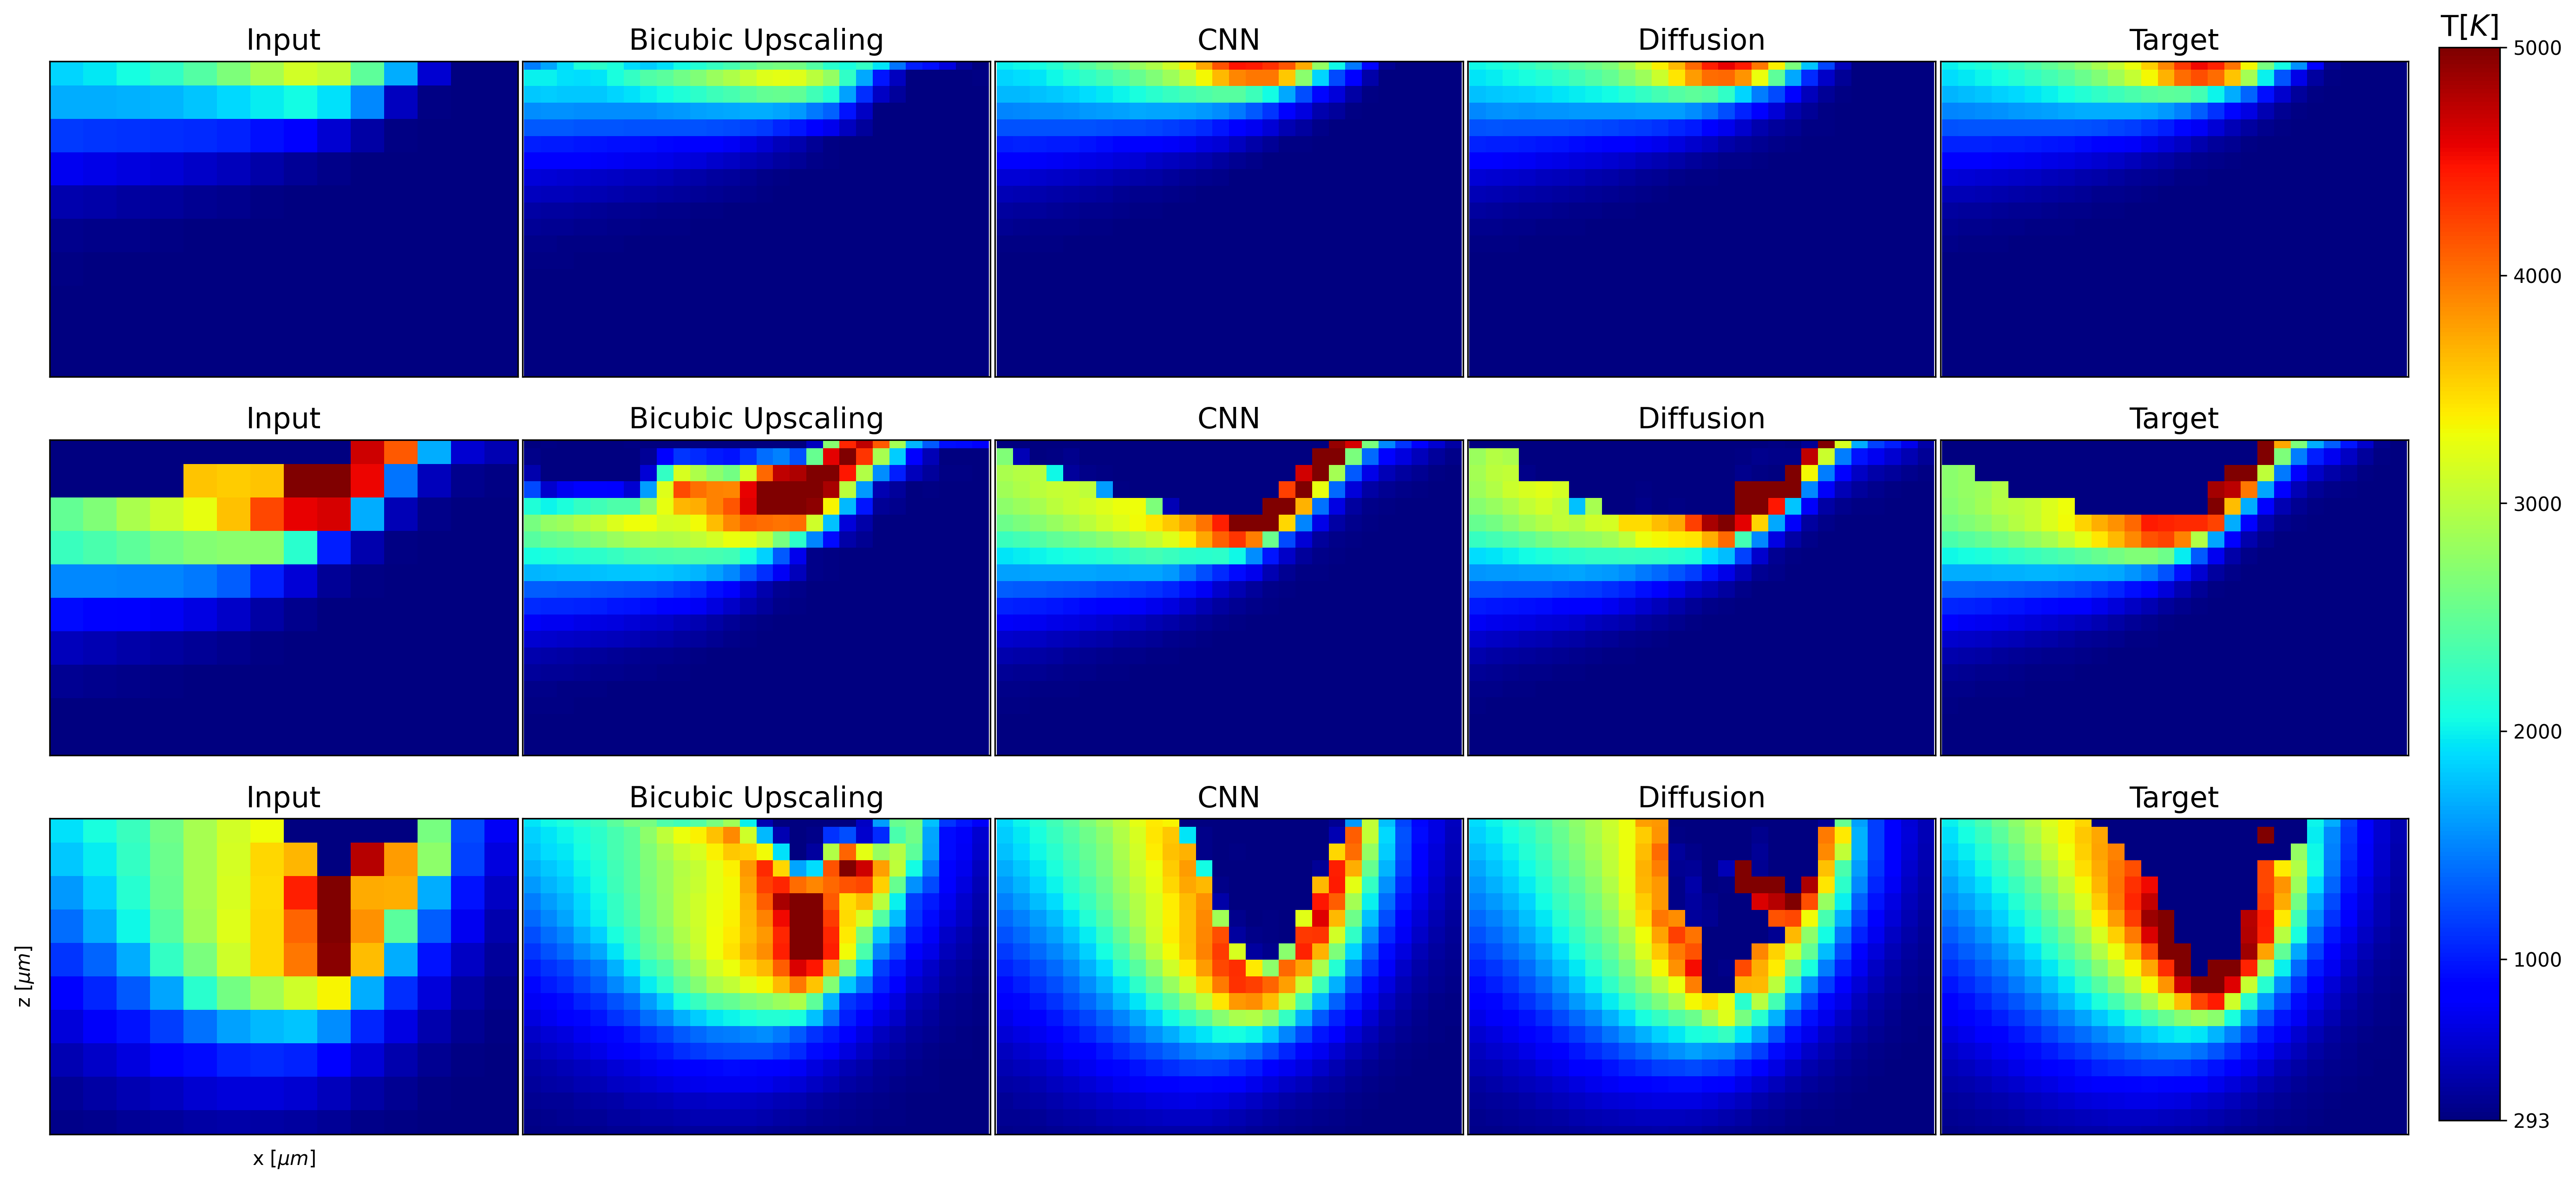

 42%|████▏     | 1709/4094 [00:11<00:15, 149.11it/s]


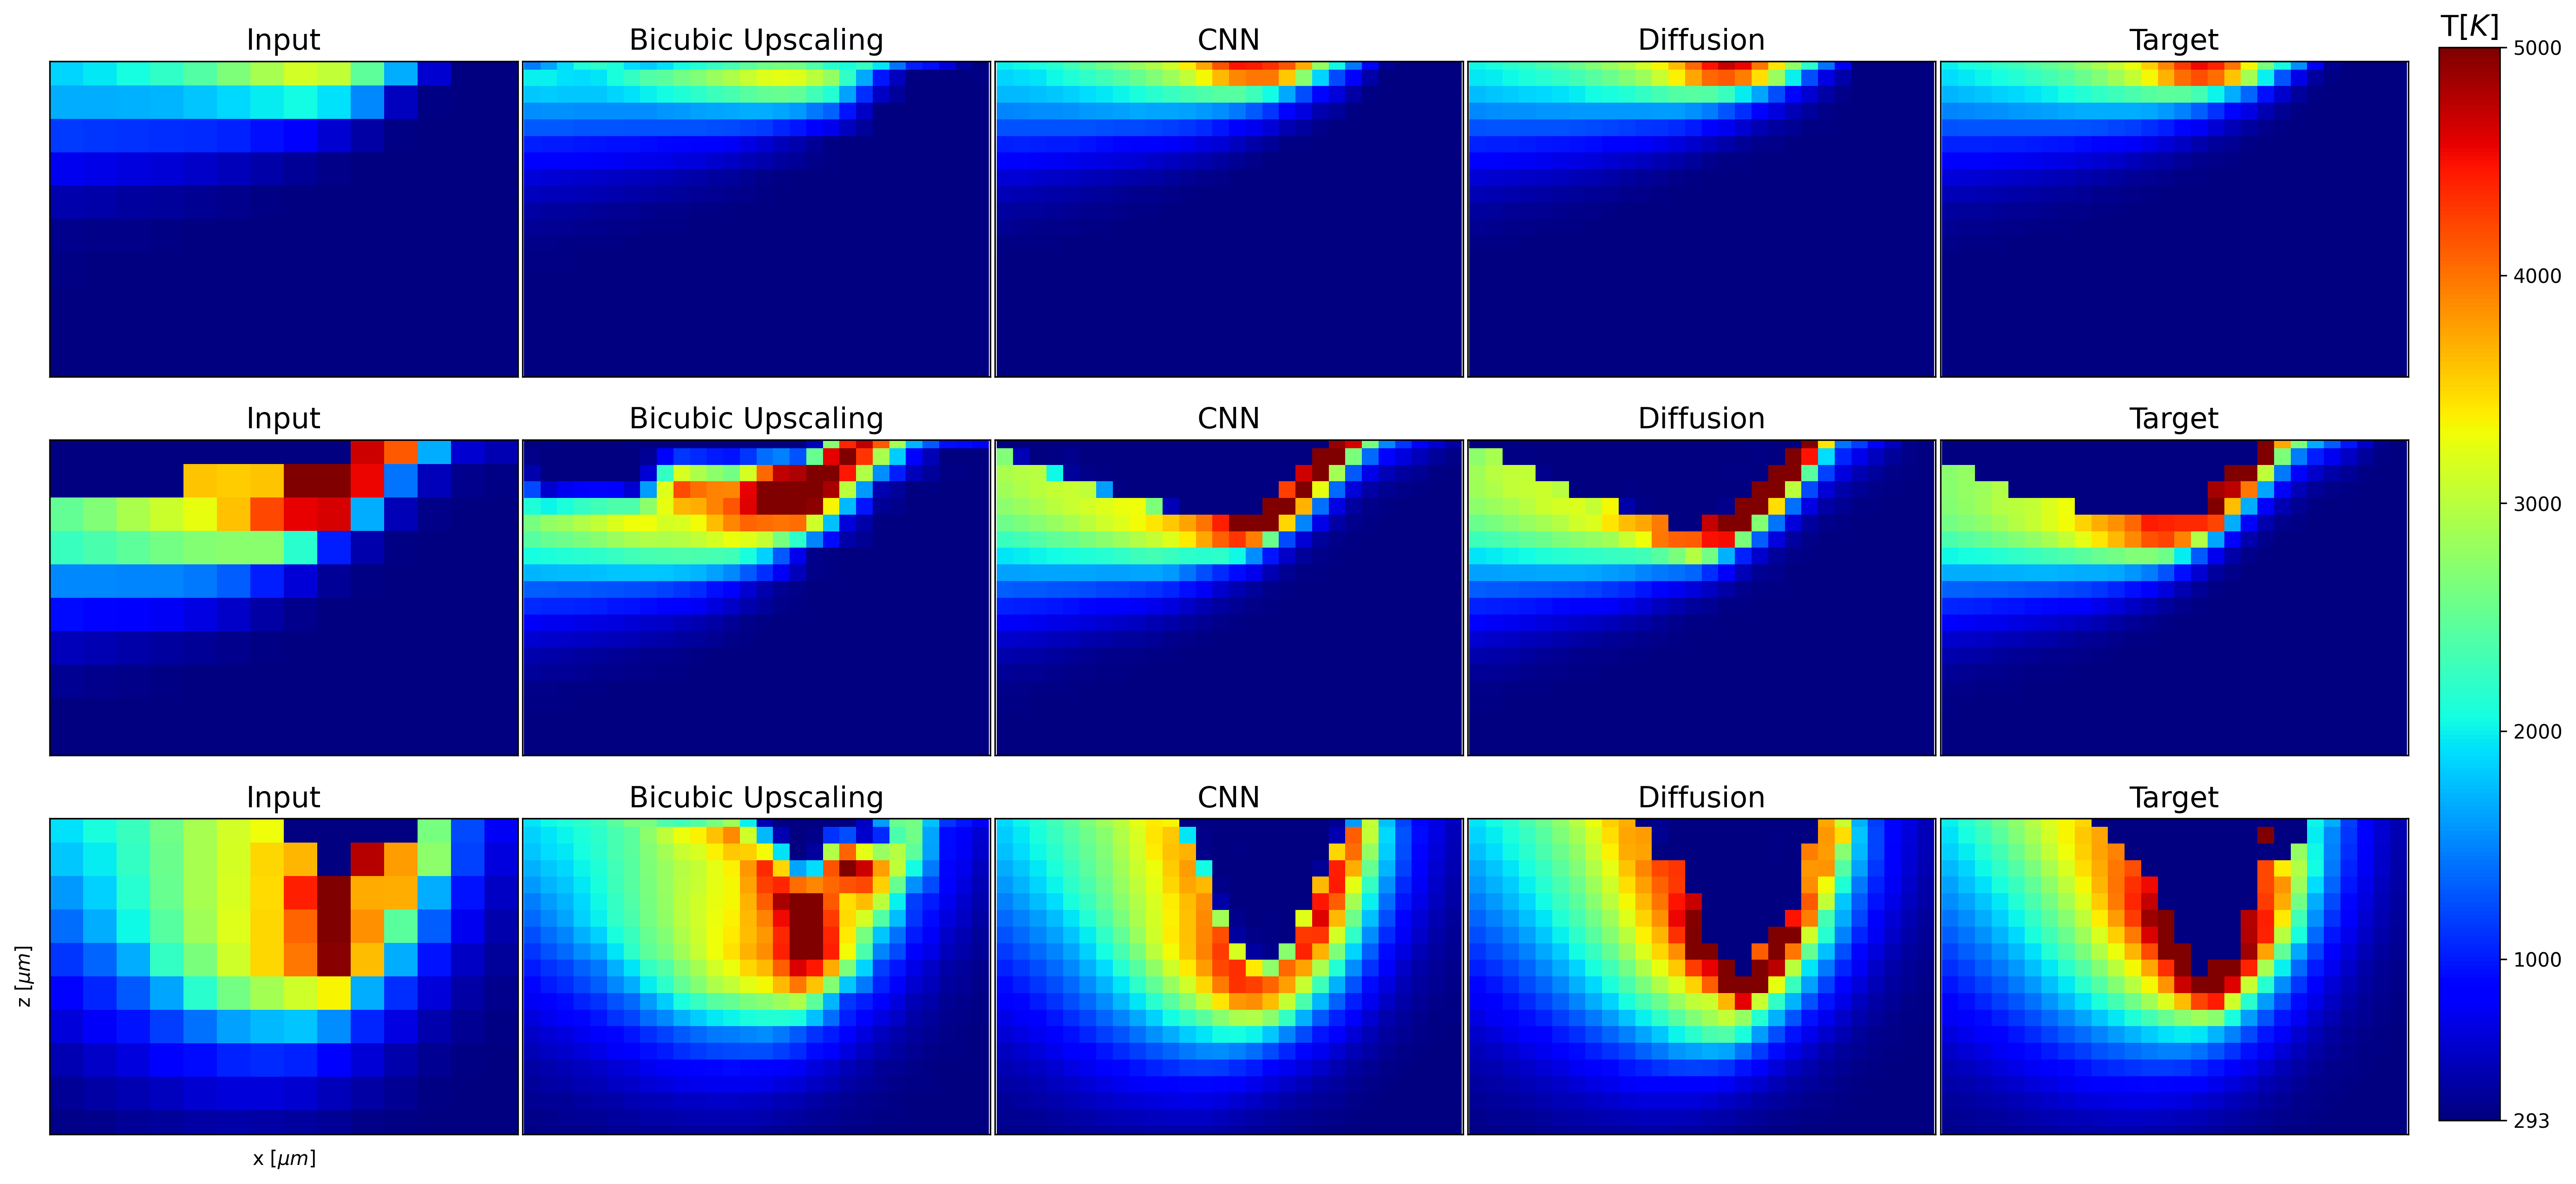

 42%|████▏     | 1709/4094 [00:11<00:15, 149.28it/s]


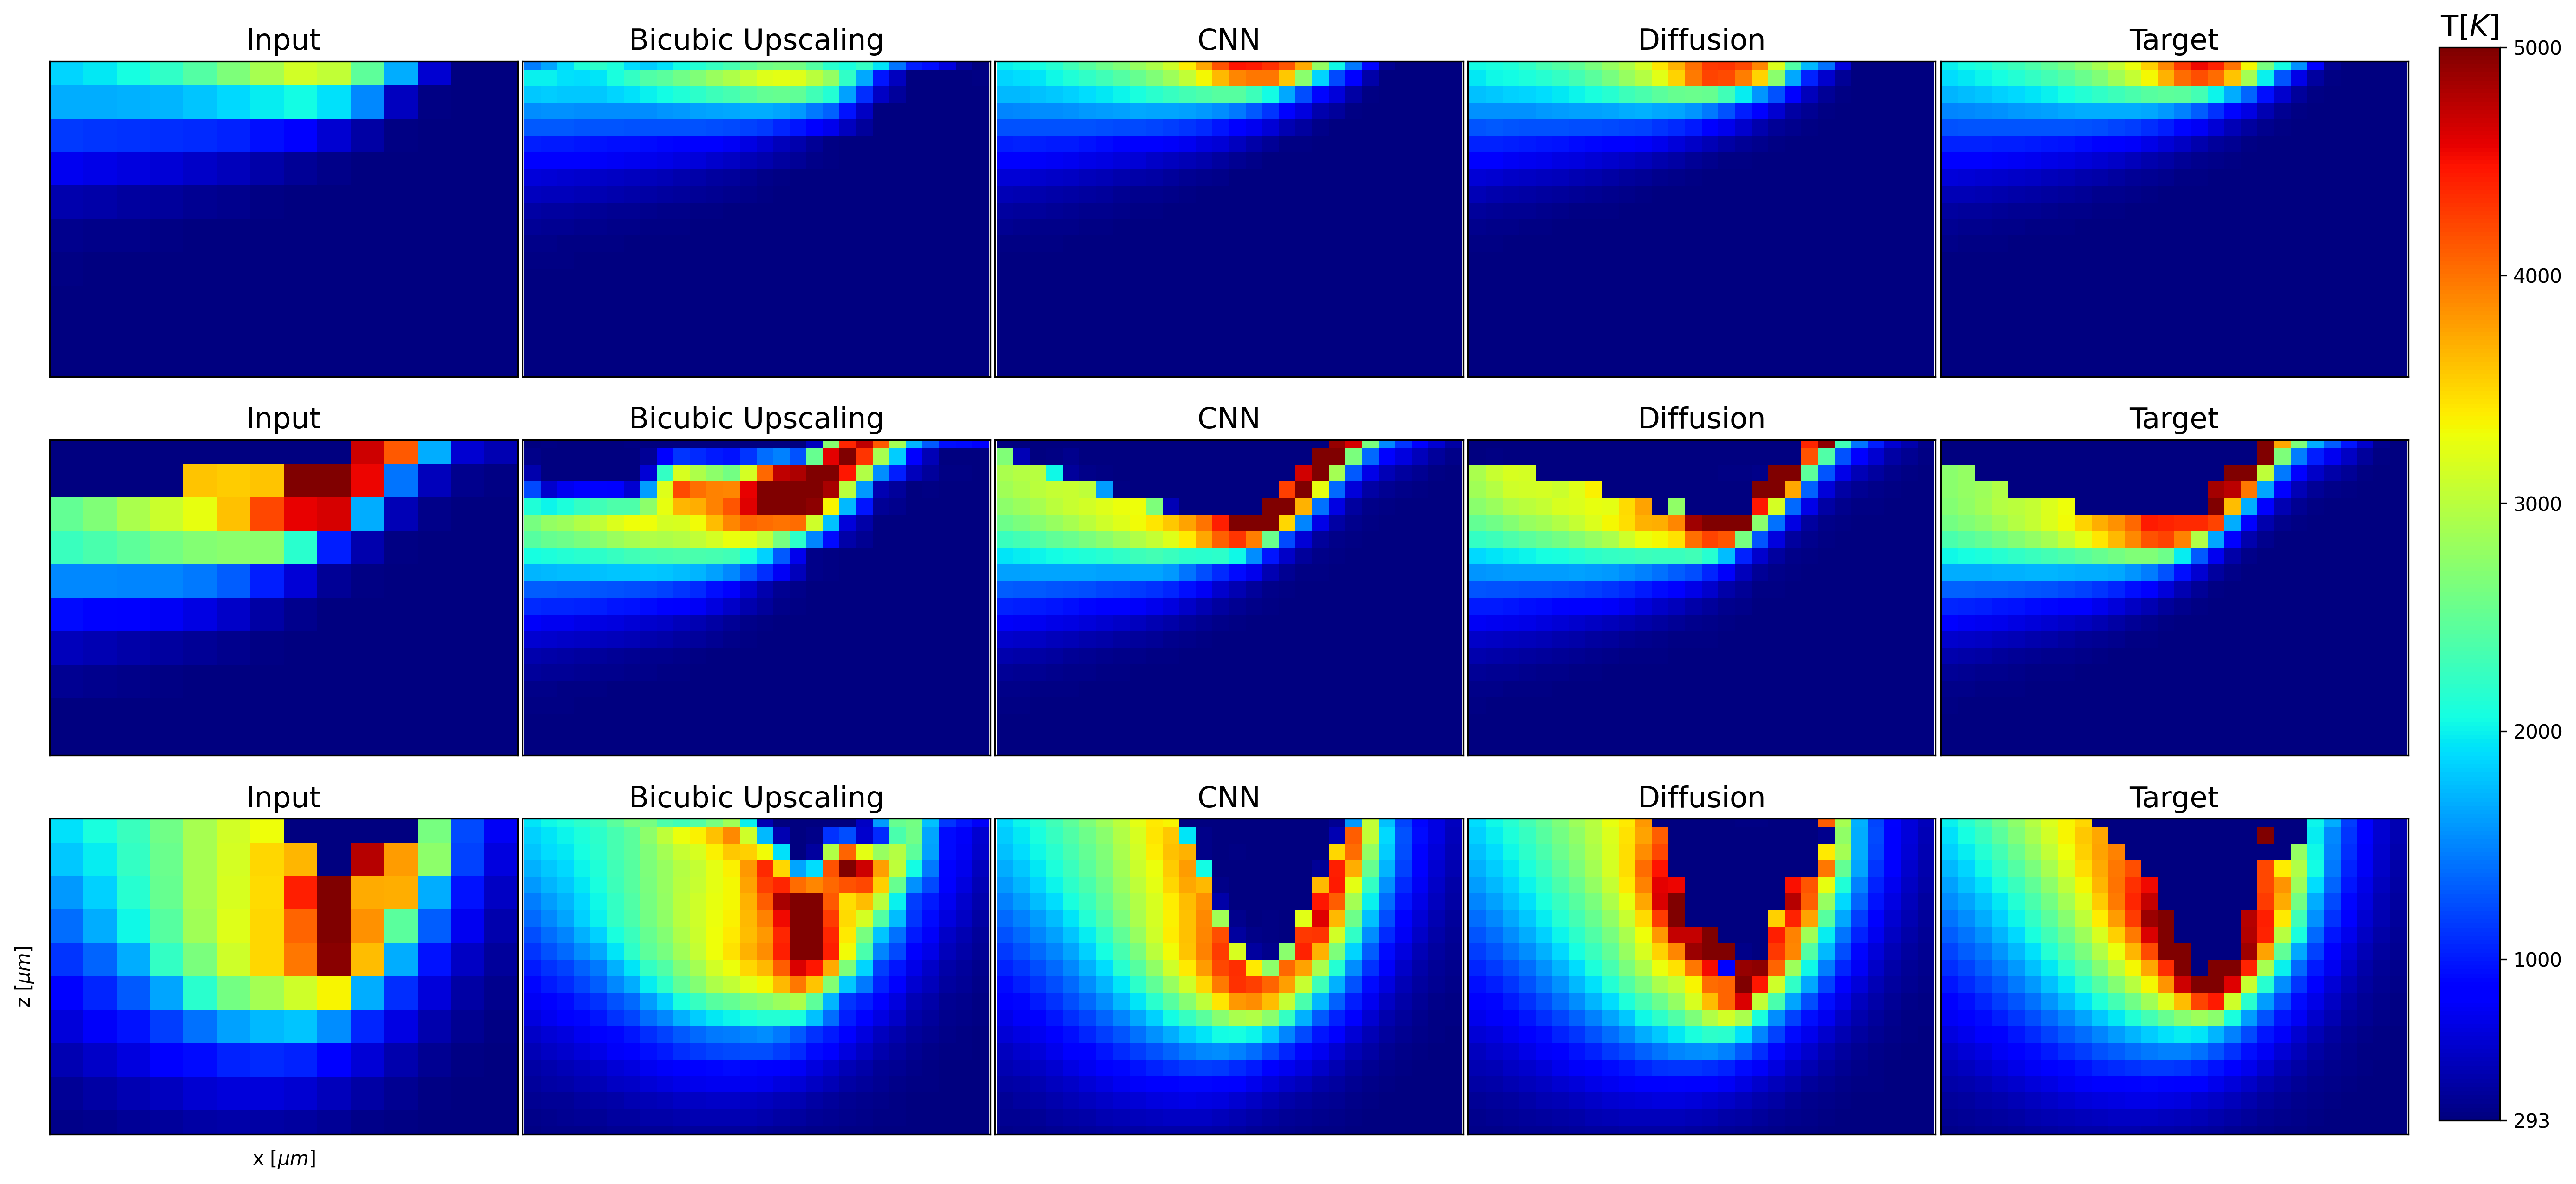

 42%|████▏     | 1709/4094 [00:11<00:15, 153.57it/s] 


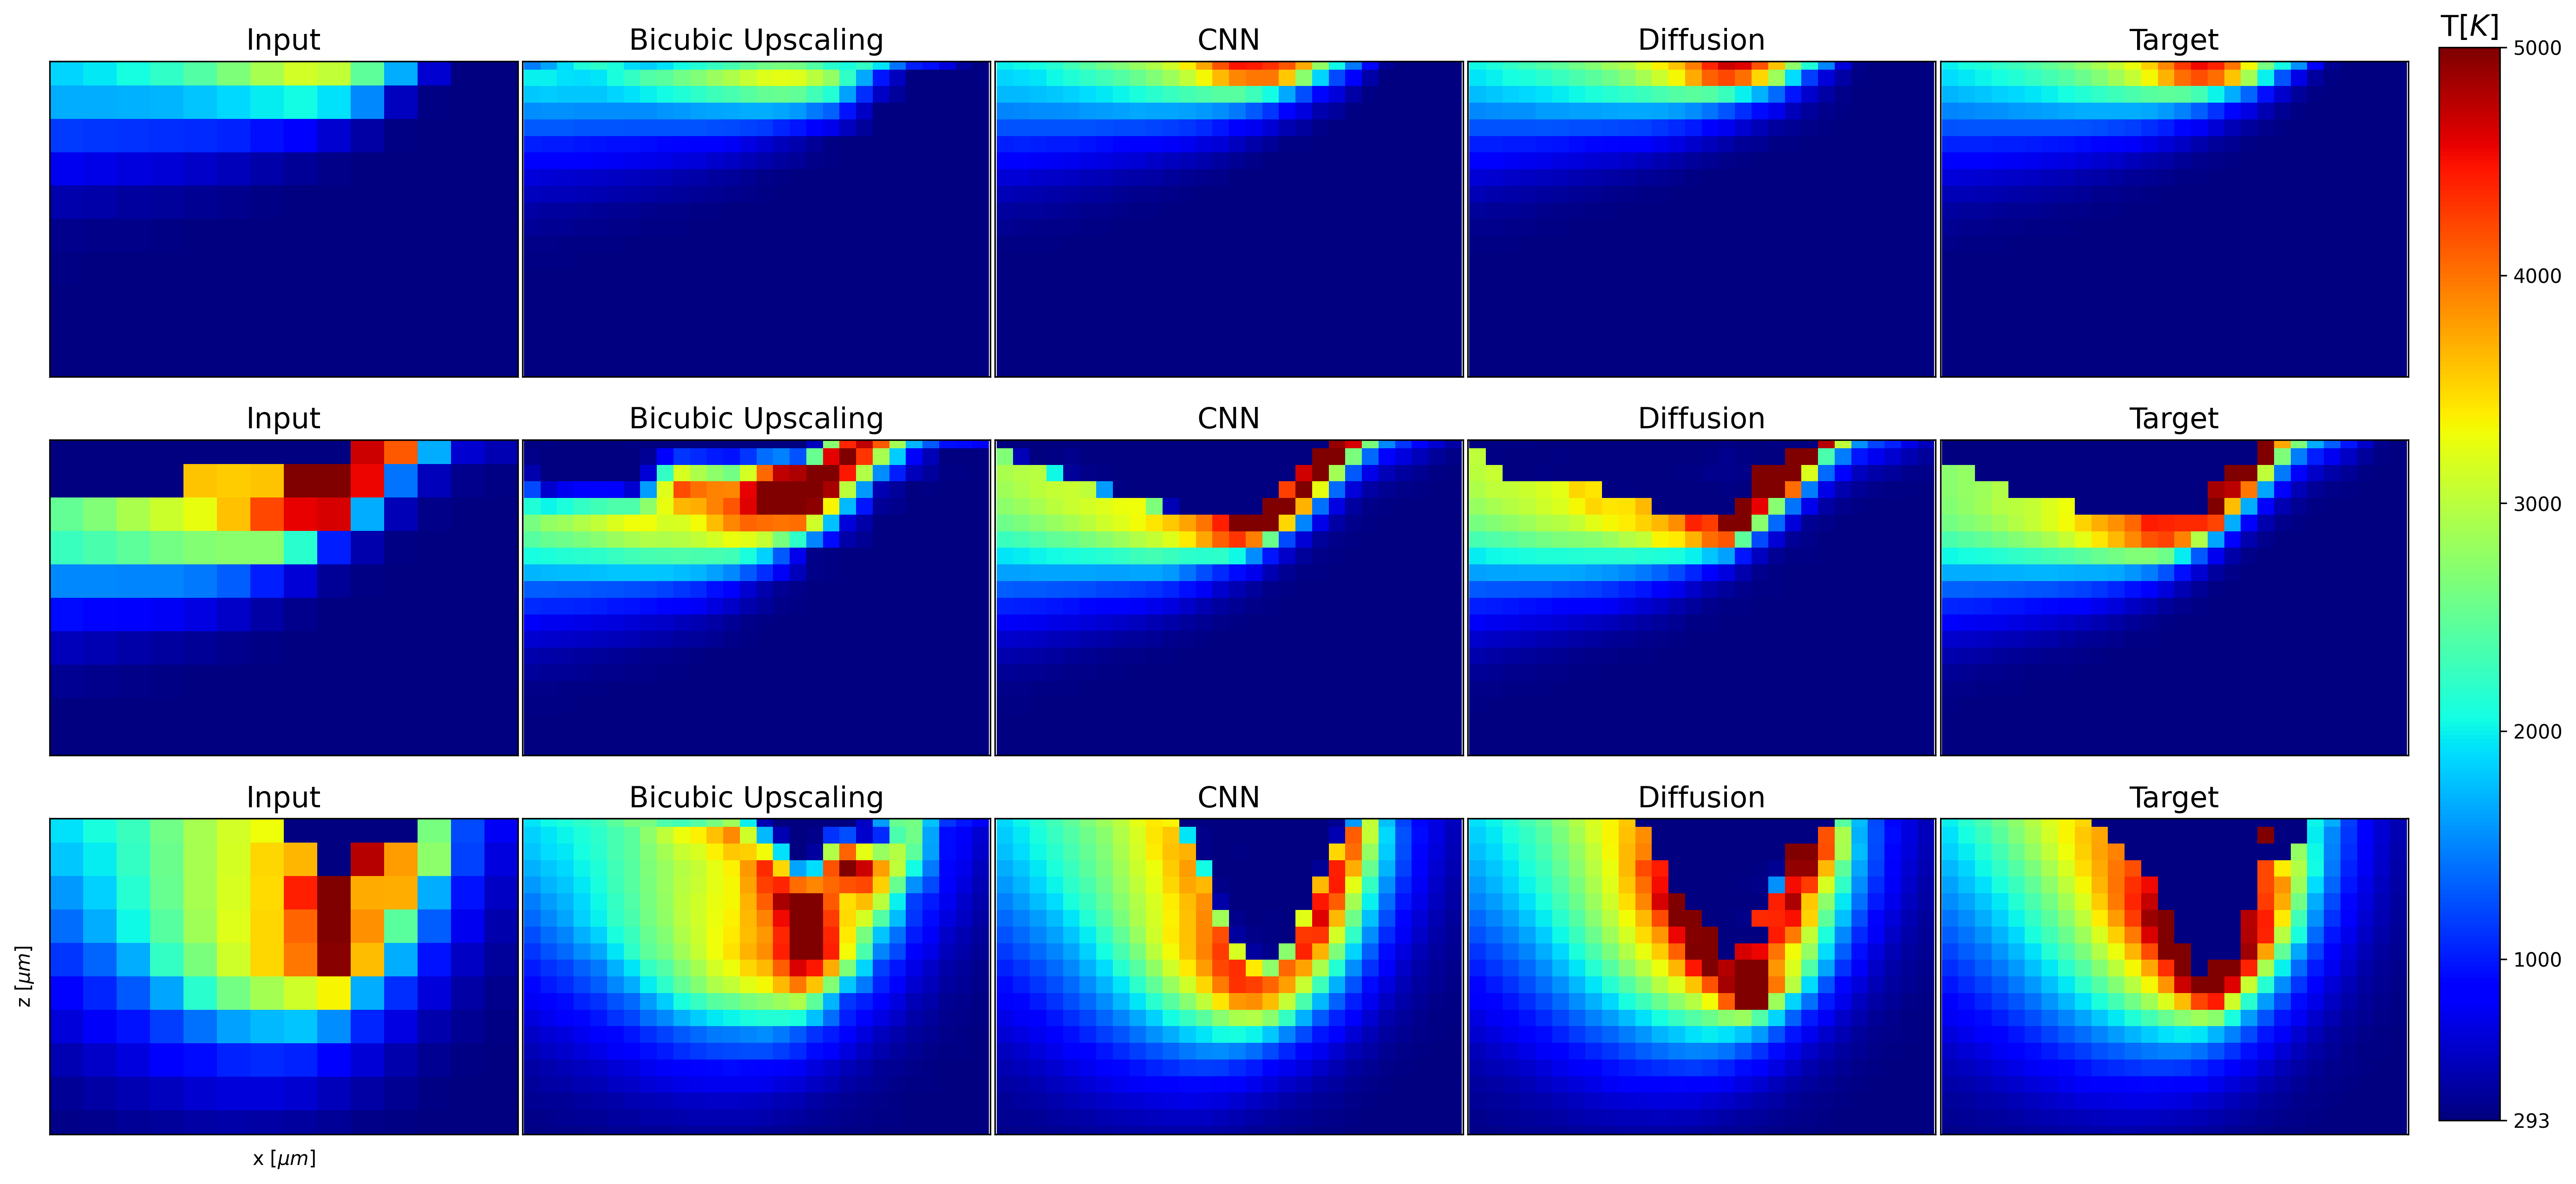

 42%|████▏     | 1709/4094 [00:11<00:15, 154.66it/s] 


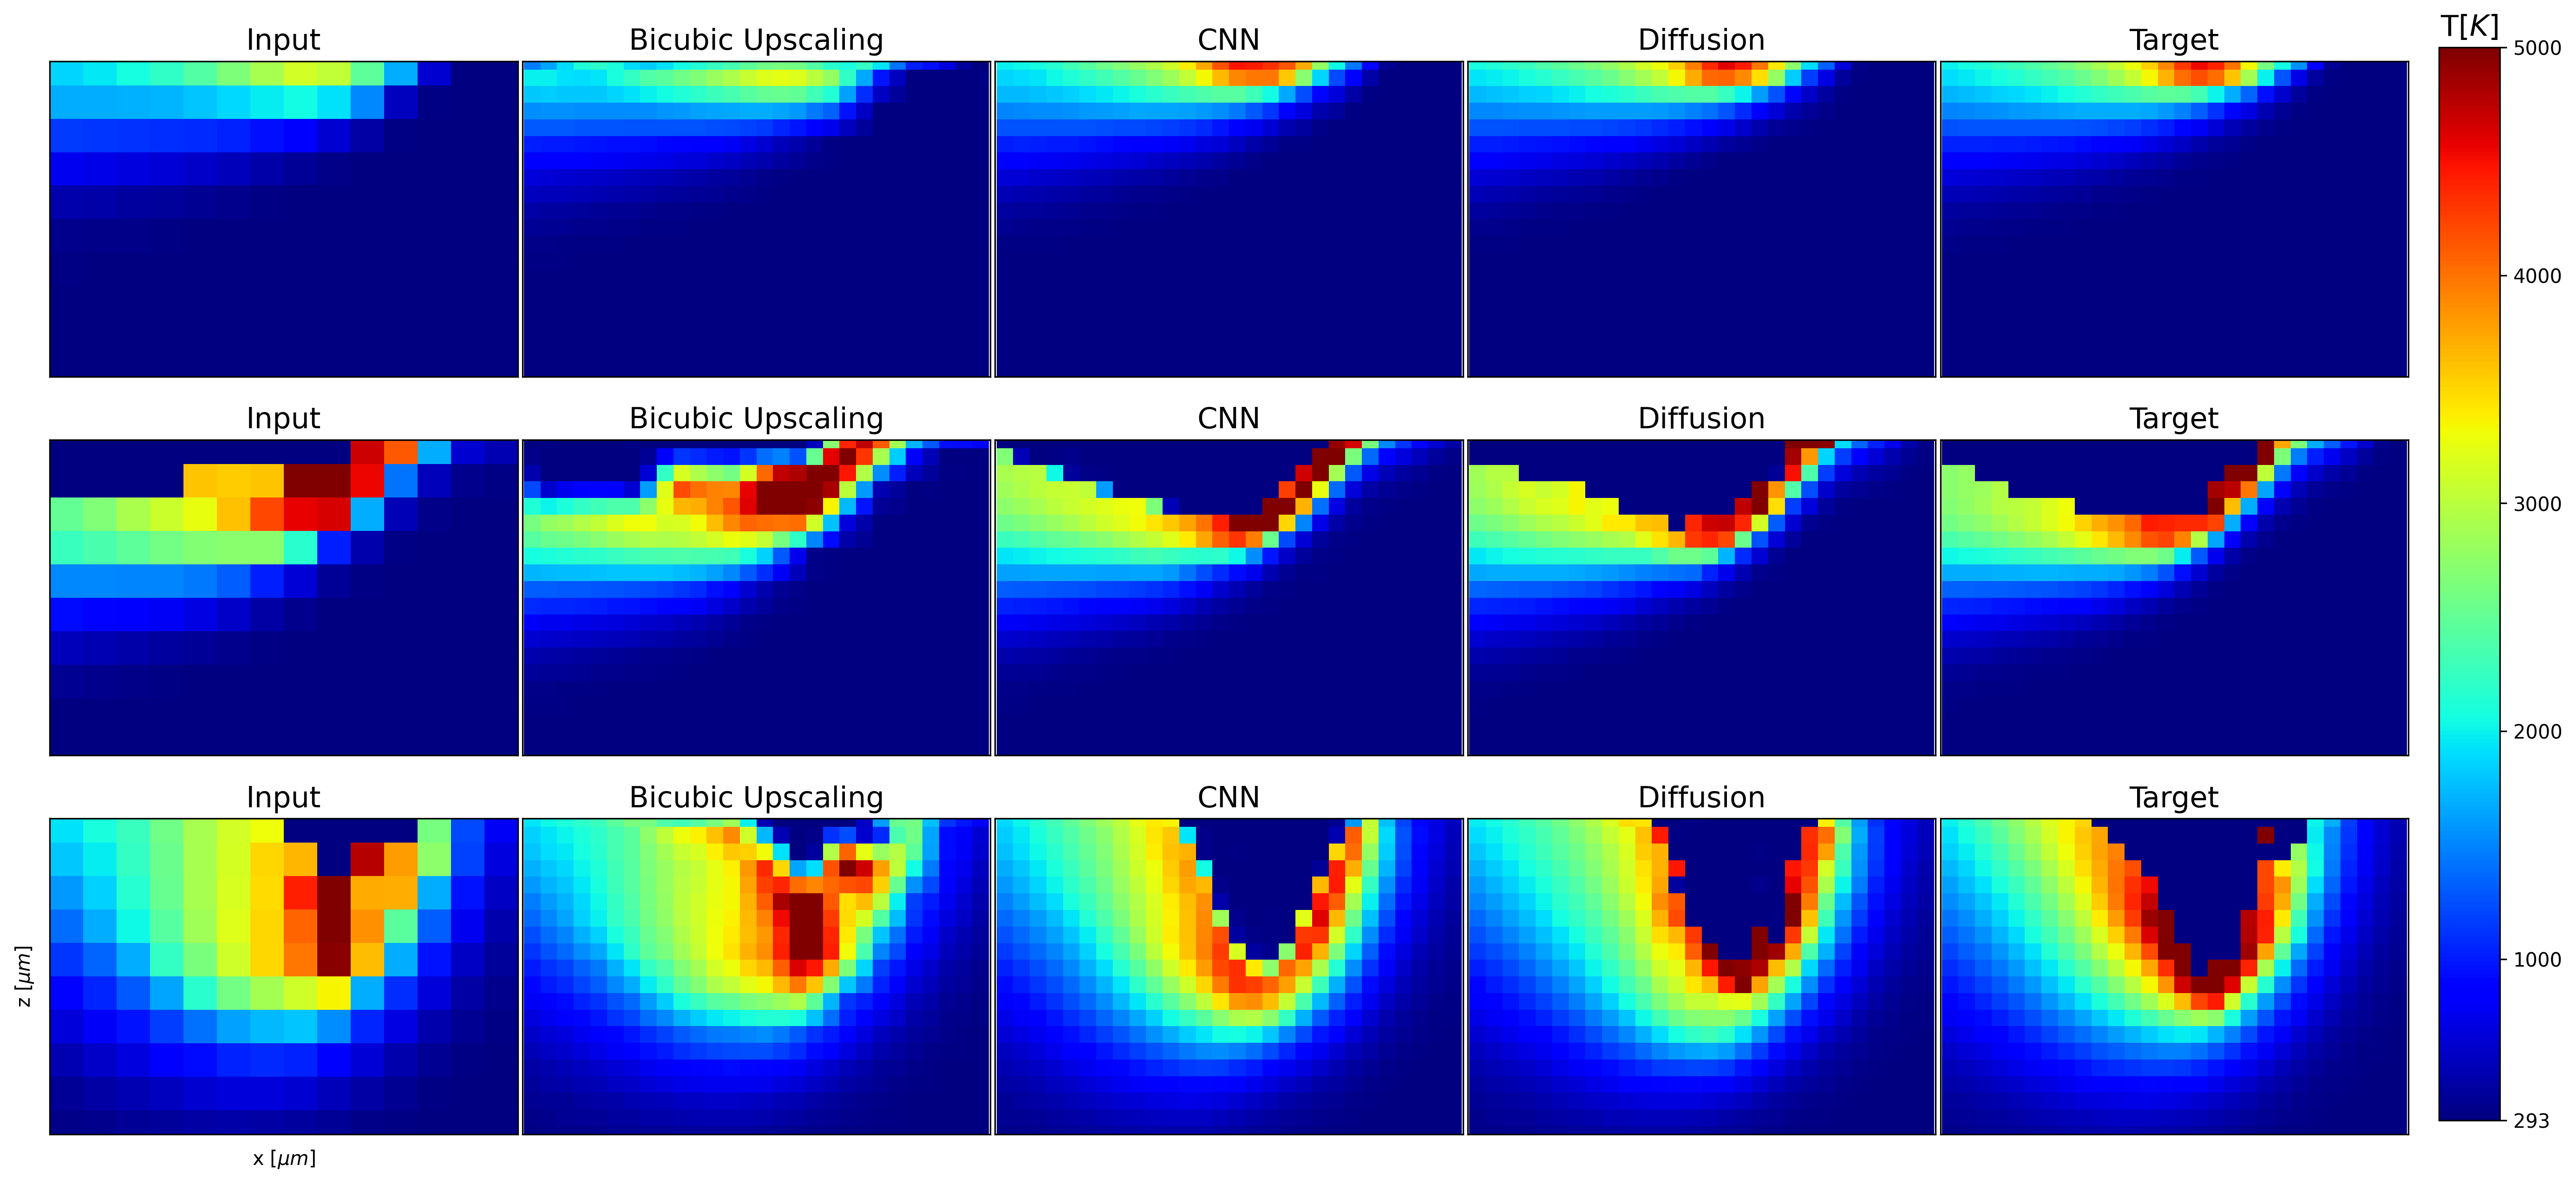

 42%|████▏     | 1709/4094 [00:11<00:15, 152.25it/s]


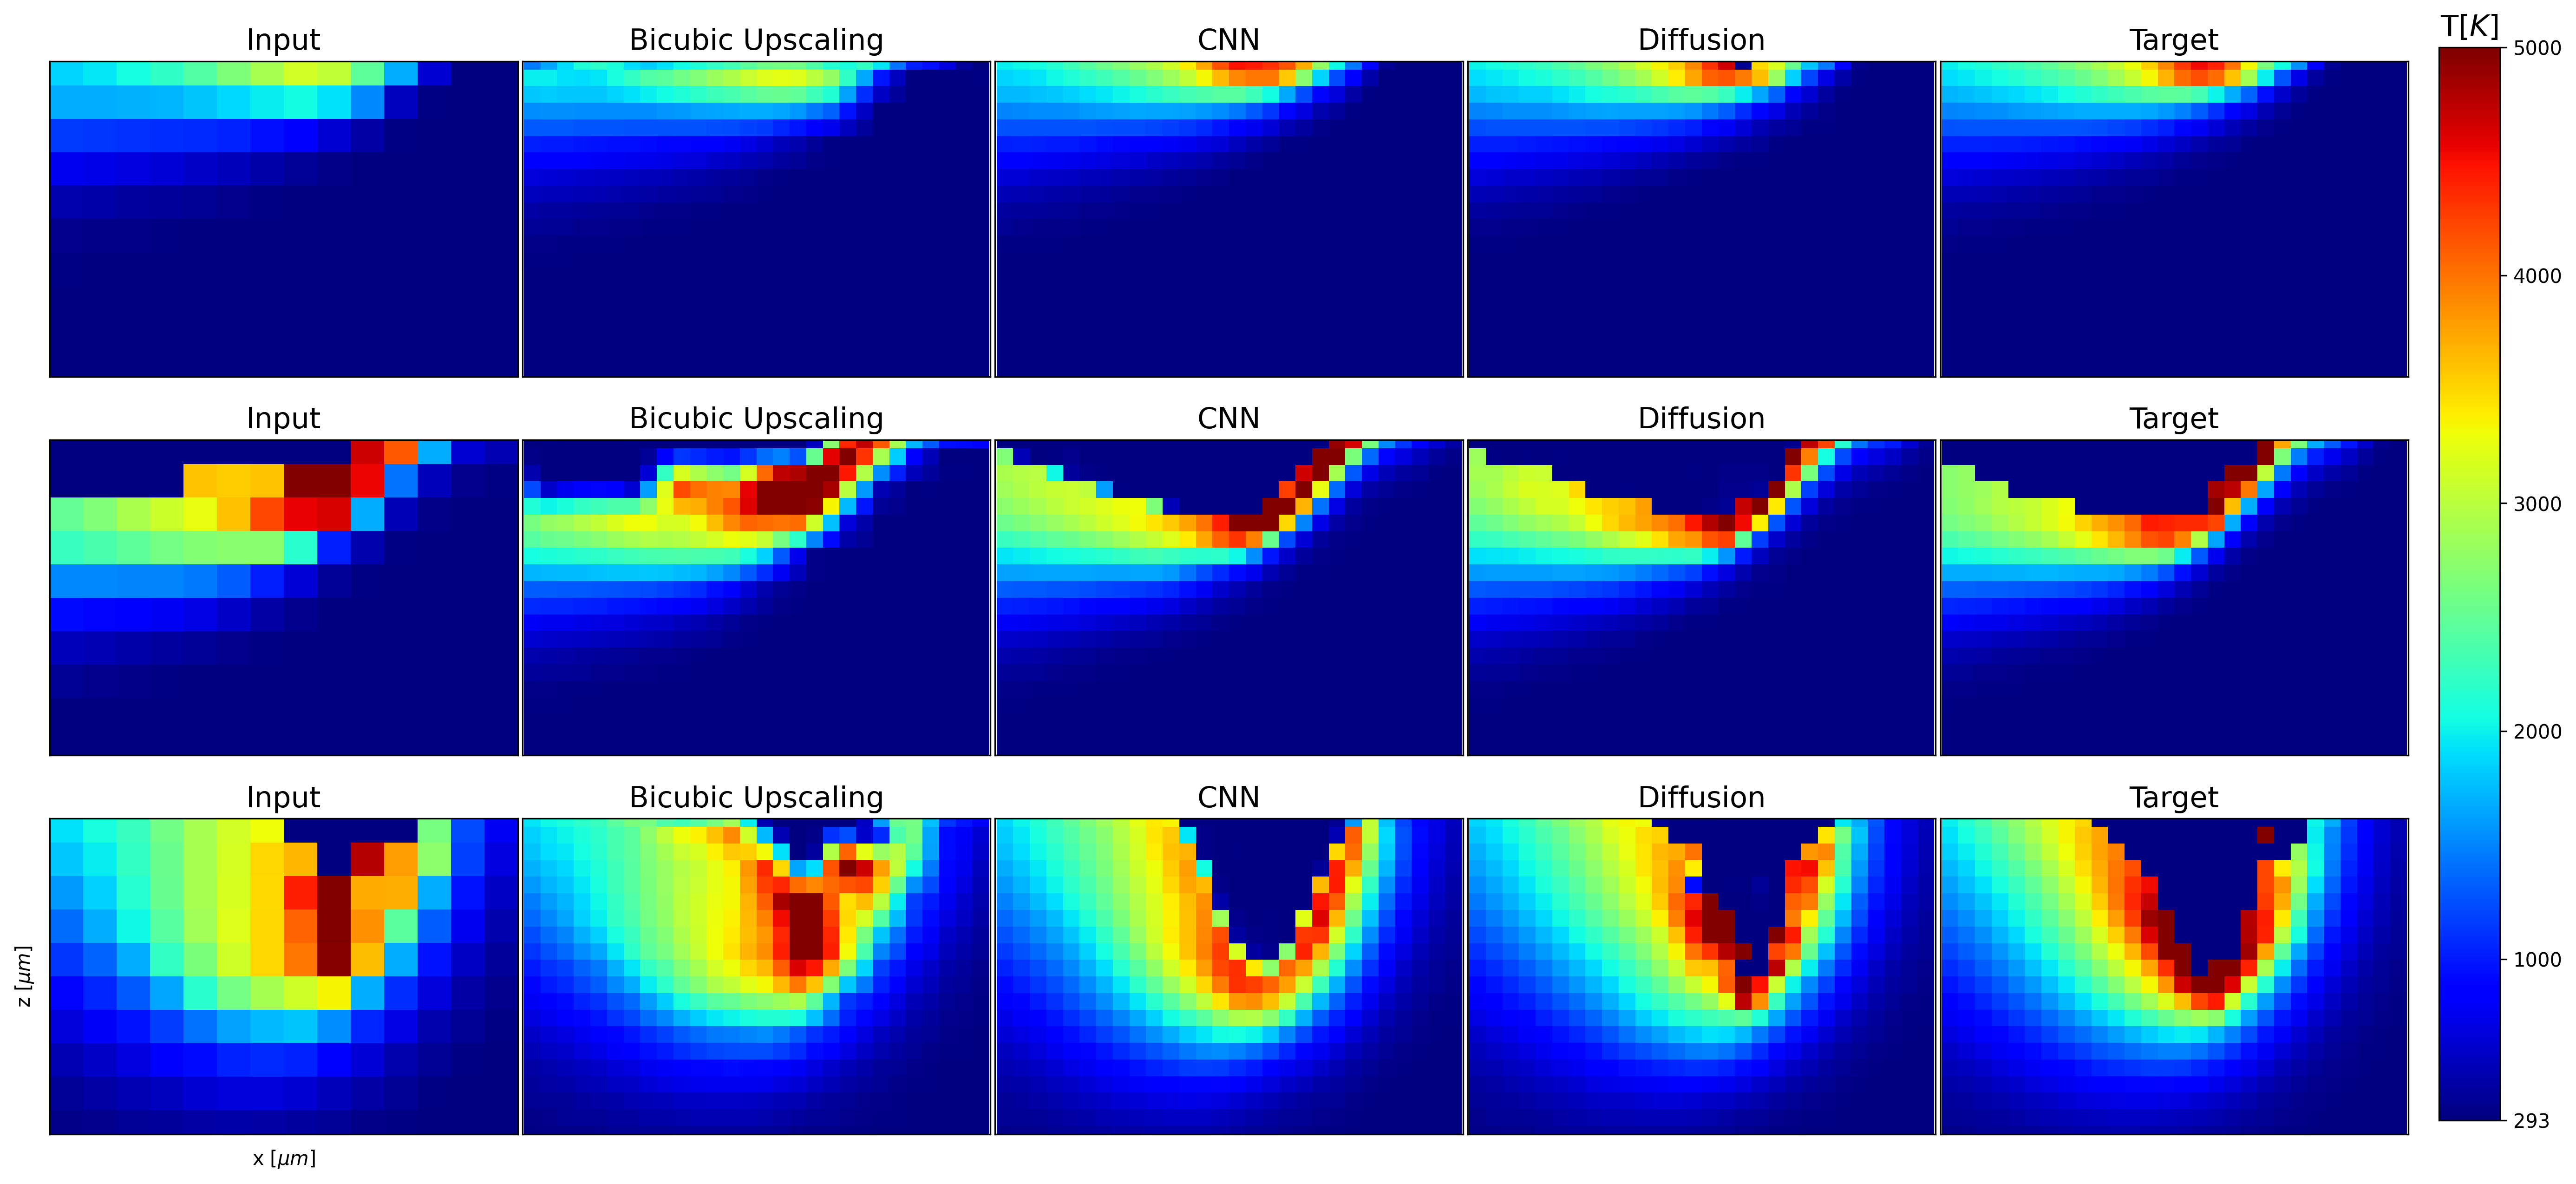

 42%|████▏     | 1709/4094 [00:11<00:15, 153.80it/s] 


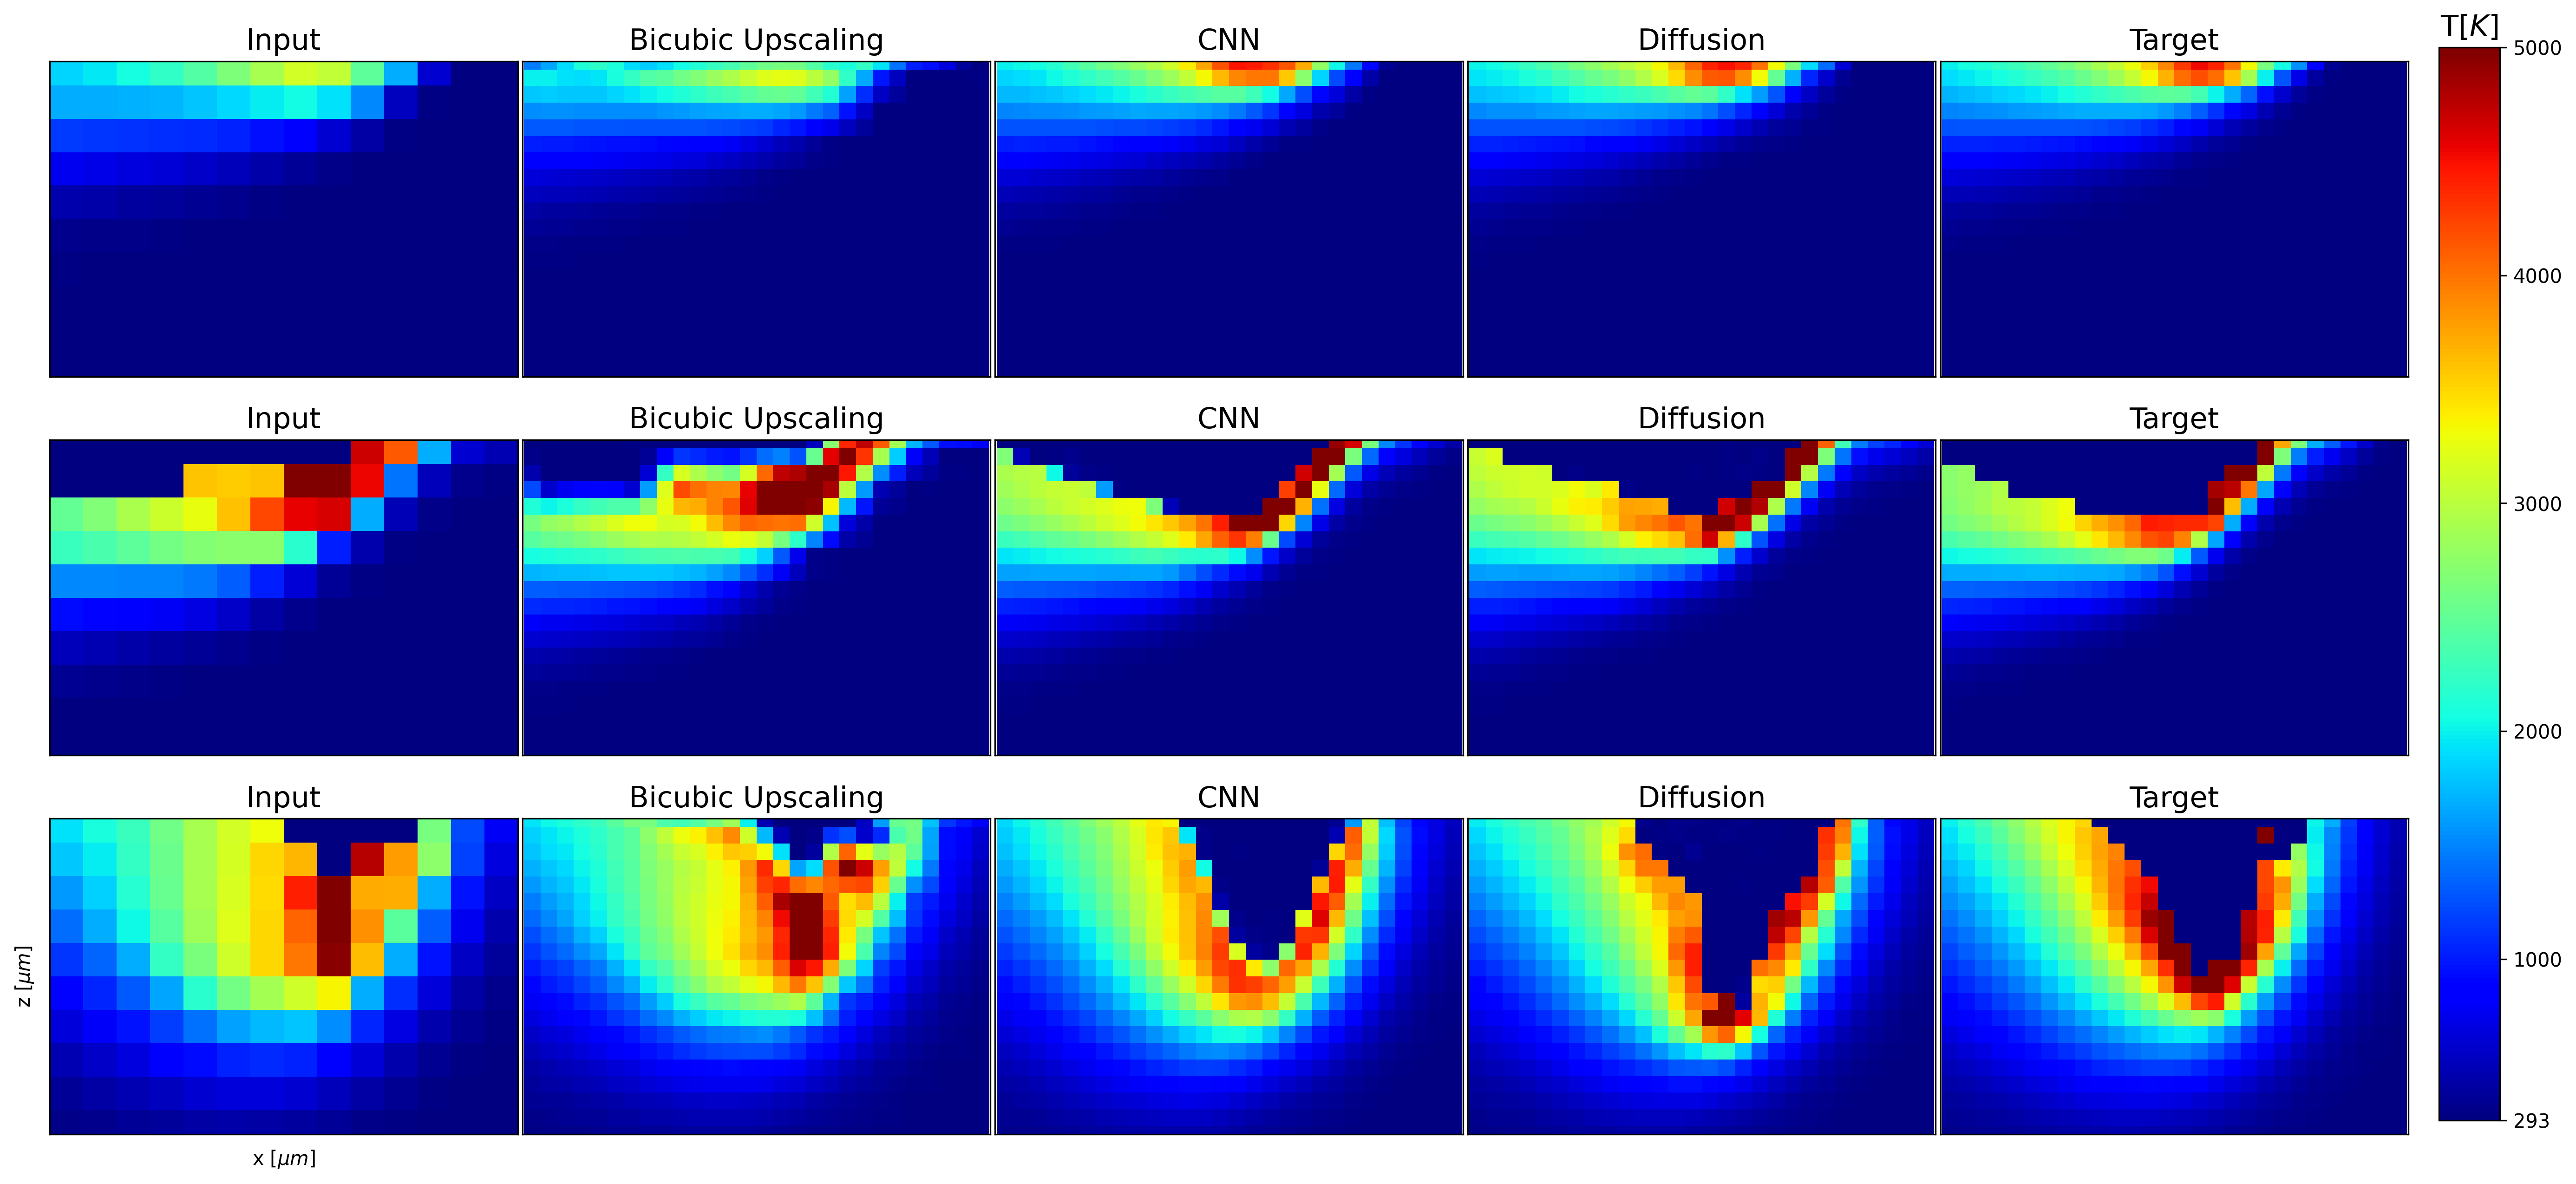

 42%|████▏     | 1709/4094 [00:11<00:15, 154.37it/s] 


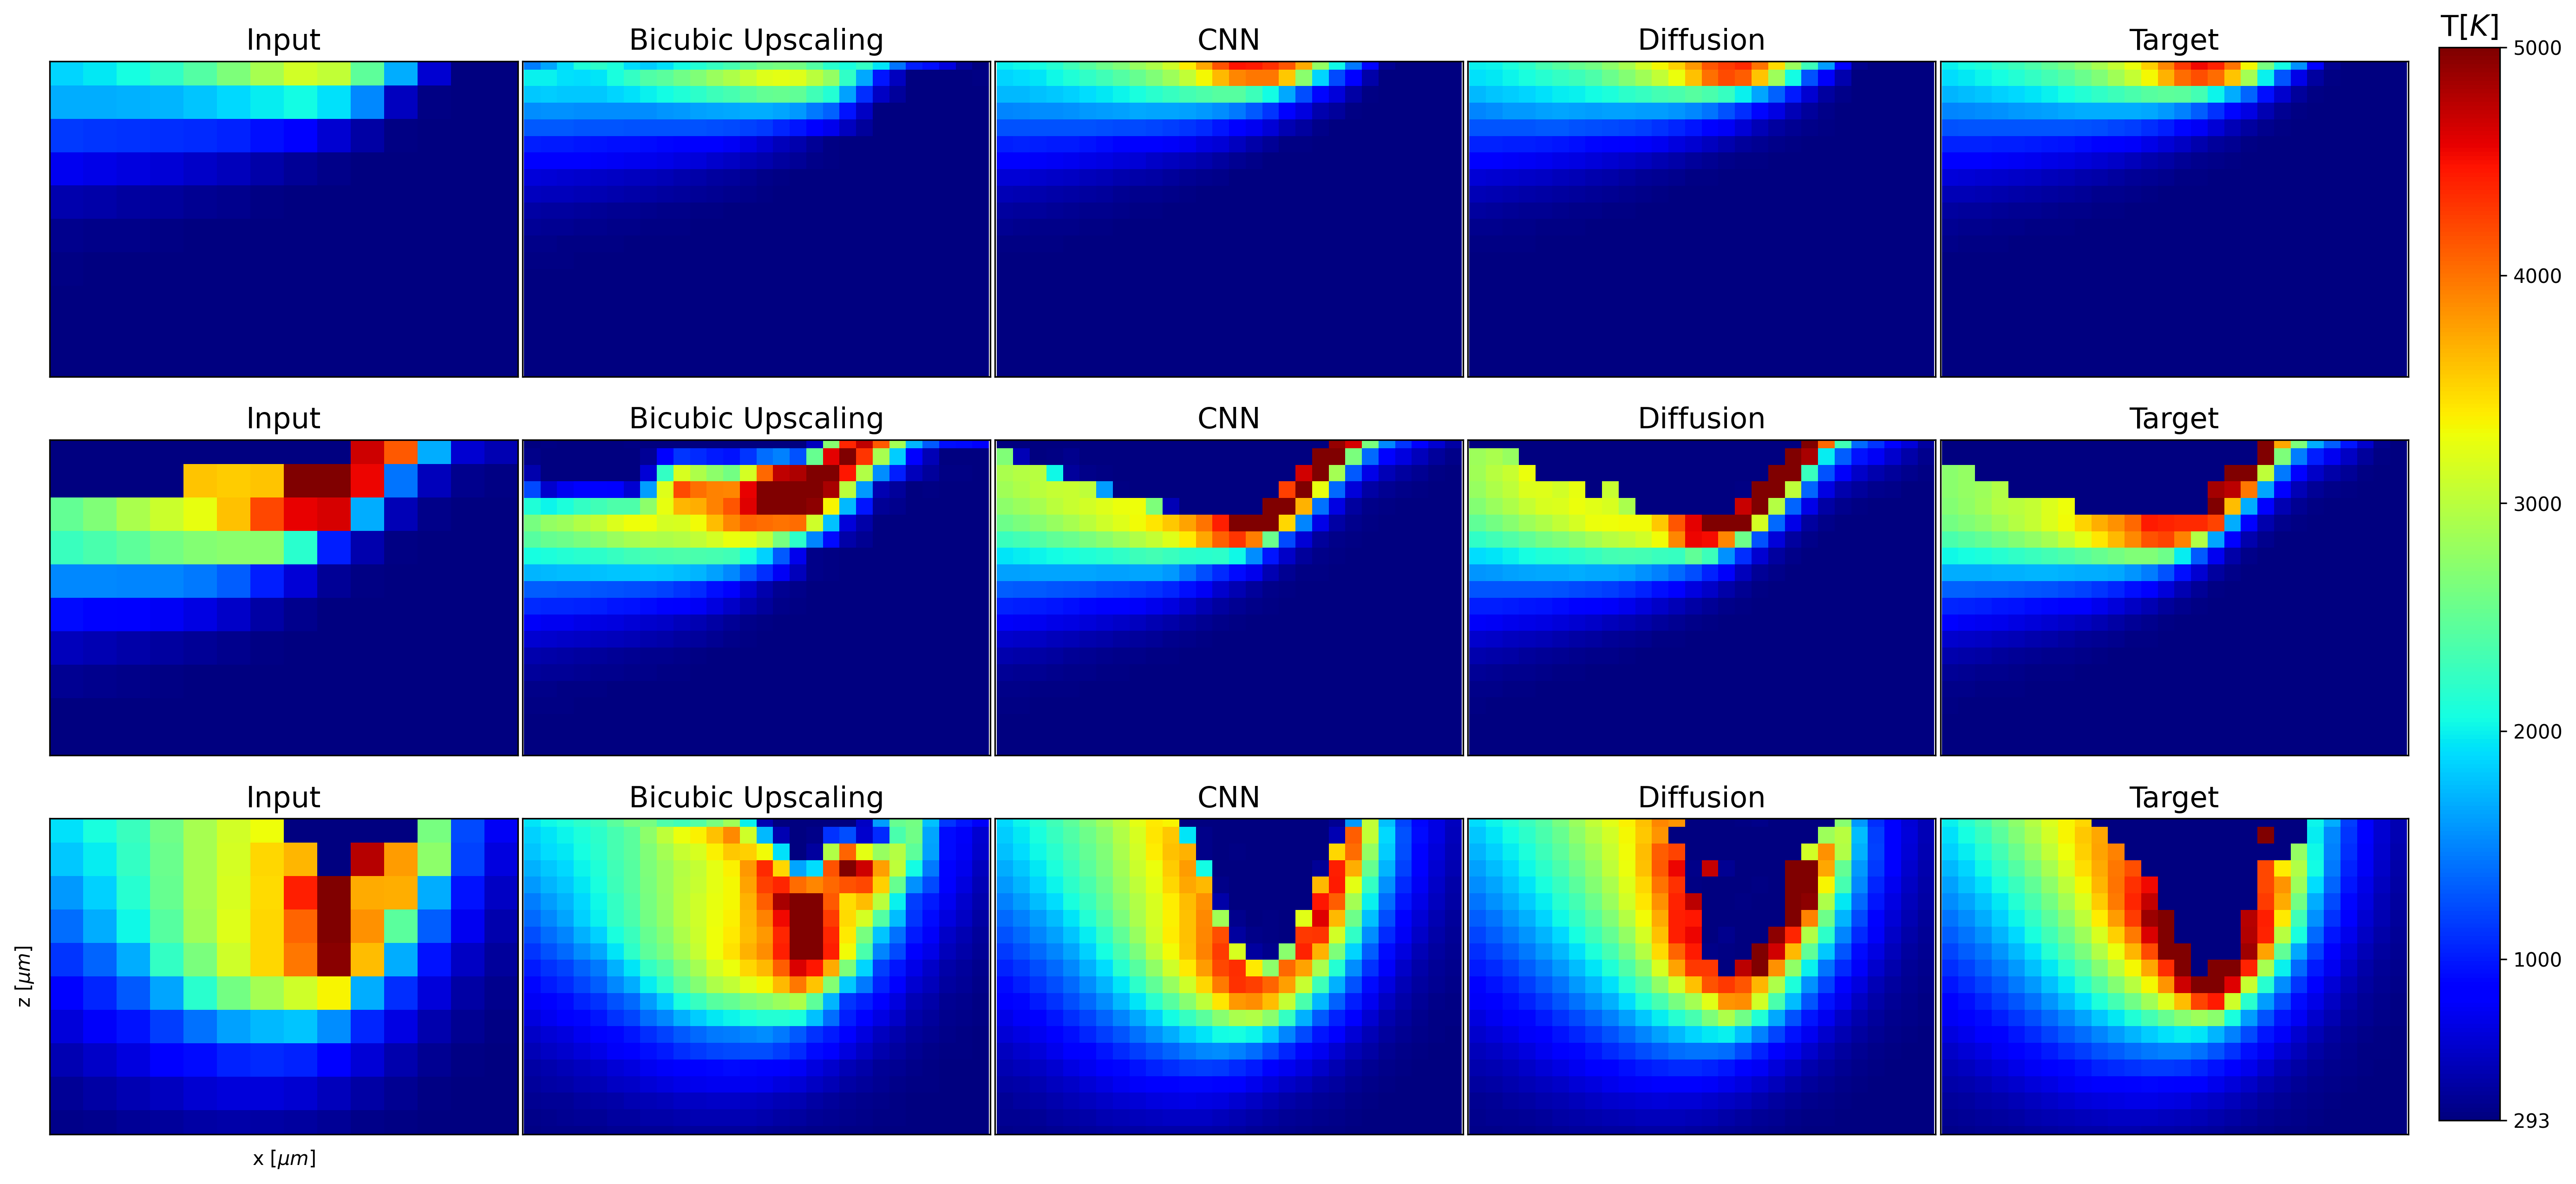

 42%|████▏     | 1709/4094 [00:12<00:17, 138.56it/s]


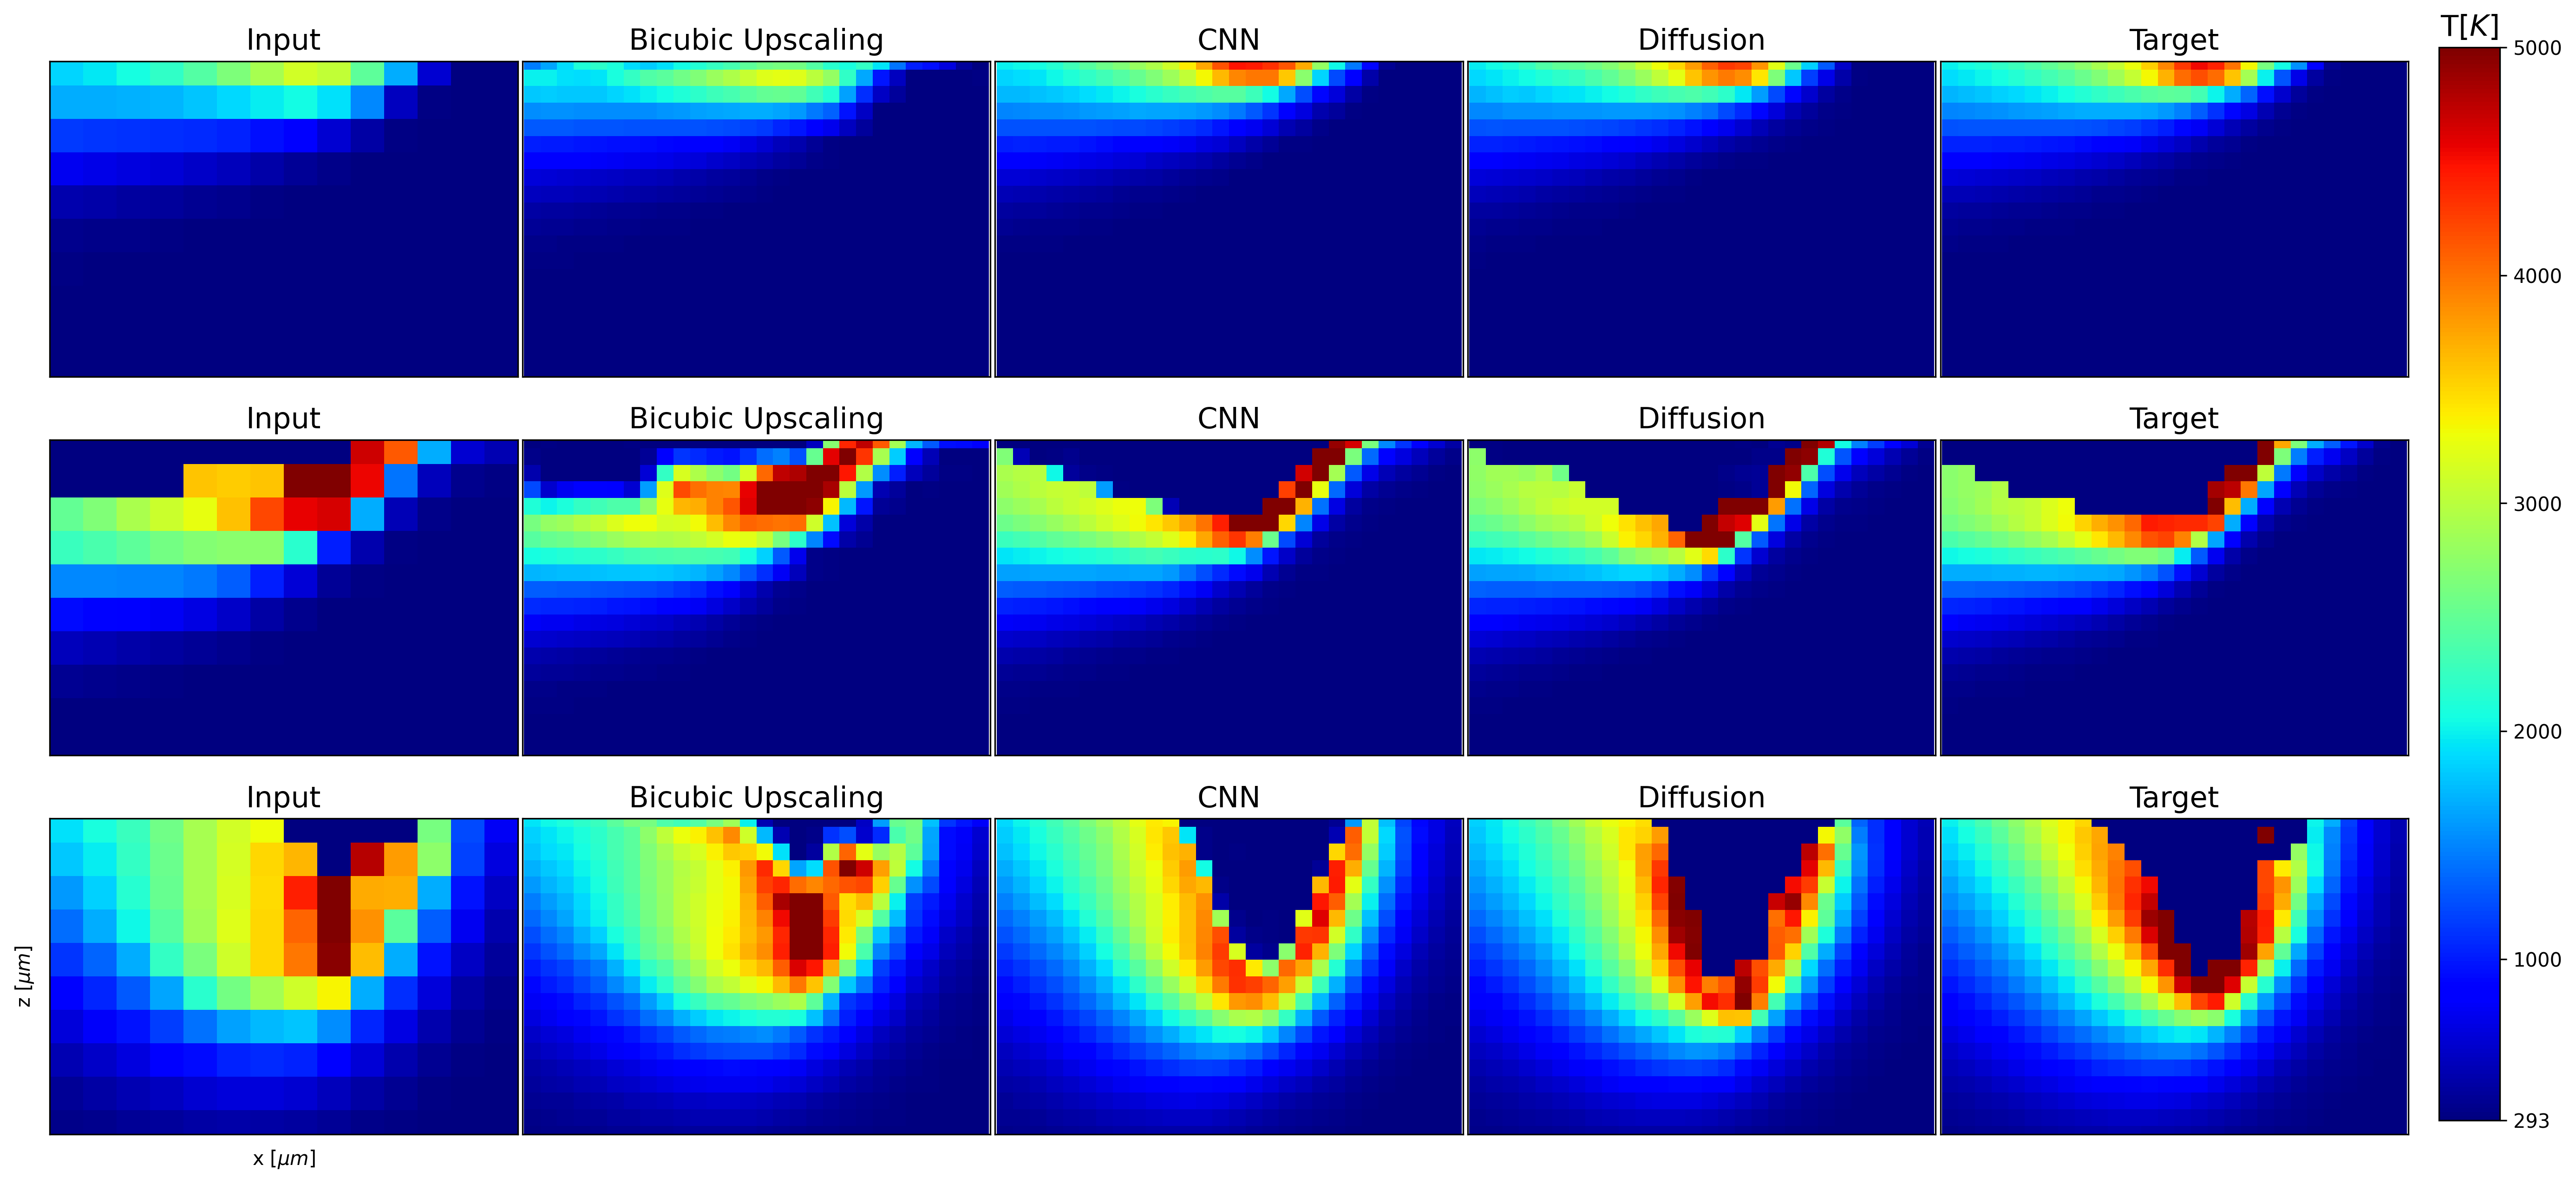

In [37]:
# for array in [input, upscaled_lr_data, result_diffusion, target]:

scaling_factor = 1

labels = ['Input', 'Bicubic Upscaling', 'CNN', 'Diffusion', 'Target']
batch_idxs = [399,2617,1708] # 130v1300 190v250 400v650
# batch_idxs = [0,1,2]
timesteps = 1000
skip = 1
for k in range(15):
    fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(2.8*7.8*scaling_factor, 10*scaling_factor), dpi=300)
    fig.patch.set_alpha(0)
    for j,(row, batch_index) in enumerate(zip(axs, batch_idxs)):
        for batch_idx, (res, hr, lr, upscaled_lr, info_full) in tqdm(enumerate(test_dataloader), total = len(test_dataloader) ):
            if batch_idx == batch_index:
                input, result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
                input, result_diffusion, target, _, _ = predict_modified_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,encoding = True,dataset =  train_dataset,seq= None, timesteps = timesteps,skip = skip, schedule = 'linear')
                upscaled_lr_data = test_dataloader.dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr')
                for i, (ax, array, label) in enumerate(zip(row,[input, upscaled_lr_data, result, result_diffusion, target], labels )):
                    if i == 0:
                        division_factor = 2
                    else:
                        division_factor  = 1
                    xx, yy = np.meshgrid(np.arange(28//division_factor)*10*division_factor, np.arange(20//division_factor)*10*division_factor)
                    
                    im = ax.pcolormesh(xx, yy, array[field_idx][0,2//division_factor:30//division_factor,array.shape[-1]//4:3*array.shape[-1]//4].T, vmin=293, vmax=5000, cmap='jet')
                    ax.axis('equal')
                    ax.set_ylim([yy.min(), yy.max()])
                    # if i ==  0 and j == 0:
                        
                        
                        # frame_tick()
                    # else:
                    # ax.axis('off')
                    ax.set_title(label, fontsize = 15)
                    ax.xaxis.set_tick_params(labelbottom=False)
                    ax.yaxis.set_tick_params(labelleft =False)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    if j == len(axs) - 1  and i == 0:
                        ax.set_ylabel(r'z $[\mu m]$')
                        ax.set_xlabel(r'x $[\mu m]$')
            elif batch_idx > batch_index:
                break
            
    fig.subplots_adjust(wspace = 0.01)#, hspace = 0.1)
    # fig.subplots_adjust()


    # Add colorbar
    cax = fig.add_axes([0.91, 0.12, 0.02, 0.77])
    clb = fig.colorbar(im, cax=cax)
    clb.set_ticks([293, 1000, 2000, 3000, 4000, 5000])
    clb.ax.set_title(r'T$[K]$', fontsize=15)
    plt.show()

In [15]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def multifield_plot_images(input, result, target, modeltype, field_idx, field_key, split = 'train', timesteps = 200, title = '', timestep = None):
    
    result  = result
    scaling_factor = 1.5
    dpi = 90
    min_temp = 293
    max_temp = 5000
    method = 'Direct'

    # if timestep is None:
    #     plt.title('[{} Data] Low Resolution, {}'.format(split, method), fontsize = 10)
    # else:
    #     plt.title(r'[{} Data] Low Resolution, {}, $i$ = {}'.format(split, method, timestep), fontsize = 10)
        
    axis_lim_min= {'vx': -30, 'vy':-30, 'vz':-30, 'temperature':293, 'pressure': 900000, 'liqlabel':0}
    axis_lim_max= {'vx': 30, 'vy':30, 'vz':30, 'temperature':5000, 'pressure': 4*1000000, 'liqlabel':1}
    titles= {'vx': r"$v_x$ [cm/s]", 'vy':r"$v_y$ [cm/s]", 'vz':r"$v_z$ [cm/s]", 'temperature':"T [K]", 'pressure': "P [Pa]", 'liqlabel':"Liquid Volume Fraction"}

    # os.makedirs('lrenc_saved_figures', exist_ok = True)
    # plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)
    # plt.imshow(input[field_idx].T, cmap = 'jet',vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key], origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    # plt.xlabel(r'x $[\mu m]$')
    # plt.ylabel(r'z $[\mu m]$')
    # clb = plt.colorbar()
    # clb.ax.set_title(r'T$[K]$',fontsize=10)


    plt.figure(dpi = dpi)
    ax = plt.gca()
    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    im = ax.imshow(input[field_idx][:,input.shape[-1]//4:3*input.shape[-1]//4].T, cmap = 'jet',vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key], origin = 'lower',  extent=[0*5,80*5,0*5,40*5])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    clb=plt.colorbar(im, cax=cax)
    clb.ax.set_title(r'T$[K]$',fontsize=10)

    
    frame_tick()

    # plt.title('t = {} s, P = {} W, V = {} mm/s'.format(0.5*i/100, power, velocity))

    plt.savefig( title + 'input.png')

    # plt.show()
    plt.clf()
    # plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    # plt.imshow((target[field_idx]).T, cmap = 'jet', vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key], origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    # plt.xlabel(r'x $[\mu m]$')
    # plt.ylabel(r'z $[\mu m]$')
    # # clb = plt.colorbar()
    # clb = plt.colorbar()
    # clb.ax.set_title(titles[field_key])


    plt.figure(dpi = dpi)
    ax = plt.gca()
    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    im = ax.imshow(target[field_idx][:,target.shape[-1]//4:3*target.shape[-1]//4].T, cmap = 'jet',vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key], origin = 'lower',  extent=[0*5,80*5,0*5,40*5])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    clb=plt.colorbar(im, cax=cax)
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    # clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    # plt.title('[{} Data] High Resolution'.format(split), fontsize = 10)
    # plt.title(r'[{} Data] High Resolution, {}, $i$ = {}'.format(split, method, timestep), fontsize = 10)
    # plt.savefig()
    # plt.savefig('lrenc_saved_figures/target' + title + '.png')
    plt.savefig( title + 'target.png')


    # plt.show()
    plt.clf()

    # plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    # plt.imshow((result[field_idx]).T, cmap = 'jet', vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key], origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    # plt.xlabel(r'x $[\mu m]$')
    # plt.ylabel(r'z $[\mu m]$')
    # clb = plt.colorbar()
    # clb.ax.set_title(titles[field_key])
    plt.figure(dpi = dpi)
    ax = plt.gca()
    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    im = ax.imshow(result[field_idx][:,result.shape[-1]//4:3*result.shape[-1]//4].T, cmap = 'jet',vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key], origin = 'lower',  extent=[0*5,80*5,0*5,40*5])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    clb=plt.colorbar(im, cax=cax)
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    # plt.title('[{} Data], {} Timesteps, {} Output'.format(split,str(timesteps), modeltype), fontsize = 10)
    # plt.title(r'[{} Data], {} Timesteps, {} Output, $i$ = {}'.format(split,str(timesteps), modeltype, str(timestep)), fontsize = 10)
    # plt.savefig()
    # plt.savefig('lrenc_saved_figures/result'+ title + '.png')
    plt.savefig( title + 'result.png')


    # plt.show()
    plt.clf()
    plt.close('all')

In [12]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_images(input, result, target, modeltype, split = 'train', timesteps = 200, title = '', timestep = None, save =False):
    
    result  = result
    scaling_factor = 1.5
    dpi = 150
    min_temp = 293
    max_temp = 5000
    method = 'Direct'
    # os.makedirs('lrenc_saved_figures', exist_ok = True)
    # plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)
    # plt.imshow(input.T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    # clb = plt.colorbar()

    plt.figure(dpi = dpi)
    ax = plt.gca()
    if timestep is None:
        plt.title('[{} Data] Low Resolution, {}'.format(split, method), fontsize = 10)
    else:
        plt.title(r'[{} Data] Low Resolution, {}, $i$ = {}'.format(split, method, timestep), fontsize = 10)
    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')

    im = ax.imshow(input[:,input.shape[-1]//2:].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000,  extent=[0*5,80*5,0*5,40*5])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    clb=plt.colorbar(im, cax=cax)
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    if save:
        plt.savefig( title + 'input.png')
    else:
        plt.show()
    # plt.show()
    plt.clf()
    # plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    # plt.imshow((target).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    # plt.xlabel(r'x $[\mu m]$')
    # plt.ylabel(r'z $[\mu m]$')
    # clb = plt.colorbar()
    # clb.ax.set_title(r'T$[K]$',fontsize=10)
    # frame_tick()
    # # plt.title('[{} Data] High Resolution'.format(split), fontsize = 10)
    # plt.title(r'[{} Data] High Resolution, {}, $i$ = {}'.format(split, method, timestep), fontsize = 10)
    # plt.savefig()
    # plt.savefig('lrenc_saved_figures/target' + title + '.png')


    plt.figure(dpi = dpi)
    ax = plt.gca()
    if timestep is None:
        plt.title('[{} Data] High Resolution'.format(split), fontsize = 10)
    else:
        plt.title(r'[{} Data] High Resolution, {}, $i$ = {}'.format(split, method, timestep), fontsize = 10)
    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')

    im = ax.imshow(target[:,target.shape[-1]//2:].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000,  extent=[0*5,80*5,0*5,40*5])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    clb=plt.colorbar(im, cax=cax)
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()



    if save:
        plt.savefig( title + 'target.png')
    else:
        plt.show()

    # plt.show()
    plt.clf()

    # plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    # plt.imshow((result).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    # plt.xlabel(r'x $[\mu m]$')
    # plt.ylabel(r'z $[\mu m]$')
    # clb = plt.colorbar()
    # clb.ax.set_title(r'T$[K]$',fontsize=10)
    # frame_tick()
    # # plt.title('[{} Data], {} Timesteps, {} Output'.format(split,str(timesteps), modeltype), fontsize = 10)
    # plt.title(r'[{} Data], {} Timesteps, {} Output, $i$ = {}'.format(split,str(timesteps), modeltype, str(timestep)), fontsize = 8)


    plt.figure(dpi = dpi)
    ax = plt.gca()
    if timestep is None:
        plt.title('[{} Data], {} Timesteps, {} Output'.format(split,str(timesteps), modeltype), fontsize = 10)
    else:
        plt.title(r'[{} Data], {} Timesteps, {} Output, $i$ = {}'.format(split,str(timesteps), modeltype, str(timestep)), fontsize = 8)
    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')

    im = ax.imshow(result[:,result.shape[-1]//2:].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000,  extent=[0*5,80*5,0*5,40*5])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    clb=plt.colorbar(im, cax=cax)
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    # plt.savefig()
    # plt.savefig('lrenc_saved_figures/result'+ title + '.png')
    if save:
        plt.savefig( title + 'result.png')
    else:
        plt.show()

    # plt.show()
    plt.clf()
    plt.close('all')

### Plot test set melt pools

In [13]:
# model = load_diffusion(simlinear2000.folder)
# mobilenet = load_mobilenet(mobilenet_results_dir)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
last_power = ''
skip = 50
import time 
field_names = field_names#['vx', 'temperature', 'vy', 'vz', 'liqlabel']
verbose = False
for batch_idx, (res, hr, lr, upscaled_lr, info_full) in tqdm(enumerate(test_dataloader), total = len(test_dataloader), ):  
      
        for timesteps in [1000]:
        # timesteps = 2000
            for skips in [50]:
                oldtime = time.time()
                modeltype = 'RRDNss316l_standardize_test_temp_3_21'
                # print(hr.shape, lr.shape, upscaled_lr.shape, res.shape)
                info = info_full[0]
                input, result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
                # print(time.time()-oldtime)
                if last_power != 'power' + str(info[0].item()) + 'vel' + str(info[1].item()):
                    timestep = 0
                else:
                    # print('timestep updated')
                    timestep += 1
                
                for field_idx, field_key in enumerate(field_names):
                    time_elapsed = time.time()-oldtime
                    print(time_elapsed)
                    # print(info.shape, "info")
                    # print('power' + str(info[0].item()))# + 'vel' + str(info[1].item()))
                    folder = modeltype + 'saved_figures/{}/'.format(field_key)  + 'power' + str(info[0].item()) + 'vel' + str(info[1].item())
                    
                    os.makedirs(folder,exist_ok = True)

                    title  = os.path.join(folder,  'batch_{:06}_'.format(batch_idx)+ 'time' + '{:07}'.format(int(np.round(info[2].item()*1e6))))
                    if verbose:
                        print(title, timestep)
                        print(input.shape, result.shape, target.shape)
                        print(time_elapsed, "elapsed time")
                    multifield_plot_images(input[0,:,:, :], result[0], target[0][:, :], field_idx = field_idx, field_key = field_key, timestep = timestep, split = 'Validation', modeltype =modeltype, timesteps = timesteps//skips, title =  title)
                    last_power = 'power' + str(info[0].item()) + 'vel' + str(info[1].item()) 
                modeltype = 'Diffusionss316l_3_21' 
                # input, result_diffusion, target, xs, b = predict_ddim_diffusion(model, lr_enc, res[0:1], hr[0:1], lr[0:1], upscaled_lr[0:1],train_dataset,seq= None, timesteps = timesteps,skip = skips, schedule = 'linear')
                input, result_diffusion, target, _, _ = predict_modified_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,encoding = True,dataset =  train_dataset,seq= None, timesteps = timesteps,skip = skip, schedule = 'linear')
                for field_idx, field_key in enumerate(field_names):
                    info = info_full[0]
                    time_elapsed = time.time()-oldtime
                    print(time_elapsed)
                    # print(info.shape, "info")
                    # print('power' + str(info[0].item()))# + 'vel' + str(info[1].item()))
                    # if last_power != 'power' + str(info[0].item()) + 'vel' + str(info[1].item()):
                    #     timestep = 0
                    # else:
                    #     timestep += 1
                    
                    folder = modeltype +'saved_figures/{}/'.format(field_key)  + 'power' + str(info[0].item()) + 'vel' + str(info[1].item()) 

                    os.makedirs(folder,exist_ok = True)
                    title  = os.path.join(folder,  'batch_{:06}_'.format(batch_idx)+ 'time' + '{:07}'.format(int(np.round(info[2].item()*1e6))))
                    if verbose:
                        print(title, timestep)
                        print(input.shape, result.shape, target.shape)
                        print(time_elapsed, "elapsed time")
            # break
                    multifield_plot_images(input[0,:,:, :], result_diffusion[0], target[0][:, :], field_idx = field_idx, field_key = field_key, timestep = timestep, split = 'Validation', modeltype =modeltype, timesteps = timesteps//skips, title =  title)
                last_power = 'power' + str(info[0].item()) + 'vel' + str(info[1].item())  


  0%|          | 0/4094 [00:00<?, ?it/s]

0.08431577682495117


  0%|          | 0/4094 [00:00<?, ?it/s]


NameError: name 'predict_modified_ddim_diffusion' is not defined

In [ ]:
def plot_srdiff_contours(input, result, target, modeltype, split = 'train', max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Direct', save = False, mpfname = '', kpfname = ''):
    profile_result, kp_result = get_profile(result, mesh = 10, max_idx = 30)

    profile_gt, kp_gt = get_profile(target, mesh = 10, max_idx = 30)
    profile_input, kp_input = get_profile(input, mesh = 10, max_idx = 15)

    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),100 +  kp_input*20 - 400, '--', label = 'Bicubic Interpolation')
    plt.plot(10*np.arange(40), 100 + kp_result*10 - 400, label = 'Encoder Output' )
    plt.plot(10*np.arange(40), 100 + kp_gt*10 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()

    legend()
    plt.ylim([-200, 0])
    plt.title('[{} Data] Keyhole Depth, {}'.format(split, modeltype), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    if save:
        # print('Saving')
        plt.savefig(kpfname, bbox_inches = 'tight')
    else:
        plt.show()

    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),100 + profile_input*20 - 400, '--', label = 'Bicubic Interpolation')
    plt.plot(10*np.arange(40), 100 + profile_result*10 - 400, label = 'Encoder Output' )
    plt.plot(10*np.arange(40),100 + profile_gt*10 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    plt.ylim([-200, 0])

    frame_tick()

    legend()
    plt.ylim([-200, 0])
    plt.title('[{} Data] Melt Pool Depth, {}'.format(split, modeltype), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    if save:
        
        plt.savefig(mpfname, bbox_inches = 'tight')
    else:
        plt.show()
    plt.close('all')
    # plt.show()

In [ ]:
def get_profile(image, mesh = 5, max_idx = None):
    image = image[1].T
    binarized = image > 1900
    profile = []
    keyholeprofile = []
    for i in range(binarized.shape[1]):
        coords = np.where(binarized[:,i])[0]
        if len(coords) > 0:
            profile.append(np.min(coords))
            keyholeprofile.append(np.max(coords))
        else:
            if max_idx == None:

                profile.append(binarized.shape[1])
                keyholeprofile.append(binarized.shape[1])
            else:
                profile.append(max_idx)
                # keyholeprofile.append(binarized.shape[1])
                keyholeprofile.append(max_idx)
    profile = np.array(profile)
    keyholeprofile = np.array(keyholeprofile)
    return(profile, keyholeprofile)

In [74]:
last_power = ''
modeltype = 'Encoder' # Defines part of the title of the image
enc_depths_sim = []
diff_depths_sim = []
gt_depths_sim = []

enc_kp_sim = []
diff_kp_sim = []
gt_kp_sim = []
gt_results = {}
enc_results = {}
diff_results = {}
mesh_hr = 10
factor = 2
skip = 50
timesteps  =1000
for batch_idx, (res, hr, lr, upscaled_lr, info) in tqdm(enumerate(test_dataloader), total = len(test_dataloader)):  
   

    oldtime = time.time()

    input, result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
    # print(timesteps, skip)
    input, result_diffusion, target, _, _ = predict_modified_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,encoding = True,dataset =  train_dataset,seq= None, timesteps = timesteps,skip = skip, schedule = 'linear')
    # input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, dev_dataloader.dataset)
    info = info[0] # info is technically returned with an extra dimension, this command removes it.
    time_elapsed = time.time()-oldtime
    # print(last_power)
    if last_power != 'power' + str(info[0].item()) + 'vel' + str(info[1].item()):
        
        timestep = 0

        enc_depths_sim = []
        diff_depths_sim = []
        gt_depths_sim = []

        enc_kp_sim = []
        diff_kp_sim = []
        gt_kp_sim = []

    else:
        timestep += 1
    # print(target.shape)
    profile_gt, kp_gt = get_profile(target[0], mesh = 10, max_idx = 30)
    profile_input, kp_input = get_profile(input[0], mesh = 20,max_idx = 15)
    profile_diff, kp_diff = get_profile(result_diffusion[0], mesh = 10, max_idx = 30)
    # profile_gt, kp_gt = get_profile(target[0])
    profile_enc, kp_enc = get_profile(result[0], mesh = 10, max_idx = 30)


    enc_kp_sim.append(mesh_hr*(20*factor-5*factor - np.min(kp_enc)))
    gt_kp_sim.append(mesh_hr*(20*factor-5*factor - np.min(kp_gt)))
    diff_kp_sim.append(mesh_hr*(20*factor-5*factor - np.min(kp_diff)))
    # diff_kp_sim.append(5*(80-np.min(kp_diff)))

    enc_depths_sim.append(mesh_hr*(20*factor-5*factor - np.min(profile_enc)))
    gt_depths_sim.append(mesh_hr*(20*factor-5*factor - np.min(profile_gt)))
    diff_depths_sim.append(mesh_hr*(20*factor-5*factor - np.min(profile_diff)))

    last_power = 'power' + str(info[0].item()) + 'vel' + str(info[1].item())  
    gt_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = gt_kp_sim
    enc_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = enc_kp_sim
    diff_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = diff_kp_sim
    gt_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = gt_depths_sim
    enc_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = enc_depths_sim
    diff_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = diff_depths_sim
    # if batch_idx > 3:

100%|██████████| 4094/4094 [18:24<00:00,  3.71it/s]


In [82]:
# from symbol import power


keyhole_errors = []
keyhole_enc_errors = []
power_errors = []
velocity_errors = []
power_mp_errors = []
vel_mp_errors = []
mp_errors = []
for key in enc_results.keys():
    power_text = key.split('power')[1].split('vel')[0]
    vel_text = key.split('vel')[1]
    if 'key' in key:
        power_errors.append(float(power_text))
        velocity_errors.append(float(vel_text))

        keyhole_errors.append(np.mean(np.abs(np.array(diff_results[key]) - np.array(gt_results[key]))))
        # keyhole_errors.append(np.mean(np.abs(np.array(diff_results[key]) - np.array(gt_results[key]))))
    else:
        mp_errors.append(np.mean(np.abs(np.array(diff_results[key]) - np.array(gt_results[key]))))
        power_mp_errors.append(float(power_text))
        vel_mp_errors.append(float(vel_text))




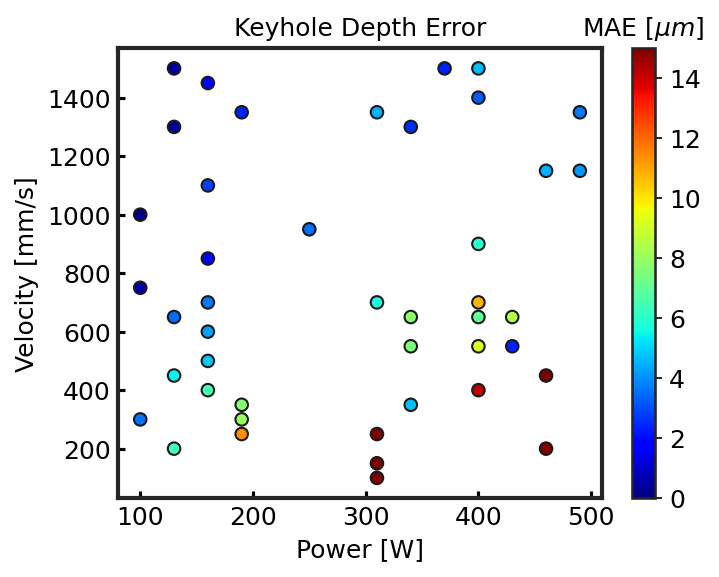

In [108]:
import importlib
import matplotlib as mpl
plt.figure(dpi = 150, figsize = np.array([4,3])*1.3)
# importlib.reload(mpl); importlib.reload(plt); importlib.reload(sns)
plt.title("Keyhole Depth Error")
plt.scatter(power_errors, velocity_errors, c= keyhole_errors, cmap =  'jet', vmin = 0, vmax = 15, edgecolor = 'k')
plt.xlabel('Power [W]')
plt.ylabel('Velocity [mm/s]')
frame_tick()
clb = plt.colorbar()
clb.ax.set_title('MAE [$\mu m$]')
plt.show()

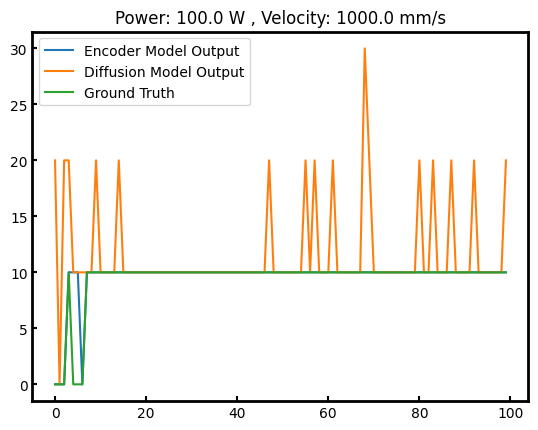

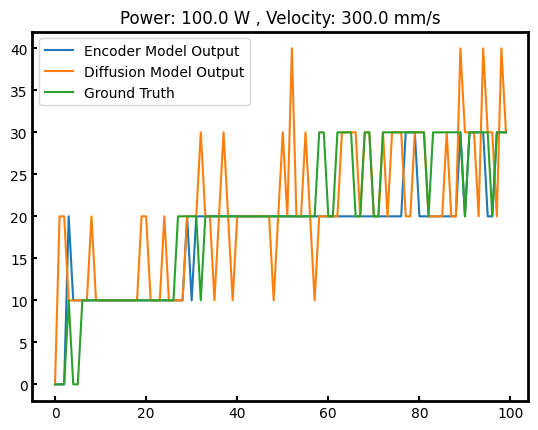

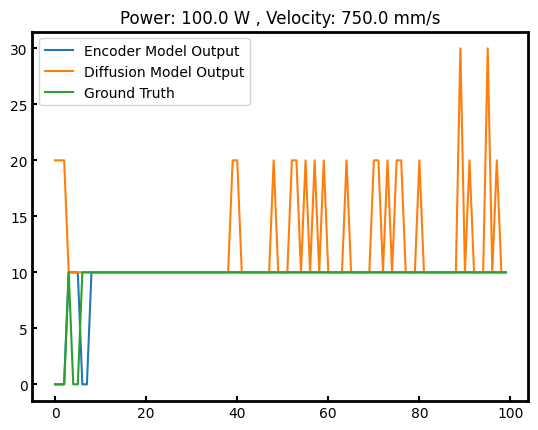

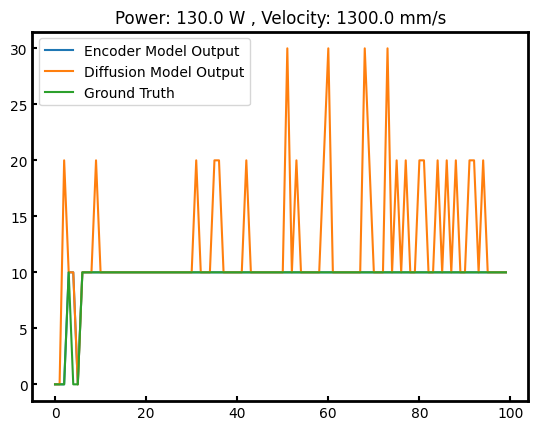

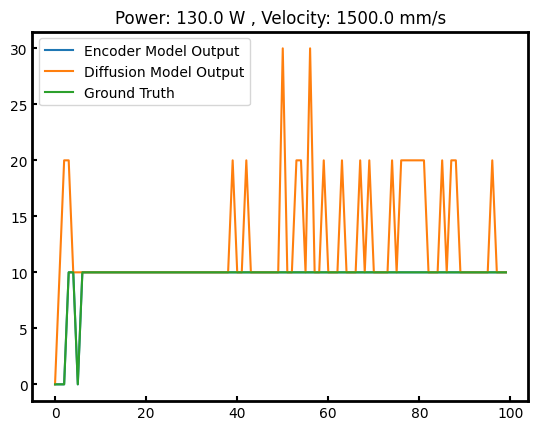

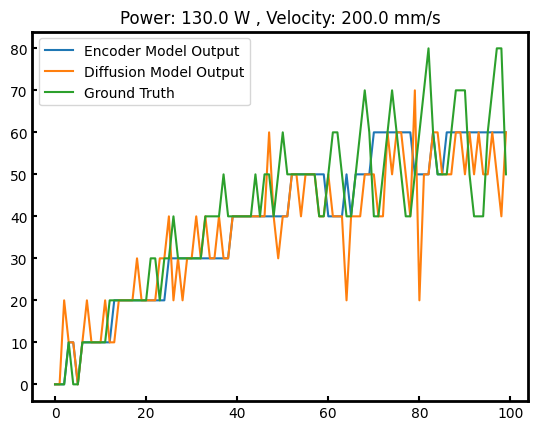

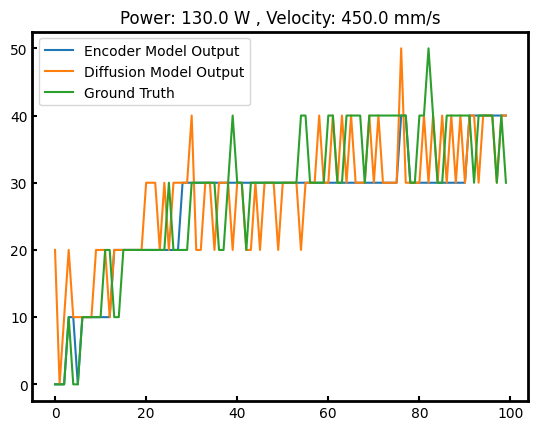

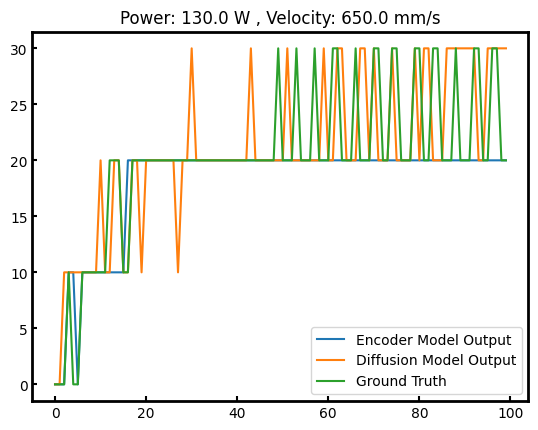

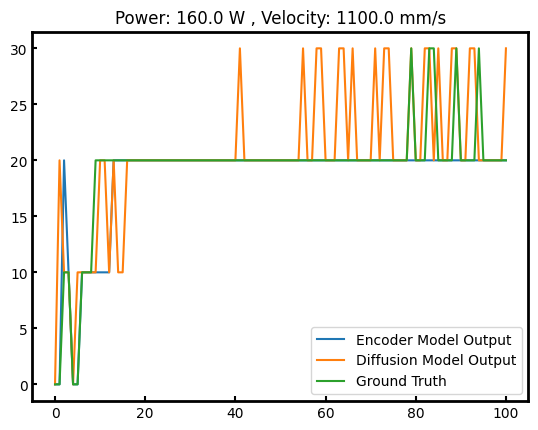

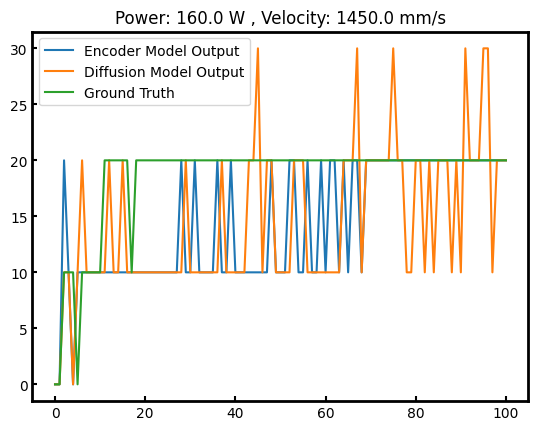

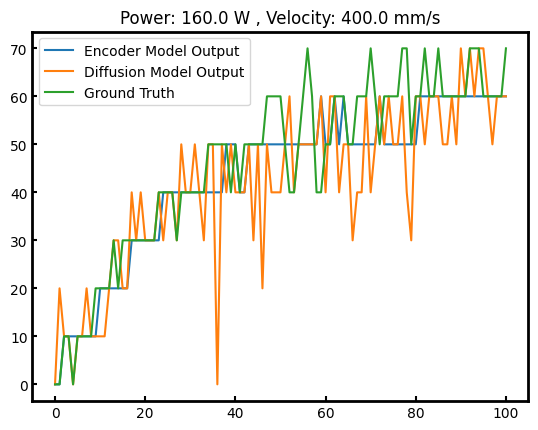

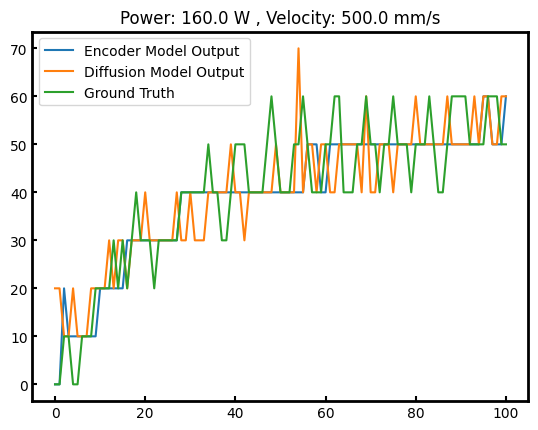

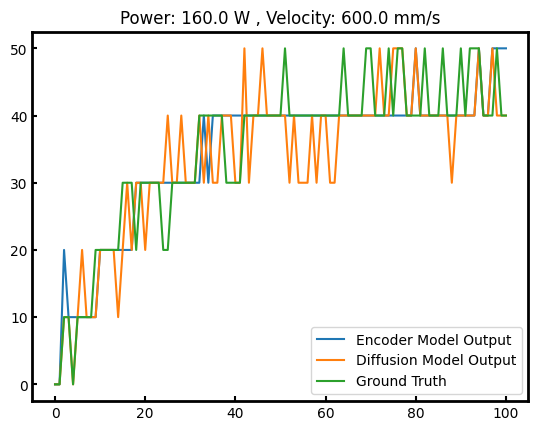

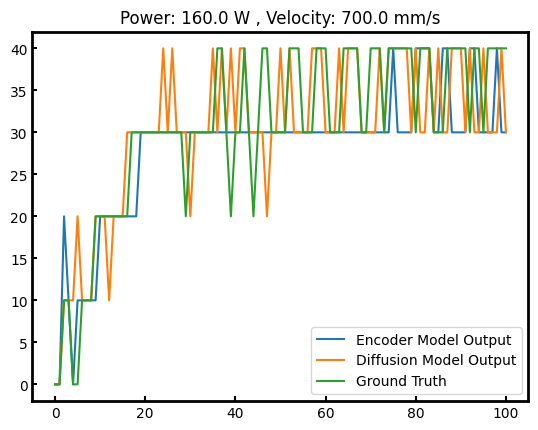

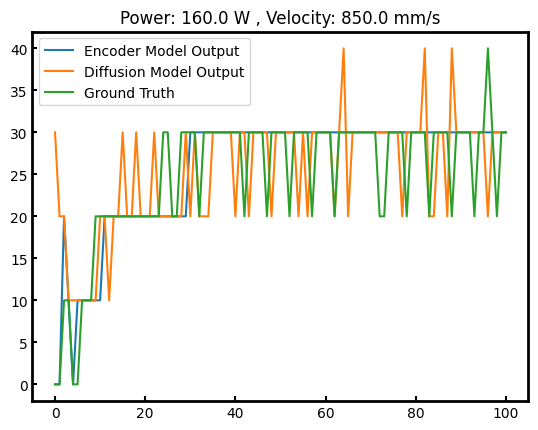

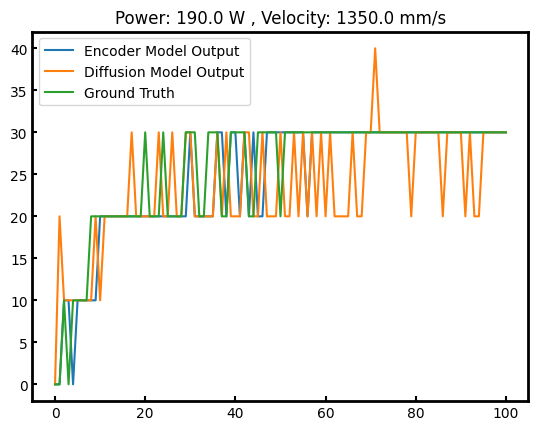

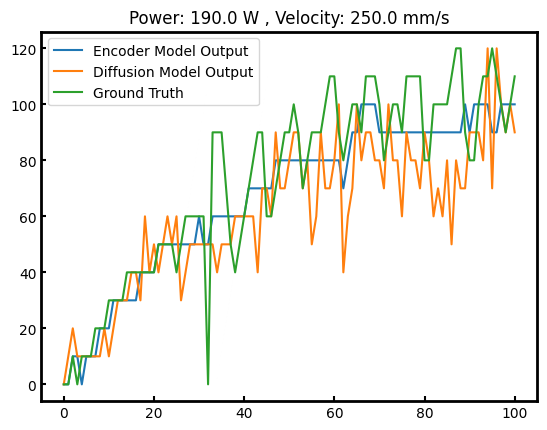

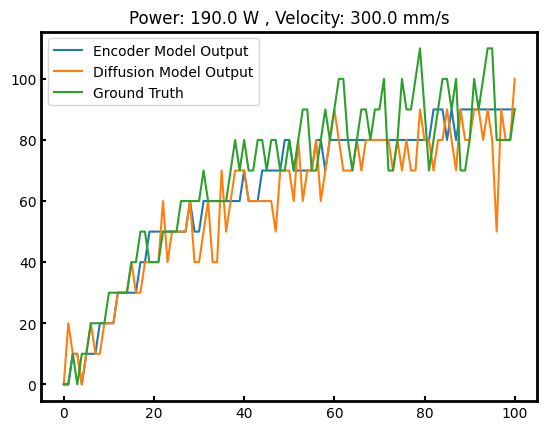

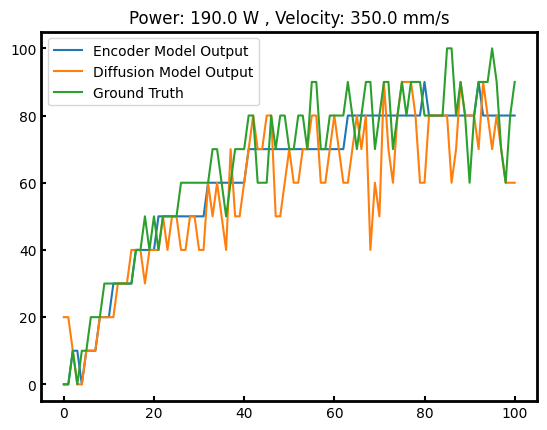

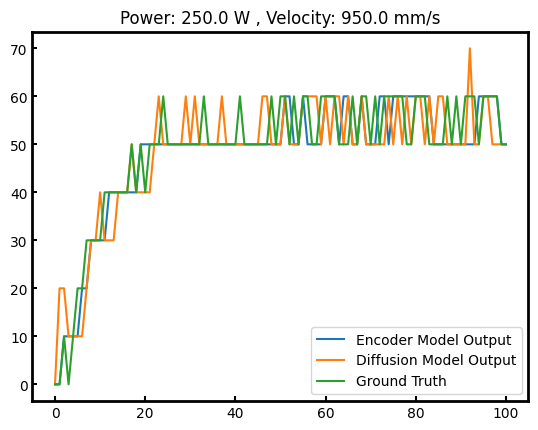

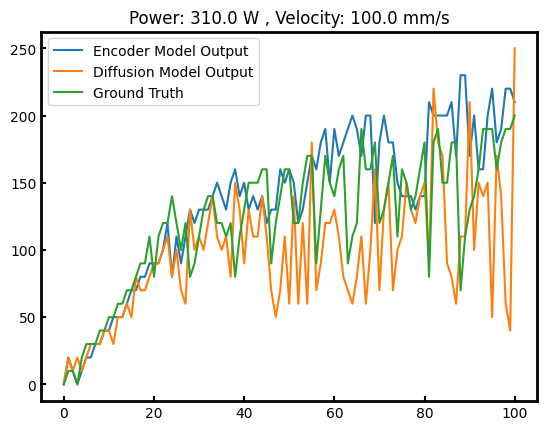

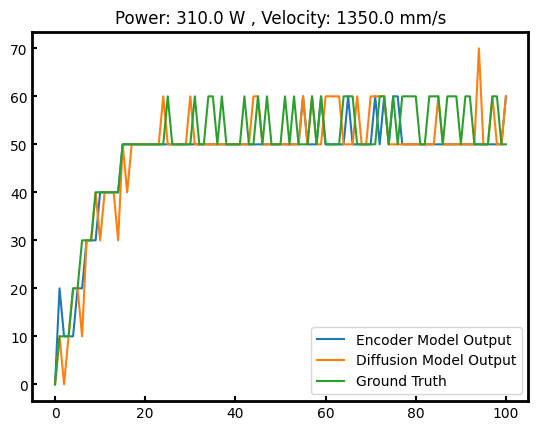

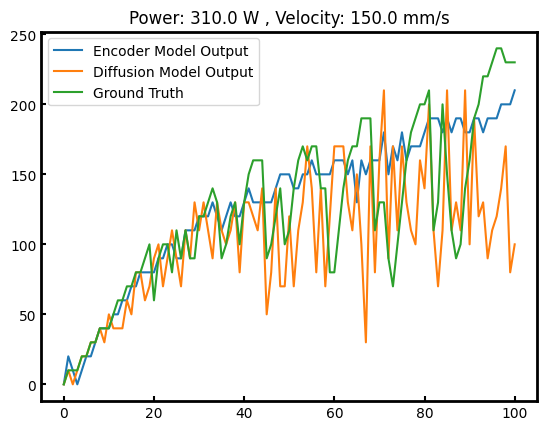

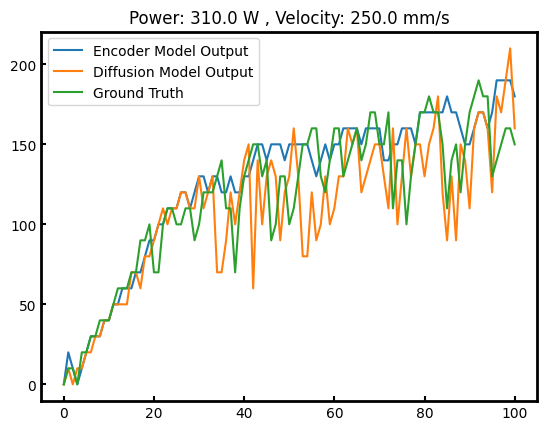

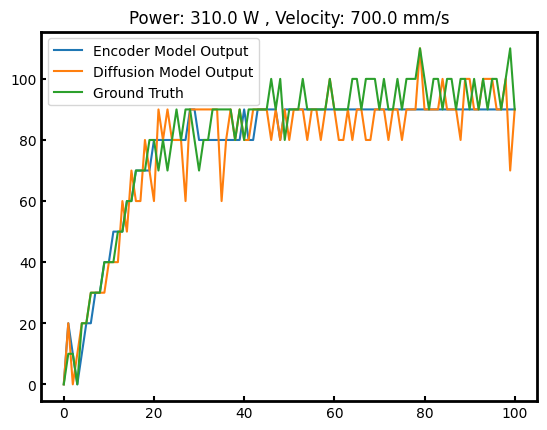

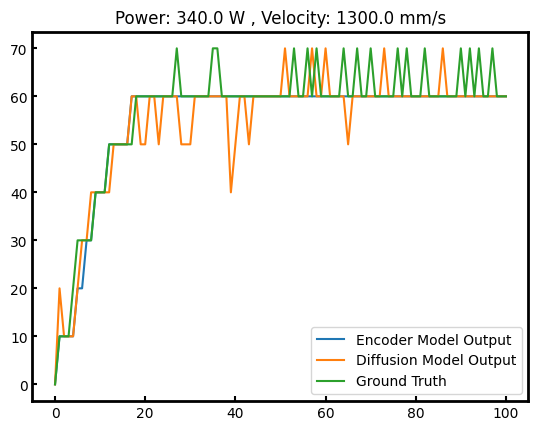

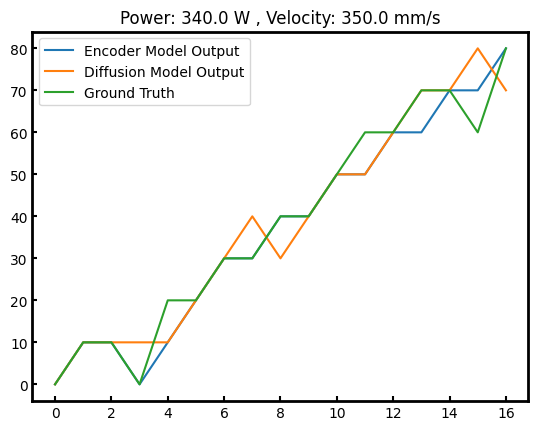

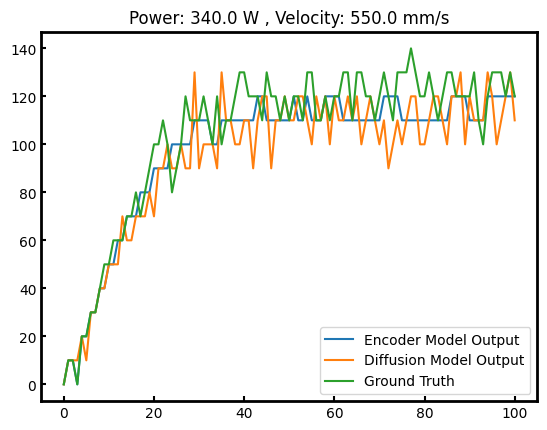

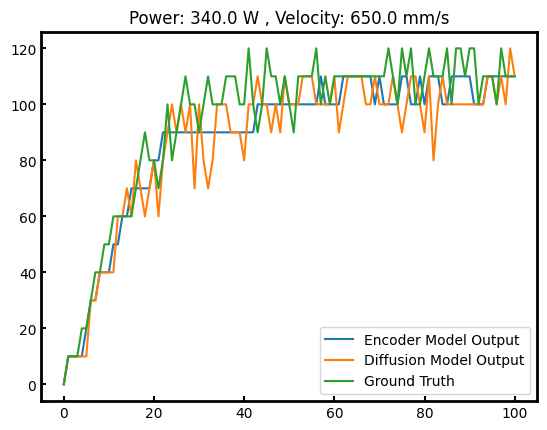

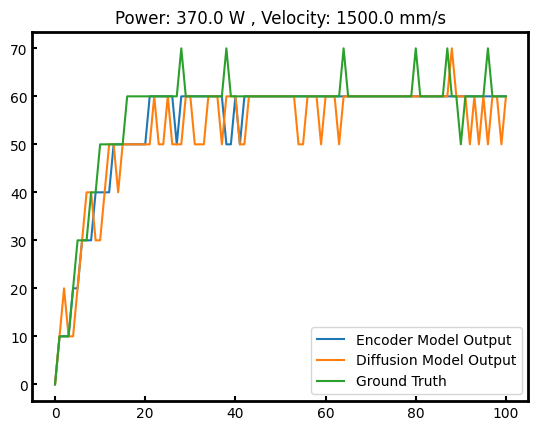

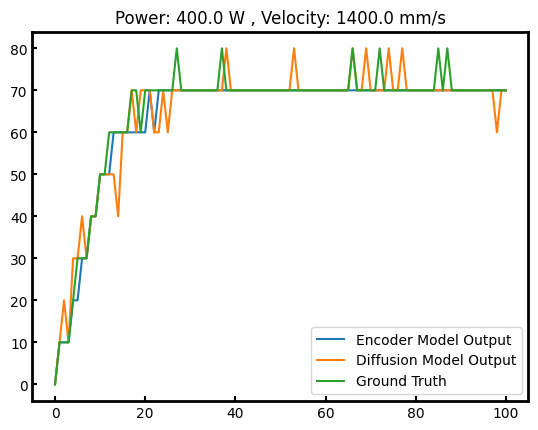

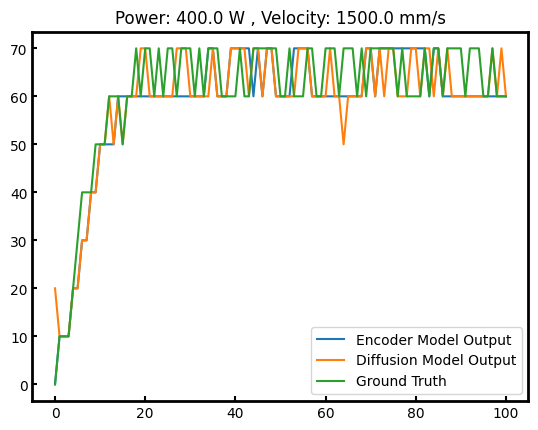

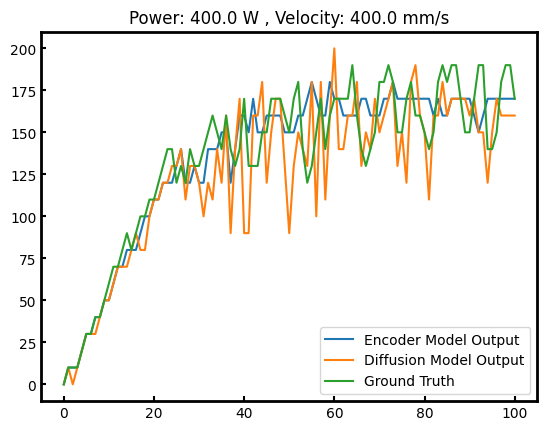

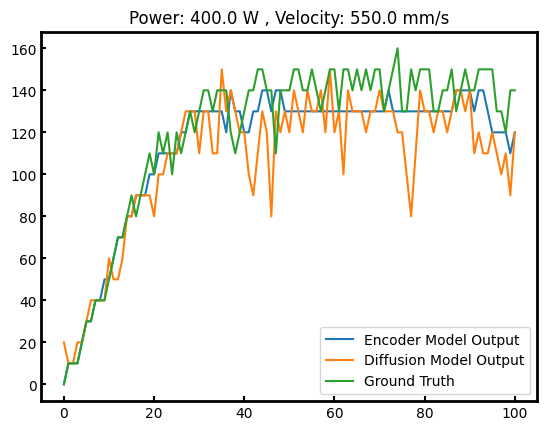

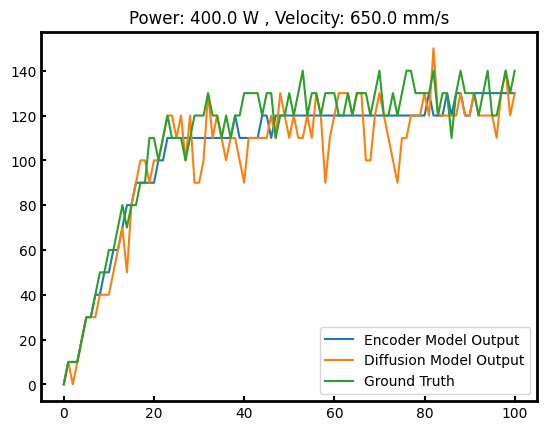

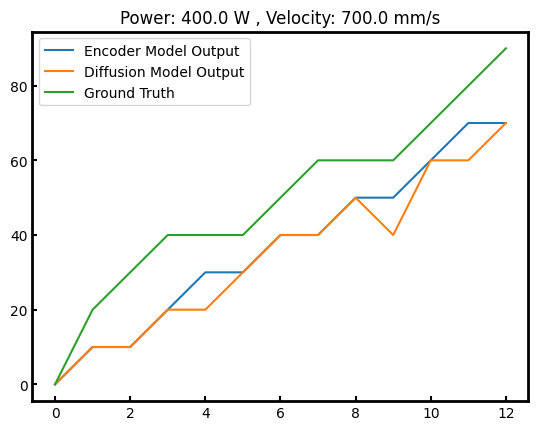

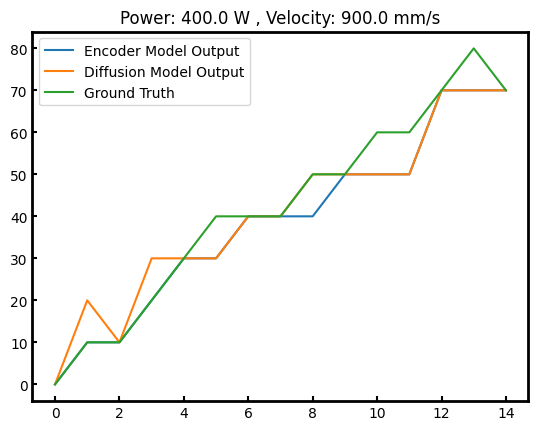

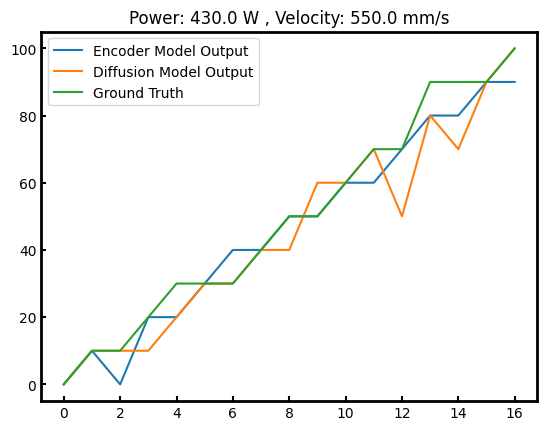

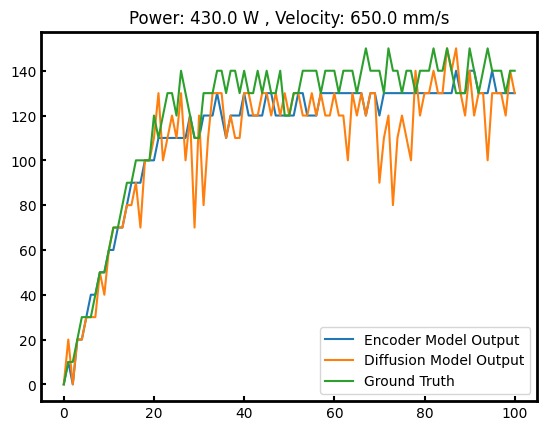

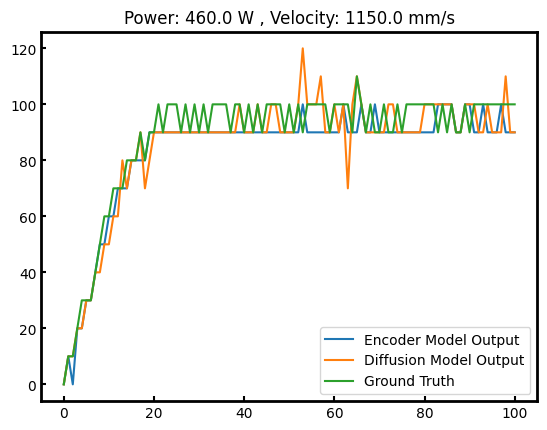

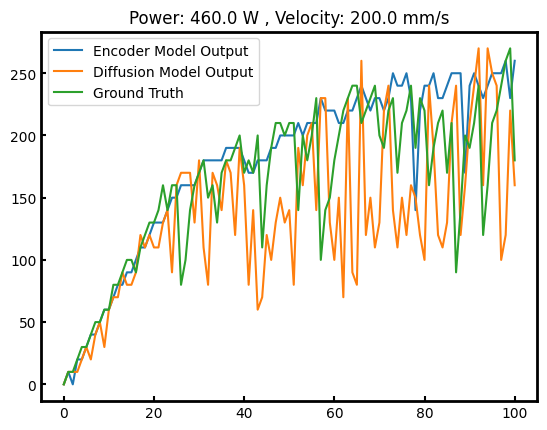

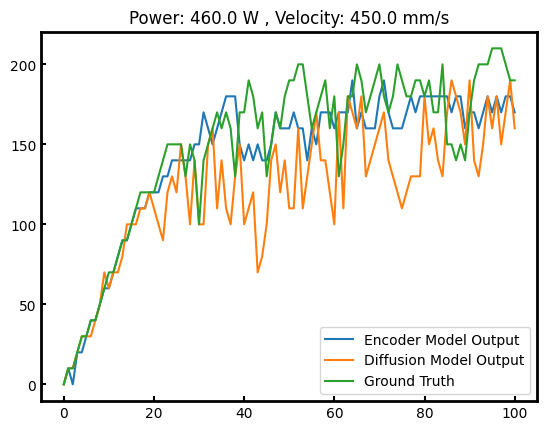

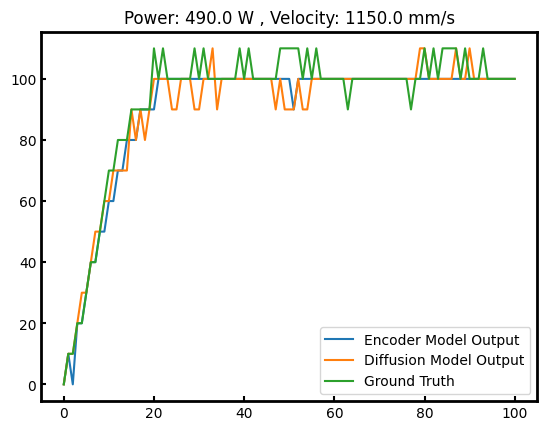

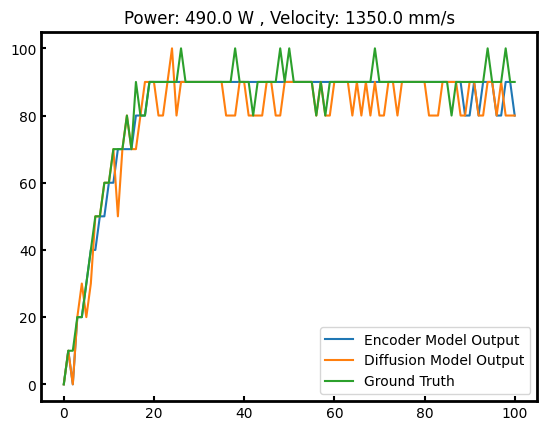

<Figure size 640x480 with 0 Axes>

In [ ]:
depth_folder = os.path.join(analysis_folder, 'depth_over_time')
from peakdetect import peakdetect
from scipy.signal import find_peaks
os.makedirs(depth_folder, exist_ok = True)
for key in enc_results.keys():
    if 'key' in key:
        plt.plot(enc_results[key], label = 'Encoder Model Output')
        plt.plot(diff_results[key], label = 'Diffusion Model Output')
        plt.plot(gt_results[key], label = 'Ground Truth')
        power_text = key.split('power')[1].split('vel')[0]
        vel_text = key.split('vel')[1]


        
        peaks = find_peaks(gt_results[key])
        # plt.scatter(peaks[0], np.array(diff_results[key])[peaks[0]])
        # peaks = peakdetect(diff_results[key]) 
        # higherPeaks = np.array(peaks[0])
        # lowerPeaks = np.array(peaks[1])
        # plt.step(np.arange(99), diff_results[key])
        # plt.plot(higherPeaks[:,0], higherPeaks[:,1], 'ro', markersize = 4)
        # plt.plot(lowerPeaks[:,0], lowerPeaks[:,1], 'ko' , markersize = 4)


        plt.title(f'Power: {power_text} W , Velocity: {vel_text} mm/s')
        frame_tick()
        plt.legend()
        plt.show()
        # plt.savefig(os.path.join(depth_folder, f'{key}.png'))
        plt.clf()
        # plt.show()

In [ ]:
def get_frequency(seq):
    peaks = peakdetect(seq, lookahead=1) 
    higherPeaks = np.array(peaks[0])
    lowerPeaks = np.array(peaks[1])
    print(higherPeaks)
    if len(higherPeaks) == 0:
        return 0, 0
    mask1 = higherPeaks[:,0] > 30 
    mask2 =  higherPeaks[:,0] < 80 
    indices = np.logical_and(mask1, mask2)
    frequency = 1/np.mean(np.diff(higherPeaks[indices][:,0])*5e-6)
    amp = np.std(10e-6*np.diff(higherPeaks[indices][:,0]))
    print(frequency, amp)
    return frequency, amp
def get_frequency_old(seq):
    peaks = find_peaks(seq)
    if len(peaks[0]) == 0:
        return 0, 0
    mask1 = peaks[0] > 30 
    mask2 =  peaks[0] < 80 
    indices = np.logical_and(mask1, mask2)
    frequency = 1/np.mean(np.diff(peaks[0][indices])*5e-6)
    amp = np.std(10e-6*np.diff(peaks[0][indices]))
    print(frequency, amp)
    return frequency, amp

key_power100.0vel1000.0
nan nan
38095.23809523809 2.3848480035423645e-05
nan nan
depth_power100.0vel1000.0
key_power100.0vel300.0
33333.333333333336 1.4142135623730953e-05
41860.46511627906 2.0964402515681343e-05
nan nan
depth_power100.0vel300.0
key_power100.0vel750.0
nan nan
49999.999999999985 2.2110831935702667e-05
nan nan
depth_power100.0vel750.0
key_power130.0vel1300.0
nan nan
39130.43478260869 2.6010444246043618e-05
nan nan
depth_power130.0vel1300.0
key_power130.0vel1500.0
nan nan
51282.051282051274 1.57797338380595e-05
nan nan
depth_power130.0vel1500.0
key_power130.0vel200.0
32432.43243243243 2.793842435706702e-05
41666.666666666664 2.785677655436824e-05
21052.631578947367 4.9999999999999996e-06
depth_power130.0vel200.0
key_power130.0vel450.0
24390.24390243902 3.54400902933387e-05
55813.95348837209 1.3819269959814168e-05
nan nan
depth_power130.0vel450.0
key_power130.0vel650.0
46666.66666666666 4.517539514526256e-06
38888.88888888889 1.9587584572574413e-05
nan nan
depth_power130.0

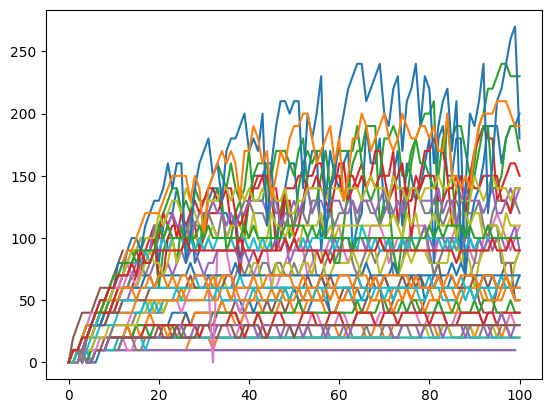

In [ ]:
powers = []
vels = []
gtfreqs = []
diffreqs = []
encfreqs = []
encamps= []
gtamps = []
diffamps = []
for key in gt_results.keys():
    print(key)
    if 'key' in key:
        power = float(key.split('power')[1].split('vel')[0])
        vel = float(key.split('vel')[1])
        powers.append(power)
        vels.append(vel)
        plt.plot(gt_results[key])
        gtfreq, amp = get_frequency_old(gt_results[key])
        gtfreqs.append(gtfreq)
        gtamps.append(amp)
        diffreq, amp = get_frequency_old(diff_results[key])
        diffreqs.append(diffreq)
        diffamps.append(amp)
        encfreq, amp = get_frequency_old(enc_results[key])
        encfreqs.append(encfreq)
        encamps.append(amp)

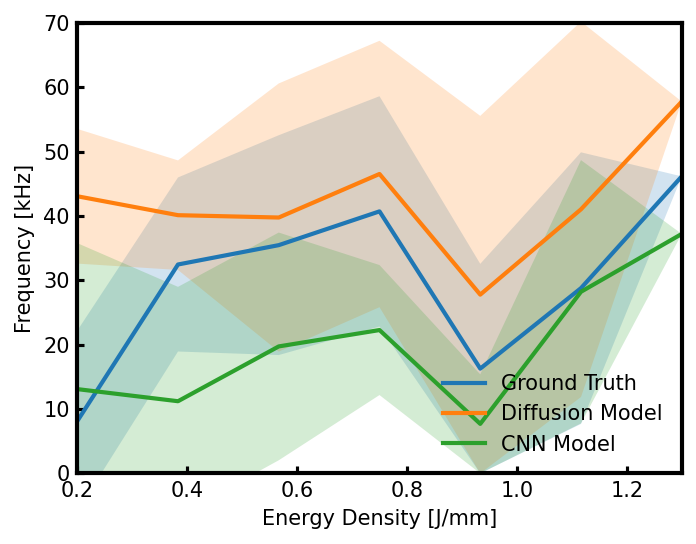

In [ ]:
nanreplace_encfreqs = np.copy(encfreqs)
nanreplace_encfreqs[np.isnan(encfreqs)] = 0

nanreplace_diffreqs = np.copy(diffreqs)
nanreplace_diffreqs[np.isnan(diffreqs)] = 0


nanreplace_gtfreqs = np.copy(gtfreqs)
nanreplace_gtfreqs[np.isnan(gtfreqs)] = 0
# bins = np.linspace(0.2,0.8, 15 )
bins = np.linspace(0.2,1.3, 7 )
gtmeans = []
gtstds = []
diffmeans = []
diffstds = []
encmeans = []
encstds = []
digitized_density = np.digitize(np.array(powers)/np.array(vels), bins)
for idx, bin in enumerate(bins):
    gtarray = np.array(nanreplace_gtfreqs)[digitized_density == idx]/1000
    diffarray = np.array(nanreplace_diffreqs)[digitized_density == idx]/1000
    encarray = np.array(nanreplace_encfreqs)[digitized_density == idx]/1000

    gtmean = np.mean(gtarray)
    encmean = np.mean(encarray)
    # diffmean = np.mean(diffarray)

    gtstd = np.std(gtarray)
    encstd = np.std(encarray)
    # diffstd = np.std(diffarray)

    gtstd = np.std(gtarray)
    gtmean = np.mean(gtarray)
    encstd = np.std(encarray)
    encmean = np.mean(encarray)
    diffstd = np.std(diffarray)
    diffmean = np.mean(diffarray)

    gtmeans.append(gtmean)
    gtstds.append(gtstd)


    encmeans.append(encmean)
    encstds.append(encstd)
    diffmeans.append(diffmean)
    diffstds.append(diffstd)
# np.digitize(np.array(powers)/np.array(vels), bins
# )
encmeans = np.array(encmeans)
encstds = np.array(encstds)
diffmeans = np.array(diffmeans)
diffstds = np.array(diffstds)
gtmeans = np.array(gtmeans)
gtstds = np.array(gtstds)
# plt.plot(gtmeans+gtstds)
# plt.plot(gtmeans-gtstds)

# plt.plot(diffmeans)
import scipy
from scipy import interpolate
interpstds = interpolate.interp1d(np.arange(len(bins)), gtstds)
interpmeans = interpolate.interp1d(np.arange(len(bins)), gtmeans)
plt.figure(dpi= 150, figsize = np.array([4,3])*1.3)
# interp_length = 10
# interp_array = np.linspace(0, len(bins) -1 , interp_length)
# plt.fill_between(interp_array, interpmeans(interp_array) - interpstds(interp_array), interpmeans(interp_array) + interpstds(interp_array), alpha = 0.5)
# plt.fill_between(interp_array, interpmeans(interp_array) - interpstds(interp_array), interpmeans(interp_array) + interpstds(interp_array), alpha = 0.5)

plt.plot(bins,gtmeans, label = 'Ground Truth', linewidth = 2.0)
plt.plot(bins,diffmeans, label = 'Diffusion Model', linewidth = 2.0)
plt.plot(bins,encmeans, label = 'CNN Model', linewidth = 2.0)


plt.fill_between(bins,gtmeans- gtstds, gtmeans+gtstds, alpha = 0.2)
plt.fill_between(bins,  diffmeans- diffstds, diffmeans+diffstds, alpha = 0.2)
plt.fill_between(bins, encmeans- encstds, encmeans+encstds, alpha = 0.2)
# plt.xlim()
frame_tick()
plt.legend(frameon = False, loc= 'lower right')
plt.xlim([0.2, 1.3])
plt.ylim([0, 70])
plt.ylabel('Frequency [kHz]')
plt.xlabel('Energy Density [J/mm]')
plt.show()

In [ ]:
diffamps

[2.3848480035423645e-05,
 2.0964402515681343e-05,
 2.2110831935702667e-05,
 2.6010444246043618e-05,
 1.57797338380595e-05,
 2.785677655436824e-05,
 1.3819269959814168e-05,
 1.9587584572574413e-05,
 3.7361990944634357e-05,
 3.498571136907181e-05,
 1.4356965173029845e-05,
 2.415933503612538e-05,
 3.177855476905576e-05,
 2.256102834535696e-05,
 1.118033988749895e-05,
 1.192261549873091e-05,
 8e-06,
 2.004127971368055e-05,
 1.3743685418725536e-05,
 2.0928844424038797e-05,
 1.2639751327042297e-05,
 3.072458299147443e-05,
 7.483314773547884e-06,
 1.0088366960464615e-05,
 1.3234346564680966e-05,
 3.4292856398964496e-05,
 nan,
 9.394961741404221e-06,
 1.5634719199411434e-05,
 2.5e-05,
 5.1536394906900504e-05,
 2.0245407953654e-05,
 1.1234866364235145e-05,
 2.299987136573239e-05,
 2.135415650406262e-05,
 nan,
 nan,
 nan,
 7.71722460186015e-06,
 1.7633419974582358e-05,
 6.614378277661478e-06,
 1.1570838237598051e-05,
 9.069178573608526e-05,
 1.617802197617893e-05]

/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3419: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/numpy/core/_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/numpy/core/_methods.py:221: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/numpy/core/_methods.py:253: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


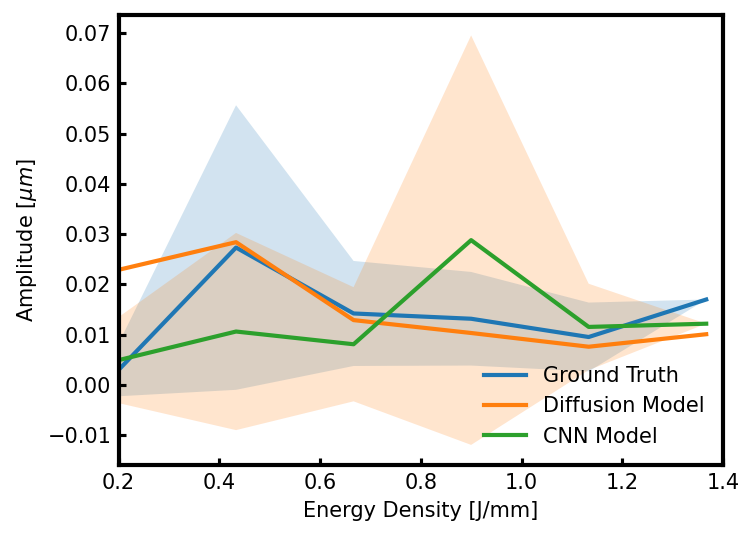

In [ ]:
nanreplace_encfreqs = np.copy(encamps)*1e6
nanreplace_encfreqs[np.isnan(encamps)] = 0

nanreplace_diffreqs = np.copy(diffamps)*1e6
nanreplace_diffreqs[np.isnan(diffamps)] = 0


nanreplace_gtfreqs = np.copy(gtamps)*1e6
nanreplace_gtfreqs[np.isnan(gtamps)] = 0

bins = np.linspace(0.2,1.6, 7 )
gtmeans = []
gtstds = []
diffmeans = []
diffstds = []
encmeans = []
encstds = []
digitized_density = np.digitize(np.array(powers)/np.array(vels), bins)
for idx, bin in enumerate(bins):
    gtarray = np.array(nanreplace_gtfreqs)[digitized_density == idx]/1000
    diffarray = np.array(nanreplace_diffreqs)[digitized_density == idx]/1000
    encarray = np.array(nanreplace_encfreqs)[digitized_density == idx]/1000

    gtmean = np.mean(gtarray)
    encmean = np.mean(encarray)
    diffmean = np.mean(diffarray)

    gtstd = np.std(gtarray)
    encstd = np.std(encarray)
    diffstd = np.std(diffarray)

    gtstd = np.std(gtarray)
    gtmean = np.mean(gtarray)
    encstd = np.std(encarray)
    encmean = np.mean(encarray)
    diffstd = np.std(diffarray)
    diffmean = np.mean(diffarray)

    gtmeans.append(gtmean)
    gtstds.append(gtstd)


    encmeans.append(encmean)
    encstds.append(encstd)
    diffmeans.append(diffmean)
    diffstds.append(diffstd)
# np.digitize(np.array(powers)/np.array(vels), bins
# )
encmeans = np.array(encmeans)
encstds = np.array(encstds)
diffmeans = np.array(diffmeans)
diffstds = np.array(diffstds)
gtmeans = np.array(gtmeans)
gtstds = np.array(gtstds)
# plt.plot(gtmeans+gtstds)
# plt.plot(gtmeans-gtstds)

# plt.plot(diffmeans)
import scipy
from scipy import interpolate
interpstds = interpolate.interp1d(np.arange(len(bins)), gtstds)
interpmeans = interpolate.interp1d(np.arange(len(bins)), gtmeans)
plt.figure(dpi= 150, figsize = np.array([4,3])*1.3)
# interp_length = 10
# interp_array = np.linspace(0, len(bins) -1 , interp_length)
# plt.fill_between(interp_array, interpmeans(interp_array) - interpstds(interp_array), interpmeans(interp_array) + interpstds(interp_array), alpha = 0.5)
# plt.fill_between(interp_array, interpmeans(interp_array) - interpstds(interp_array), interpmeans(interp_array) + interpstds(interp_array), alpha = 0.5)

plt.plot(bins,gtmeans, label = 'Ground Truth', linewidth = 2.0)
plt.plot(bins,diffmeans, label = 'Diffusion Model', linewidth = 2.0)
plt.plot(bins,encmeans, label = 'CNN Model', linewidth = 2.0)


plt.fill_between(bins,gtmeans- gtstds, gtmeans+gtstds, alpha = 0.2)
# plt.fill_between(bins,  diffmeans- diffstds, diffmeans+diffstds, alpha = 0.2)
plt.fill_between(bins, encmeans- encstds, encmeans+encstds, alpha = 0.2)
# plt.xlim()
frame_tick()
plt.legend(frameon = False, loc= 'lower right')
plt.xlim([0.2, 1.4])
# plt.ylim([0, 70])
plt.ylabel(r'Amplitude [$\mu m$]')
plt.xlabel('Energy Density [J/mm]')
plt.show()

In [ ]:
for split, dataloader in zip([ 'Test'], [ test_dataloader]):
    for batch_idx, (res, hr, lr, upscaled_lr, info) in enumerate(dataloader):  
        info = info[0]
        # print(info[2])
        input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, dataloader.dataset)
        analysis_folder = f'analyzed_figures_paper_3_19/{timesteps}'
        os.makedirs(analysis_folder, exist_ok=True)
        # plt.imshow(input[0,1,:, :].T, origin = 'lower', cmap  = 'jet', vmin = 293, vmax = 5000)
        # plt.show()
        # plt.imshow(lr_enc_result[0,1,:, :].T, origin = 'lower', cmap  = 'jet', vmin = 293, vmax = 5000)
        # plt.show()

        # plt.imshow(target[0,1,:, :].T, origin = 'lower', cmap  = 'jet', vmin = 293, vmax = 5000)
        # plt.show()
        folder = os.path.join(analysis_folder, 'time_stepped_encoder/'  + 'power' + str(info[0].item()) + 'vel' + str(info[1].item()))
        mpfname = os.path.join(folder,'time_stepped_contours/',   'batch_{:06}_'.format(batch_idx)+ 'time' + '{:07}'.format(int(np.round(info[2].item()*1e6))) + f'encoder_contour_line_{split}_plot_mp.png')
        kpfname = os.path.join(folder, 'time_stepped_contours/', 'batch_{:06}_'.format(batch_idx)+ 'time' + '{:07}'.format(int(np.round(info[2].item()*1e6))) + f'encoder_contour_line_{split}_plot_kp.png')
        os.makedirs(os.path.join(folder, 'time_stepped_contours/'), exist_ok=True)

        # kp_fname = os.path.join(analysis_folder, f'encoder_contour_line_{split}_plot_kp.png')
        # mpfname = os.path.join(analysis_folder, f'encoder_contour_line_{split}_plot_mp.png')
        plot_srdiff_contours(input, lr_enc_result, target, split =split,  modeltype = "Encoder", save = True, kpfname = kpfname, mpfname = mpfname)
        # if batch_idx > 5:
            # break
#, result_diffusion[0], target[0][:, :], field_idx = field_idx, field_key = field_key, timestep = timestep, split = 'Validation', modeltype =modeltype, timesteps = timesteps//skips, title =  title)

IndexError: index 1 is out of bounds for axis 0 with size 1

In [ ]:
os.path.join(encoder_results_dir, 'saved_figures/{}/'.format(field_key)  + 'power' + str(info[0].item()) + 'vel' + str(info[1].item())) 
folder

'RRDNsaved_figures/liqlabel/power100.0vel1000.0'

In [ ]:
int(np.round(info[2].item()*1e6))

5000

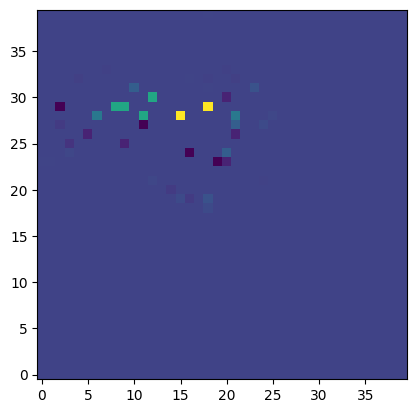

In [ ]:
# .max()
plt.imshow(train_dataset.unscale_data(hr, input_type='hr')[0][0].T, origin = 'lower')

In [ ]:
# hr.shape
# get_profile(result_diffusion[i], mesh = 10)
result_diffusion[0].shape

NameError: name 'result_diffusion' is not defined

In [ ]:

def SSIM(op, t, batch_size):
    ssim = 0 
    # print(op.shape, t.shape)
    
    for i in range(op.shape[0]):

        # print(out[0,0].size())
        # print(op.shape, t.shape)
        if isinstance(op, torch.Tensor):
            score = ssim_id(op[i][0].detach().cpu().numpy(), t[i][0].detach().cpu().numpy())#, full=True)
        else:
            score = ssim_id(op[i][0], t[i][0].detach().cpu().numpy())#, full=True)
        ssim+=score/batch_size
    
        #print("SSIM: {}".format(score))
    return ssim
model = load_diffusion('/home/oogoke/DiffusionSR/runs/direct/diffusionimplicit/2023_01_30_03_21_51/standardize/n_steps_1', dataset = train_dataset)


# max_depth_diff = []
max_depth_gt = []
max_depth_input = []
# kp_depth_enc = []
# kp_depth_diff = []
# kp_depth_mbn = []
kp_depth_gt = []
kp_depth_input = []
kp_depth_diffs = []
max_depth_diffs = []
psnrs_lr = []
psnrs_diff= []

ssims_diff = []
ssims_lr = []
factor = 2
mesh_hr = 10
mesh_lr = 20
l1_lr = []
l1_diff = []

sample_times = []
steps_list= []
psnr_mean_lr = []
ssim_mean_lr = []
l1_mean_lr = []
ssim_mean_diff = []
psnr_mean_diff = []
l1_mean_diff = []
l1loss = nn.L1Loss()
# sample_diff_steps = [50, 100,200, 500, 1000, 1500, 2000]
# sim = simlinear1500
timesteps=1000
# model = load_diffusion(sim.folder)
for skips in [  10, 15, 20, 50]:
    diff_steps = 1000
# for diff_steps in sample_diff_steps:
    kp_depth_diff = []
    max_depth_diff = []
    max_depth_input= []
    kp_depth_input = []
    max_depth_gt  = []
    kp_depth_gt = []
    psnr_batches_lr = []
    psnr_batches_diff = []
    l1_batches_diff = []
    l1_batches_lr = []
    ssim_batches_lr = []
    ssim_batches_diff = []
    print(skips)
    for batch_idx, (res, hr, lr, upscaled_lr, info) in tqdm(enumerate(test_dataloader), total =len(test_dataloader)):  
        oldtime = time.time()
        # print(res.shape, 'res shape')
        input_fields, result_diffusion_fields, target_fields, _, _ = predict_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,train_dataset,seq= None, timesteps = timesteps,skip = skips, schedule = 'quadratic')
        input = input_fields[:,  1:2]
        result_diffusion = result_diffusion_fields[:,1:2]
        target = target_fields[:, 1:2]
        # print(result_diffusion.shape)
        upscale = dev_dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr')
        # lrpsnr = PSNR(upscale, target, target.shape[0]).item()

        # diffpsnr = PSNR(result_diffusion, target, target.shape[0]).item()
        # print(lrpsnr, diffpsnr)
        # psnr_batches_diff.append(diffpsnr)
        # psnr_batches_lr.append((lrpsnr))
        # lrssim = SSIM(upscale, target.view(upscale.shape), target.shape[0])
        # diffssim = SSIM(result_diffusion, target.view(upscale.shape), target.shape[0])
        lrl1 =np.mean(np.abs(upscale-target_fields ), axis = (0,2,3))
        # print('shape printing here')
        # print(type(result_diffusion), type(target))
        # print(result_diffusion.shape, target.shape)
        diffl1 = np.mean(np.abs(result_diffusion_fields-target_fields ), axis = (0,2,3))
        # print('LR SSIM: ',  SSIM(upscale, target.view(upscale.shape), target.shape[0]))
        # print(result_diffusion.shape, target.shape, 'shapes result diffusion target')
        # print('Diffusion SSIM: ',  SSIM(result_diffusion, target.view(upscale.shape), target.shape[0]))
        # ssim_batches_lr.append(lrssim)
        # ssim_batches_diff.append(diffssim)
        l1_batches_lr.append(lrl1)
        l1_batches_diff.append(diffl1)
        for i, rd in enumerate(result_diffusion):
            elapsed = time.time() - oldtime
            if batch_idx == 0:
                sample_times.append(elapsed)
                steps_list.append(timesteps//skips)
            profile_diff, kp_diff = get_profile(result_diffusion[i], mesh = 10, max_idx = 30)
            # print(result_diffusion[i].shape)
            # print(target.shape)
            profile_gt, kp_gt = get_profile(target[i], mesh = 10, max_idx = 30)
            profile_input, kp_input = get_profile(input[i], mesh = 20,max_idx = 15)
            # plt.imshow(target[i].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
            # plt.show()
            # plt.imshow(result_diffusion[i].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
            # plt.show()
            # plt.plot(profile_diff)
            # plt.plot(profile_gt)
            # # plt.plot(profile_input)
            # plt.show()
            # break

            max_depth_gt.append(mesh_hr*(20*factor-5*factor - np.min(profile_gt)))
            max_depth_diff.append(mesh_hr*(20*factor-5*factor  -np.min(profile_diff)))
            max_depth_input.append(mesh_lr*(20-5- np.min(profile_input)))
            kp_depth_gt.append(mesh_hr*(20*factor-5*factor-np.min(kp_gt)))
            kp_depth_input.append(mesh_lr*(20-5-np.min(kp_input)))
            kp_depth_diff.append(mesh_hr*(20*factor-5*factor-np.min(kp_diff)))
            # plt.imshow(result_diffusion[i][0].T, origin = 'lower', vmin  = 293, vmax = 5000, cmap ='jet')
            # plt.plot(np.arange(40),profile_gt, label = 'gt')
            # # plt.plot(np.arange(20)*2, profile_input), label = 'lr')
            # plt.plot(np.arange(40),  profile_diff, label = 'sr')
            # plt.legend()
            # plt.show()
            # plt.imshow(target[i][0].T, origin = 'lower', vmin  = 293, vmax = 5000, cmap ='jet')
            # plt.plot(np.arange(40),kp_gt, label = 'gtkp ')
            # # plt.plot(np.arange(20)*2, profile_input), label = 'lr')
            # plt.plot(np.arange(40),  kp_diff, label = 'kp sr')
            # plt.legend()
            # plt.show()
            # plt.plot(np.arange(40),-mesh_hr*(20*factor - profile_gt), label = 'gt')
            # plt.plot(np.arange(20)*2, -mesh_lr*(20 - profile_input), label = 'lr')
            # plt.plot(np.arange(40), -mesh_hr*(20*factor - profile_diff), label = 'sr')
            # plt.legend()
            # plt.show()
            # plt.imshow(result_diffusion[i, 0].T, vmin = 293, vmax = 5000, origin = 'lower', cmap = 'jet')
            # plt.colorbar()
            # plt.title('diff')
            # plt.show()
            # plt.imshow(target[i, 0].T, vmin = 293, vmax = 5000, origin = 'lower', cmap = 'jet')
            # plt.colorbar()
            # plt.title('targ')
            # plt.show()
            # plt.imshow(input[i, 0].T, vmin = 293, vmax = 5000, origin = 'lower', cmap = 'jet')
            # plt.colorbar()
            # plt.title('inp')
            # plt.show()


        # plt.plot(profile_diff)
        # plt.show()
        # if batch_idx > 9:
        #     break
    kp_depth_diffs.append(kp_depth_diff)
    max_depth_diffs.append(max_depth_diff)
    ssims_diff.append(ssim_batches_diff)
    # ssims_lr.append(ssim_batches_lr)
    l1_diff.append(l1_batches_diff)
    l1_lr.append(l1_batches_lr)
    # psnrs_lr.append(psnr_batches_lr)
    # psnrs_diff.append(psnr_1, 2, 3, 5, 10, 15, 20,an(psnr_batches_lr))
    psnr_mean_diff.append(np.mean(psnr_batches_diff, axis = 0))
    # ssim_mean_diff.append(np.mean(ssim_batches_diff))
    # ssim_mean_lr.append(np.mean(ssim_batches_lr))
    l1_mean_lr.append(np.mean(l1_batches_lr, axis = 0))
    l1_mean_diff.append(np.mean(l1_batches_diff, axis = 0))
    
    print(ssim_mean_lr)


10


100%|██████████| 1402/1402 [22:43<00:00,  1.03it/s]
/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3419: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/numpy/core/_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


[]
15


100%|██████████| 1402/1402 [15:24<00:00,  1.52it/s]


[]
20


100%|██████████| 1402/1402 [11:37<00:00,  2.01it/s]


[]
50


100%|██████████| 1402/1402 [04:52<00:00,  4.79it/s]

[]


In [ ]:
# np.array(l1_batches_diff)
# 1402/4
# np.mean(l1_batches_diff, axis = 0).shape
np.array(l1_lr).shape

(4, 1402, 6)

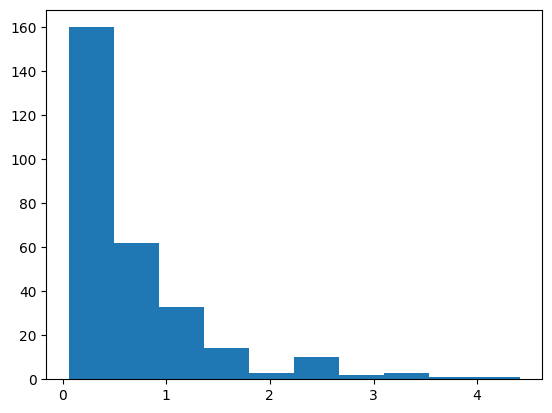

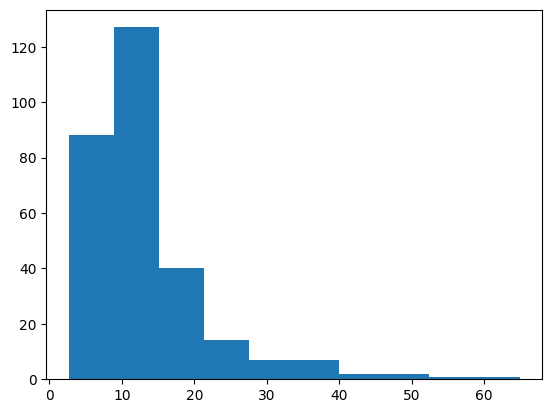

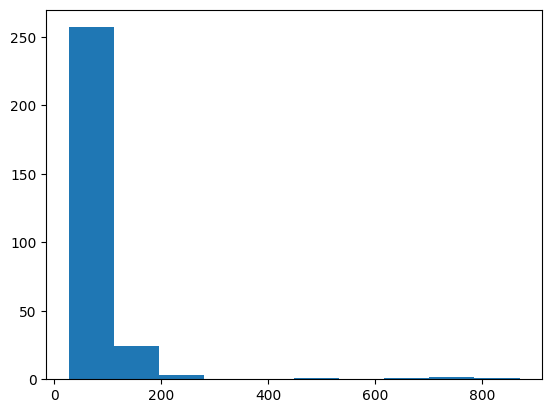

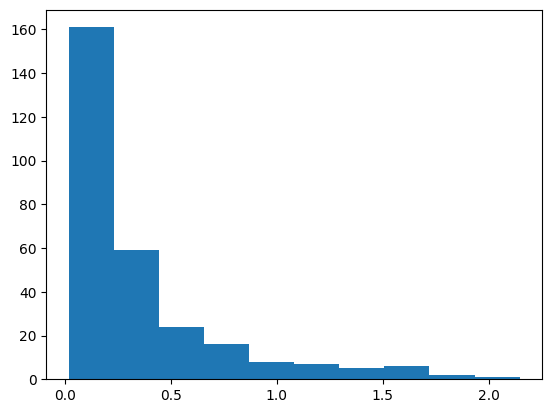

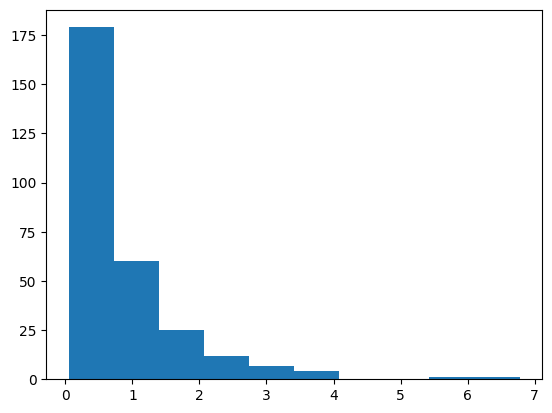

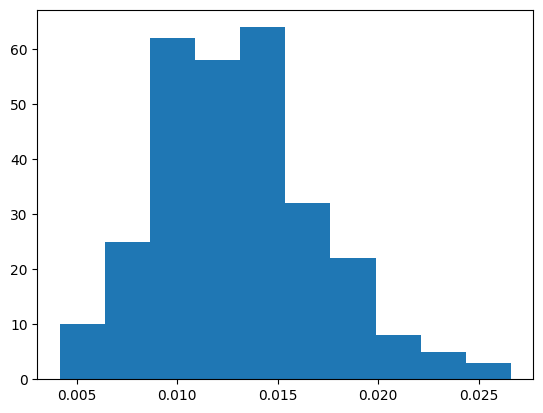

In [ ]:
# np.mean(l1_batches_diff, axis = 0
for i in range(np.array(l1_batches_diff).shape[1]):
    plt.hist(np.array(l1_batches_diff)[:,i])
    plt.show()

In [ ]:
np.mean(np.abs(result_diffusion_fields-target_fields ), axis = (0,2,3))
# target_fields.shape
# torch.nn.L1Loss()(torch.tensor(result_diffusion_fields), torch.tensor(target_fields))

array([1.85842608e-01, 1.18792901e+01, 4.89358881e+01, 9.62968144e-02,
       2.96927928e-01, 1.40944715e-02])

In [ ]:
l1_batches_diff = []
for batch_idx, (res, hr, lr, upscaled_lr, info) in tqdm(enumerate(test_dataloader), total =len(test_dataloader)):  
    for plot_field_idx in range(1,5):
        oldtime = time.time()
        
        input_fields, result_diffusion_fields, target_fields, _, _ = predict_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,train_dataset,seq= None, timesteps = timesteps,skip = skips, schedule = 'quadratic')
        input = input_fields[:,  plot_field_idx:plot_field_idx+1]
        result_diffusion = result_diffusion_fields[:,plot_field_idx:plot_field_idx+1]
        target = target_fields[:, plot_field_idx:plot_field_idx+1]

        upscale = dev_dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr')
        # lrl1 = l1loss(upscale, target)
        diffl1 = l1loss(torch.tensor(result_diffusion), torch.tensor(target)).item()
        print(diffl1)
        l1_batches_diff.append(diffl1)

  0%|          | 0/1402 [00:00<?, ?it/s]

6.026911471132675
57.776011057028796
0.11407231143453472


  0%|          | 1/1402 [00:08<3:12:12,  8.23s/it]

0.5824569116189479
10.129721838588765
39.54430184136923
0.15909988396566246


  0%|          | 2/1402 [00:16<3:13:24,  8.29s/it]

...

0.3211127584107815
10.045891787483363
54.26454934309611
0.2542191602574887


  0%|          | 6/1402 [00:48<3:06:09,  8.00s/it]

0.26185720988010003
14.132094917643292
48.93588813078508


  0%|          | 6/1402 [00:53<3:27:28,  8.92s/it]


KeyboardInterrupt: 

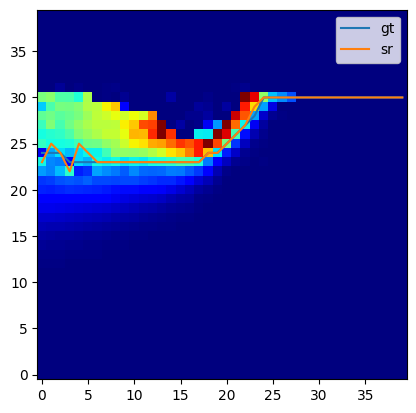

In [ ]:
# plt.plot(kp_gt)
# plt.plot(kp_diff)
plt.imshow(result_diffusion[i][0].T, origin = 'lower', vmin  = 293, vmax = 5000, cmap ='jet')
plt.plot(np.arange(40),profile_gt, label = 'gt')
# plt.plot(np.arange(20)*2, profile_input), label = 'lr')
plt.plot(np.arange(40),  profile_diff, label = 'sr')
plt.legend()
plt.show()

In [ ]:
# timesteps = 1500
for 
for timesteps in [200]:
    for skips in [1]:#, 2, 3, 5, 10, 15, 20, 50]:
        oldtime = time.time()
        input, result_diffusion, target, xs, b = predict_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,train_dataset,seq= None, timesteps = timesteps,skip = skips, schedule = 'linear')
        time_elapsed = time.time()-oldtime
        print(input.shape, result_diffusion.shape, target.shape)
        plot_images(input[0], result_diffusion[0], target[0][0], split = 'Validation', modeltype = "Diffusion", timesteps = timesteps//skips)
        print(time_elapsed, "elapsed time")

In [ ]:
# plt.imshow(xs[-1][0][0].detach().cpu().numpy())
# plt.plot(b)
len(dataloader.dataset.hr_paths)

In [ ]:
plt.imshow(result_diffusion[0].T, cmap ='jet', origin = 'lower', vmin = -100, vmax= 0)
plt.colorbar()
plt.show()
plt.imshow(result_diffusion[0].T, cmap ='jet', origin = 'lower', vmax= 293)
plt.colorbar()
plt.show()
plt.imshow(result_diffusion[0].T, cmap ='jet', origin = 'lower', vmin = 293, vmax= 1900)
plt.colorbar()
plt.show()
plt.imshow(result_diffusion[0].T, cmap ='jet', origin = 'lower', vmin= 293, vmax = 5000)
plt.colorbar()
plt.show()
plt.imshow(dev_dataloader.dataset.unscale_data(res[0,0].T.cpu().numpy(), input_type = 'residual'), cmap = 'jet', origin = 'lower')
plt.colorbar()

### Calculate melt pool and keyhole dimensions

In [ ]:
def get_inst_profile(image, mesh = 5):
    image = image[0].T
    print(image.shape)
    binarized = image > 1900
    profile = []
    keyholeprofile = []
    for i in range(binarized.shape[1]):
        coords = np.where(binarized[:,i])[0]
        if len(coords) > 0:
            profile.append(np.min(coords))
            keyholeprofile.append(np.max(coords))
        else:
            profile.append(binarized.shape[1])
            keyholeprofile.append(binarized.shape[1])
    profile = np.array(profile)
    keyholeprofile = np.array(keyholeprofile)
    return(profile, keyholeprofile)

In [44]:
# max_depth_diff = []
mesh_hr = 5
factor = 2
mesh_lr = 20
max_depth_gt = []
max_depth_input = []
# kp_depth_enc = []
# kp_depth_diff = []
# kp_depth_mbn = []
kp_depth_gt = []
kp_depth_input = []
kp_depth_diffs = []
max_depth_diffs = []
# max_depth_encs = []
sample_times = []
steps_list= []
timesteps = 1000
for skips in [50]:
    kp_depth_diff = []
    max_depth_diff = []
    max_depth_input= []
    kp_depth_input = []
    max_depth_gt  = []
    kp_depth_gt = []
    
    for batch_idx, (res, hr, lr, upscaled_lr, info) in tqdm(enumerate(dev_dataloader), total = len(dev_dataloader)):  
        oldtime = time.time()
        input, result_diffusion, target, _, _ = predict_modified_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,encoding = True,dataset =  train_dataset,seq= None, timesteps = timesteps,skip = skip, schedule = 'linear')
        # input, result_diffusion, target, _, _ = predict_modified_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,dev_dataset,seq= None, timesteps = timesteps,skip = skips, schedule = 'linear')
        # print(result_diffusion.shape)
        for i, rd in enumerate(result_diffusion):
            elapsed = time.time() - oldtime
            if batch_idx == 0:
                sample_times.append(elapsed)
                steps_list.append(timesteps//skips)
            profile_diff, kp_diff = get_profile(result_diffusion[i], mesh = 10,max_idx = 30)
            # print(target.shape)
            profile_gt, kp_gt = get_profile(target[i], mesh = 10,max_idx = 30)
            # print(profile_gt)
            profile_input, kp_input = get_profile(input[i], mesh = 20,max_idx = 15)
            # max_depth_gt.append(mesh_hr*(20*factor-5*factor - np.min(profile_gt)))
            # max_depth_diff.append(mesh_hr*(20*factor-5*factor - np.min(profile_diff)))
            # kp_depth_gt.append(mesh_hr*(20*factor-5*factor - np.min(profile_diff)))
            
            

        
            # max_depth_gt.append(5*(80-np.min(profile_gt)))
            # max_depth_diff.append(5*(80-np.min(profile_diff)))
            # max_depth_input.append(20*(20-np.min(profile_input)))
            # kp_depth_gt.append(5*(80-np.min(kp_gt)))
            # kp_depth_input.append(20*(20-np.min(kp_input)))
            # kp_depth_diff.append(5*(80-np.min(kp_diff)))



            max_depth_gt.append(mesh_hr*(20*factor-5*factor - np.min(profile_gt)))
            max_depth_diff.append(mesh_hr*(20*factor-5*factor  -np.min(profile_diff)))
            max_depth_input.append(mesh_lr*(20-5- np.min(profile_input)))
            kp_depth_gt.append(mesh_hr*(20*factor-5*factor-np.min(kp_gt)))
            kp_depth_input.append(mesh_lr*(20-5-np.min(kp_input)))
            kp_depth_diff.append(mesh_hr*(20*factor-5*factor-np.min(kp_diff)))
        # plt.plot(profile_diff)
        # plt.show()
        # if batch_idx > 2:
        #     break
    kp_depth_diffs.append(kp_depth_diff)
    max_depth_diffs.append(max_depth_diff)



100%|██████████| 2750/2750 [11:31<00:00,  3.98it/s]


In [ ]:

def SSIM(op, t, batch_size):
    ssim = 0 
    # print(op.shape, t.shape)
    
    for i in range(op.shape[0]):

        # print(out[0,0].size())
        # print(op.shape, t.shape)
        if isinstance(op, torch.Tensor):
            score = ssim_id(op[i][0].detach().cpu().numpy(), t[i][0].detach().cpu().numpy())#, full=True)
        else:
            score = ssim_id(op[i][0], t[i][0].detach().cpu().numpy())#, full=True)
        ssim+=score/batch_size
    
        #print("SSIM: {}".format(score))
    return ssim



# max_depth_diff = []
max_depth_gt = []
max_depth_input = []
# kp_depth_enc = []
# kp_depth_diff = []
# kp_depth_mbn = []
kp_depth_gt = []
kp_depth_input = []
kp_depth_diffs = []
max_depth_diffs = []
psnrs_lr = []
psnrs_diff= []

ssims_diff = []
ssims_lr = []

l1_lr = []
l1_diff = []

sample_times = []
steps_list= []
psnr_mean_lr = []
ssim_mean_lr = []
l1_mean_lr = []
ssim_mean_diff = []
psnr_mean_diff = []
l1_mean_diff = []
l1loss = nn.L1Loss()
sample_diff_steps = [50, 100,200, 500, 1000, 1500, 2000]
sim = simlinear2000
# for sim in [simlinear500, simlinear1000, simlinear1500, simlinear2000]:
for diff_steps in sample_diff_steps:
    kp_depth_diff = []
    max_depth_diff = []
    max_depth_input= []
    kp_depth_input = []
    max_depth_gt  = []
    kp_depth_gt = []
    psnr_batches_lr = []
    psnr_batches_diff = []
    l1_batches_diff = []
    l1_batches_lr = []
    ssim_batches_lr = []
    ssim_batches_diff = []

    for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dev_dataloader):  
        oldtime = time.time()
        input, result_diffusion, target = predict_modified_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, dev_dataset, timesteps =diff_steps)
        # print(result_diffusion.shape)
        upscale = dev_dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr')
        lrpsnr = PSNR(upscale, target, target.shape[0]).item()

        diffpsnr = PSNR(result_diffusion, target, target.shape[0]).item()
        # print(lrpsnr, diffpsnr)
        psnr_batches_diff.append(diffpsnr)
        psnr_batches_lr.append((lrpsnr))
        lrssim = SSIM(upscale, target.view(upscale.shape), target.shape[0])
        diffssim = SSIM(result_diffusion, target.view(upscale.shape), target.shape[0])
        lrl1 = l1loss(upscale, target)
        # print('shape printing here')
        # print(type(result_diffusion), type(target))
        # print(result_diffusion.shape, target.shape)
        diffl1 = l1loss(torch.tensor(result_diffusion), target)
        # print('LR SSIM: ',  SSIM(upscale, target.view(upscale.shape), target.shape[0]))
        # print(result_diffusion.shape, target.shape, 'shapes result diffusion target')
        # print('Diffusion SSIM: ',  SSIM(result_diffusion, target.view(upscale.shape), target.shape[0]))
        ssim_batches_lr.append(lrssim)
        ssim_batches_diff.append(diffssim)
        l1_batches_lr.append(lrl1)
        l1_batches_diff.append(diffl1)
        for i, rd in enumerate(result_diffusion):
            elapsed = time.time() - oldtime
            if batch_idx == 0:
                sample_times.append(elapsed)
                steps_list.append(diff_steps)
            profile_diff, kp_diff = get_profile(result_diffusion[i])
            # print(target.shape)
            profile_gt, kp_gt = get_profile(target[i])
            profile_input, kp_input = get_profile(input[i], mesh = 20)
            # plt.imshow(target[i].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
            # plt.show()
            # plt.imshow(result_diffusion[i].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
            # plt.show()
            # plt.plot(profile_diff)
            # plt.plot(profile_gt)
            # # plt.plot(profile_input)
            # plt.show()


            max_depth_gt.append(5*(80-np.min(profile_gt)))
            max_depth_diff.append(5*(80-np.min(profile_diff)))
            max_depth_input.append(20*(20-np.min(profile_input)))
            kp_depth_gt.append(5*(80-np.min(kp_gt)))
            kp_depth_input.append(20*(20-np.min(kp_input)))
            kp_depth_diff.append(5*(80-np.min(kp_diff)))



        # plt.plot(profile_diff)
        # plt.show()
        # if batch_idx > 9:
        #     break
    kp_depth_diffs.append(kp_depth_diff)
    max_depth_diffs.append(max_depth_diff)
    ssims_diff.append(ssim_batches_diff)
    ssims_lr.append(ssim_batches_lr)
    l1_lr.append(l1_batches_lr)
    psnrs_lr.append(psnr_batches_lr)
    psnrs_diff.append(psnr_batches_diff)
    l1_diff.append(l1_batches_diff)
    psnr_mean_lr.append(np.mean(psnr_batches_lr))
    psnr_mean_diff.append(np.mean(psnr_batches_diff))
    ssim_mean_diff.append(np.mean(ssim_batches_diff))
    ssim_mean_lr.append(np.mean(ssim_batches_lr))
    l1_mean_lr.append(np.mean(l1_batches_lr))
    l1_mean_diff.append(np.mean(l1_batches_diff))
    
    print(ssim_mean_lr)



NameError: name 'simlinear2000' is not defined

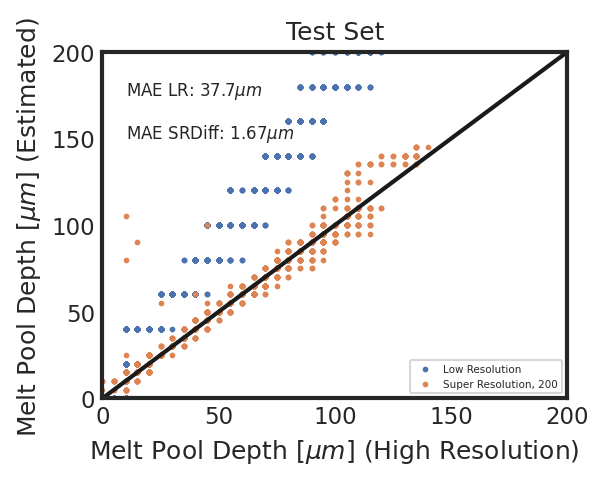

In [61]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(max_depth_gt, max_depth_input, s = 3.0, label = 'Low Resolution')
maes_depth = []
for max_depth, skips in zip(max_depth_diffs, [5,50]):
    plt.scatter(max_depth_gt, max_depth, s = 3.0, label = 'Super Resolution, {}'.format(timesteps//skips))
    # plt.scatter(max_depth_gt, max_depth_enc, s = 3.0, label = 'Super Resolution')
    # plt.scatter(max_depth_gt, max_depth_mbn, s = 3.0, label = 'Super Resolution')

    mae_input = mean_absolute_error(max_depth_gt, max_depth_input)
    mae_depth_diff = mean_absolute_error(max_depth_gt, max_depth)
    maes_depth.append(mae_depth_diff)
    # print(mae_depth_diff, max_depth)
    # mae_depth_enc = mean_absolute_error(max_depth_gt, max_depth_enc)
    # mae_depth_mbn = mean_absolute_error(max_depth_gt, max_depth_mbn)
    plt.xlim(0,200)
    plt.ylim(0,200)
    frame_tick()
plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
plt.title('Test Set')
plt.text(10, 25 + 150,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(10, 25 + 125,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
# plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
# plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )
plt.legend(fontsize = 5, loc = 'lower right')
plt.show()

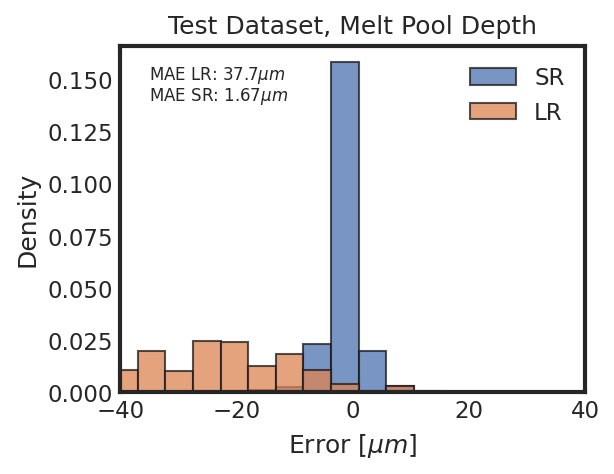

In [63]:
# plt.scatter(max_depth_gt, max_depth_diffs[0])
# plt.plot(max_depth_gt, max_depth_diffs[1], '.')
!pip install seaborn
import seaborn as sns
plt.figure(dpi = 150, figsize = [4,3])
sns.set_theme(style="white", palette=None)
plt.text(-35, 0.150,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(-35, 0.140,r'MAE SR: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
bins=np.histogram(np.hstack((np.array(max_depth_gt) - np.array(max_depth_diffs[0]),np.array(max_depth_gt) - np.array(max_depth_input))), bins=40)[1] #get the bin edges
plt.hist(np.array(max_depth_gt) - np.array(max_depth_diffs[0]), density = True, bins = bins, alpha = 0.75, edgecolor = 'k', label = 'SR')
# plt.show()
plt.hist(np.array(max_depth_gt) - np.array(max_depth_input), density = True, bins = bins, alpha = 0.75, edgecolor = 'k', label = 'LR')
plt.xlim([-40, 40])
plt.ylabel('Density')
plt.legend(frameon  = False)
plt.xlabel(r'Error [$\mu m$]')
plt.title('Test Dataset, Melt Pool Depth')
frame_tick()
plt.show()


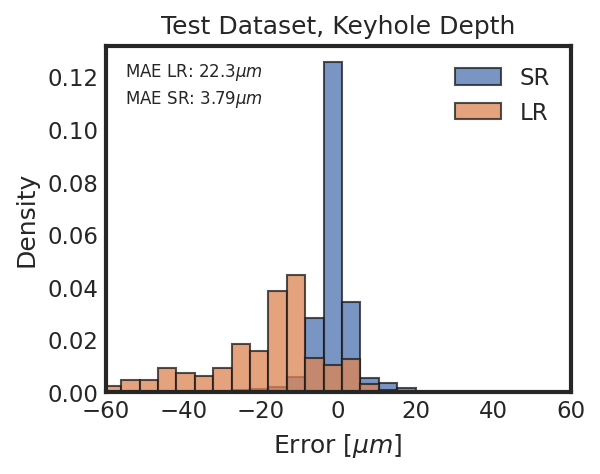

In [71]:
# plt.scatter(max_depth_gt, max_depth_diffs[0])
# plt.plot(max_depth_gt, max_depth_diffs[1], '.')
plt.figure(dpi = 150, figsize = [4,3])
plt.text(-55, 0.120,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(-55, 0.110,r'MAE SR: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
bins=np.histogram(np.hstack((np.array(max_depth_gt) - np.array(max_depth_diffs[0]),np.array(max_depth_gt) - np.array(max_depth_input))), bins=40)[1] #get the bin edges
plt.hist(np.array(kp_depth_gt) - np.array(kp_depth_diffs[0]), density = True, bins = bins, alpha = 0.75, edgecolor = 'k', label = 'SR')
# plt.show()
plt.hist(np.array(kp_depth_gt) - np.array(kp_depth_input), density = True, bins = bins, alpha = 0.75, edgecolor = 'k', label = 'LR')
plt.xlim([-60, 60])
plt.legend(frameon = False)
plt.ylabel('Density')
plt.xlabel(r'Error [$\mu m$]')
plt.title('Test Dataset, Keyhole Depth')
frame_tick()
plt.show()


[3.7854545454545456]


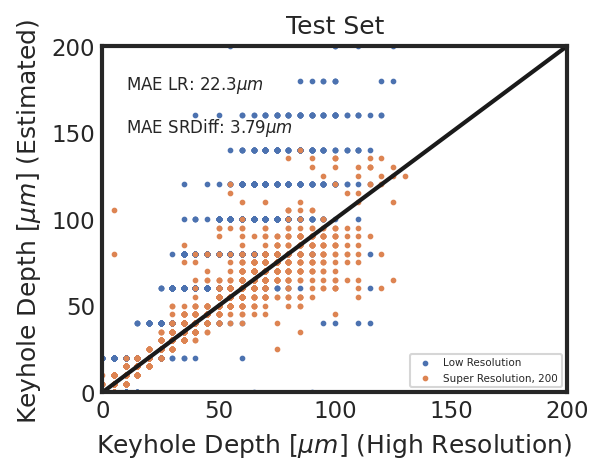

In [66]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(kp_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
maes_depth = []
for kp_depth, skips in zip(kp_depth_diffs, [5,50]):
    plt.scatter(kp_depth_gt, kp_depth, s = 3.0, label = 'Super Resolution, {}'.format(timesteps//skips))
    # plt.scatter(max_depth_gt, max_depth_enc, s = 3.0, label = 'Super Resolution')
    # plt.scatter(max_depth_gt, max_depth_mbn, s = 3.0, label = 'Super Resolution')

    mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
    mae_depth_diff = mean_absolute_error(kp_depth_gt, kp_depth)
    maes_depth.append(mae_depth_diff)
    # print(mae_depth_diff, max_depth)
    # mae_depth_enc = mean_absolute_error(max_depth_gt, max_depth_enc)
    # mae_depth_mbn = mean_absolute_error(max_depth_gt, max_depth_mbn)
    plt.xlim(0,200)
    plt.ylim(0,200)
    frame_tick()
    print(maes_depth)
plt.xlabel(r'Keyhole Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Keyhole Depth [$\mu m]$ (Estimated) ')
plt.title('Test Set')
plt.text(10, 25+ 150,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(10, 25+ 125,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
# plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
# plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )
plt.legend(fontsize = 5, loc = 'lower right')
plt.show()

In [ ]:
import json
plt.figure(dpi =150)
frame_tick()
ssims_diff_loaded = json.load(open('trained_steps_dev_ssims_diff.json'))
ssims_loaded = [np.mean(load) for load in ssims_diff_loaded]
plt.plot(np.array(1500/np.array([1, 2, 3, 5, 10, 15, 20, 50])), ssim_mean_lr*np.ones_like([1, 2, 3, 5, 10, 15, 20, 50]), label = 'Low Resolution Input')

# plt.plot([1, 2, 3, 5, 10, 15, 20, 50], ssim_mean_lr*np.ones_like([1, 2, 3, 5, 10, 15, 20, 50]), label = 'Low Resolution Input')
plt.plot(np.array([500, 1000, 1500,2000]), ssims_loaded, 'rx--', label = 'DDPM Super Resolution Output')
plt.plot(np.array(1500/np.array([1, 2, 3, 5, 10, 15, 20, 50])), ssim_mean_diff, 'kx--', label = 'DDIM Super Resolution Output')
plt.ylim([0, 1])
plt.legend()
plt.xlabel('Sampling Time Reduction Factor')
# plt.xlim([0,52])
plt.ylabel(r'SSIM')
plt.grid()
plt.title("DDIM Sampling, Validation data")

In [ ]:
import json
plt.figure(dpi =150)
frame_tick()
title = '$L_1$ '
fname = 'l1'
field_diff = l1_mean_diff
field_lr = l1_mean_lr
diff_loaded = json.load(open('trained_steps_dev_{}_diff.json'.format(fname)))
loaded = [np.mean(load) for load in diff_loaded]
plt.plot(np.array(1500/np.array([1, 2, 3, 5, 10, 15, 20, 50])), field_lr*np.ones_like([1, 2, 3, 5, 10, 15, 20, 50]), label = 'Low Resolution Input')

# plt.plot([1, 2, 3, 5, 10, 15, 20, 50], ssim_mean_lr*np.ones_like([1, 2, 3, 5, 10, 15, 20, 50]), label = 'Low Resolution Input')
plt.plot(np.array([500, 1000, 1500,2000]), loaded, 'rx--', label = 'DDPM Super Resolution Output')
plt.plot(np.array(1500/np.array([1, 2, 3, 5, 10, 15, 20, 50])), field_diff, 'kx--', label = 'DDIM Super Resolution Output')
plt.ylim([0, 300])
plt.legend()
plt.xlabel('Diffusion Steps')
# plt.xlim([0,52])
plt.ylabel(r'{}'.format(title))
plt.grid()
plt.title("DDIM vs DDPM Sampling, Validation data")

In [ ]:
# print(psnr_mean_lr)
# print(psnr_mean_diff)
# print(ssim_mean_lr)
# print(ssim_mean_diff)
# print(l1_mean_lr)
plt.plot(np.array(sample_times[::16])/16,l1_mean_diff, 'kx--')
plt.xlabel('Sample Generation Time [s]')
plt.ylabel(r'$L_1$ Error [K]')
plt.ylim([0, 100])
plt.xlim([0, 6])
frame_tick()
# plt.plot(sample_times[::16],timesteps/np.array([1, 2, 3, 5, 10, 15, 20, 50]))

# sample_times[::16]
# 128/8


In [ ]:
# plt.plot(sample_diff_steps,psnr_mean_lr)
# plt.plot(sample_diff_steps, psnr_mean_diff)

# ssims_lr
# ssims_diff
import json

In [ ]:
outpath = "psnrs_diff.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(psnrs_diff))
outpath = "psnrs_lr.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(psnrs_lr))
outpath = "ssims_diff.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(ssims_diff))
outpath = "ssims_lr.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(ssims_lr))
outpath = "l1_lr.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(l1_lr_numpy))
outpath = "l1_diff.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(l1_diff_numpy))

In [ ]:
l1_diff_numpy = [[l.item() for l in l1d] for l1d in l1_diff]
l1_lr_numpy = [[l.item() for l in l1d] for l1d in l1_lr]

In [ ]:
outpath = "psnr_lr.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(psnrs_lr))

In [ ]:
ssims_diff_loaded = json.load(open('l1_lr.json'))
ssims_loaded = [np.mean(load) for load in ssims_diff_loaded]
plt.plot(ssims_loaded)

In [ ]:
plt.plot(ssim_mean_lr)
plt.plot(ssim_mean_diff)

In [ ]:
plt.plot(l1_mean_lr)
plt.plot(l1_mean_diff)

In [ ]:
# kp_depth_diffs# get_inst_profile(result_diffusion)
# batch_idx
sample_times

In [ ]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(max_depth_gt, max_depth_input, s = 3.0, label = 'Low Resolution')
maes_depth = []
for max_depth, sim in zip(max_depth_diffs, [simlinear500, simlinear1000, simlinear1500, simlinear2000]):
    plt.scatter(max_depth_gt, max_depth, s = 3.0, label = 'Super Resolution, {}'.format(sim.diff_steps))
    # plt.scatter(max_depth_gt, max_depth_enc, s = 3.0, label = 'Super Resolution')
    # plt.scatter(max_depth_gt, max_depth_mbn, s = 3.0, label = 'Super Resolution')

    mae_input = mean_absolute_error(max_depth_gt, max_depth_input)
    mae_depth_diff = mean_absolute_error(max_depth_gt, max_depth)
    maes_depth.append(mae_depth_diff)
    print(mae_depth_diff, max_depth)
    # mae_depth_enc = mean_absolute_error(max_depth_gt, max_depth_enc)
    # mae_depth_mbn = mean_absolute_error(max_depth_gt, max_depth_mbn)
    plt.xlim(0,300)
    plt.ylim(0,300)
    frame_tick()
plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
# plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
# plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )
plt.legend(fontsize = 5, loc = 'lower right')
plt.show()

In [ ]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(max_depth_gt, max_depth_input, s = 3.0, label = 'Low Resolution')
kps_depth = []
maes_depth = []

for max_depth, sim in zip(max_depth_diffs, [simlinear500, simlinear1000, simlinear1500, simlinear2000]):
    plt.scatter(max_depth_gt, max_depth, s = 3.0, label = 'Super Resolution, {}'.format(sim.diff_steps))
    # plt.scatter(max_depth_gt, max_depth_enc, s = 3.0, label = 'Super Resolution')
    # plt.scatter(max_depth_gt, max_depth_mbn, s = 3.0, label = 'Super Resolution')

    mae_input = mean_absolute_error(max_depth_gt, max_depth_input)
    mae_depth_diff = mean_absolute_error(max_depth_gt, max_depth)
    maes_depth.append(mae_depth_diff)
    print(mae_depth_diff, max_depth)
    kps_depth.append()
    # mae_depth_enc = mean_absolute_error(max_depth_gt, max_depth_enc)
    # mae_depth_mbn = mean_absolute_error(max_depth_gt, max_depth_mbn)
    plt.xlim(0,300)
    plt.ylim(0,300)
    frame_tick()
plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
# plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
# plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )
plt.legend(fontsize = 5, loc = 'lower right')
plt.show()

In [ ]:
plt.plot(steps_list[::12], maes_depth, '.')
frame_tick()
plt.xlabel('Sampling Timesteps')
plt.ylabel(r'$L_1$ Error: Melt Pool Depth')
plt.show()
frame_tick()

plt.plot(steps_list[::12], sample_times[::12], '.')
plt.xlabel('Sampling Timesteps')
plt.ylabel(r'Elapsed Time (s)')
plt.show()


plt.plot(steps_list[::12], maes_depth, '.')
frame_tick()
plt.xlabel('Sampling Timesteps')
plt.ylabel(r'$L_1$ Error: Melt Pool Depth')
plt.show()
frame_tick()


In [ ]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(kp_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(kp_depth_gt, kp_depth_diff, s = 3.0, label = 'Super Resolution')
plt.scatter(kp_depth_gt, kp_depth_enc, s = 3.0, label = 'Super Resolution')
plt.scatter(kp_depth_gt, kp_depth_mbn, s = 3.0, label = 'Super Resolution')


mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
mae_depth_diff = mean_absolute_error(kp_depth_gt, kp_depth_diff)
mae_depth_enc = mean_absolute_error(kp_depth_gt, kp_depth_enc)
mae_depth_mbn = mean_absolute_error(kp_depth_gt, kp_depth_mbn)
plt.xlim(0,300)
plt.ylim(0,300)
frame_tick()
plt.xlabel(r'Keyhole Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Keyhole Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )   
plt.show()

In [ ]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(kp_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(kp_depth_gt, kp_depth_diff, s = 3.0, label = 'Super Resolution')
plt.scatter(kp_depth_gt, kp_depth_enc, s = 3.0, label = 'Super Resolution')

mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
mae_depth = mean_absolute_error(kp_depth_gt, kp_depth_enc)

plt.xlim(0,300)
plt.ylim(0,300)
frame_tick()
plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
plt.title('Test Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input) )
plt.text(25, 225,r'MAE SR: {:.03}$\mu m$'.format(mae_depth) )
plt.show()

In [ ]:
def plot_temp_lines(input, result, target, modeltype, split = 'train'):
    scaling_factor = 1.5
    dpi = 90
    min_temp = 293
    max_temp = 8000
    method = 'direct'
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)
    plt.title(r'{} model, Cross section: x = 200 $\mu m$'.format(modeltype))
    plt.plot(80*5*(np.arange(input.shape[-1])/input.shape[-1]),input[0][10,:],label = 'Low-Resolution Input')
    plt.plot(80*5*(np.arange(target.shape[-1])/target.shape[-1]),target[40,:], label = 'High-Resolution Input') 
    plt.plot(80*5*(np.arange(target.shape[-1])/target.shape[-1]),result[40,:], label = 'Output')
    legend()
    plt.ylabel(r'$T [K]$')
    plt.xlabel(r'$z [\mu m$]')
    frame_tick()
    plt.ylim(min_temp, max_temp)
    plt.xlim(0, 400)
    plt.show()
plot_temp_lines(input, result_diffusion[0], target[0][0], split = 'test', modeltype = "Diffusion")
plot_temp_lines(input, lr_enc_result[0][0], target[0][0], split = 'test', modeltype = "Encoder")


In [ ]:
def plot_srdiff_contours(input, result, target, modeltype, split = 'train', max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Direct'):
    profile_result, kp_result = get_profile(result)

    profile_gt, kp_gt = get_profile(target)
    profile_input, kp_input = get_profile(input, mesh = 20)

    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20), kp_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80), kp_result*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80), kp_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()

    legend()
    plt.title('[{} Data] Keyhole Depth, {}'.format(split, modeltype), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    plt.show()

    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),profile_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80), profile_result*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80),profile_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()

    legend()
    plt.title('[{} Data] Melt Pool Depth, {}'.format(split, modeltype), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    plt.show()
input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
print(input.shape)
input, result_diffusion, target = predict_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, train_dataset)
input, result_mobilenet, target = predict_mobilenet(mobilenet,res, hr, lr, upscaled_lr, train_dataset)
plot_srdiff_contours(input, result_diffusion, target[0], split = 'Train', modeltype = "Diffusion")
plot_srdiff_contours(input, lr_enc_result, target[0], split = 'Train', modeltype = "Encoder")
plot_srdiff_contours(input, result_mobilenet, target[0], split = 'Train', modeltype = "MobileNet")


plot_images(input[0], lr_enc_result[0,0], target[0][0], split = 'Train', modeltype = "Encoder")
plot_images(input[0], result_mobilenet[0,0], target[0][0], split = 'Train', modeltype = "MobileNetSISR")
plot_images(input[0], result_diffusion[0], target[0][0], split = 'Train', modeltype = "Diffusion")


In [ ]:
profile_result, kp_result = get_profile(result_diffusion)
profile_mbn_result, kp_mbn_result = get_profile(result_mobilenet)
profile_enc_result, kp_enc_result = get_profile(lr_enc_result)
plt.step(5*np.arange(80), profile_result - 400, label = 'Super Resolution (Output)' )
plt.step(5*np.arange(80), profile_enc_result - 400, label = 'Super Resolution (Output)' )
plt.step(5*np.arange(80), profile_mbn_result - 400, label = 'Super Resolution (Output)' )


In [ ]:
lrpsnrs = []

lrencpsnrs = []
diffpsnrs = []
mobilenetpsnrs = []
lrl1loss = []
lrencl1loss = []
diffl1loss = []
mobilenetl1loss= []
mobilenetssims = []
lrssims = []
diffssims = []
lrencssims = []


def SSIM(op, t, batch_size):
    ssim = 0 
    print(op.shape, t.shape)
    for i in range(op.shape[0]):

        # print(out[0,0].size())
        # print(op.shape, t.shape)
        if isinstance(op, torch.Tensor):
            score = ssim_id(op[0][0].detach().cpu().numpy(), t[0][0].detach().cpu().numpy())#, full=True)
        else:
            print(op[0].shape,t[0][0].detach().cpu().numpy().shape)
            score = ssim_id(op[0], t[0][0].detach().cpu().numpy())#, full=True)
        ssim+=score/batch_size
    
        #print("SSIM: {}".format(score))
    return ssim
l1loss = nn.L1Loss()
for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dev_dataloader):  
    upscale = dev_dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr')
    input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, dev_dataset)
    print(input.shape)
    input, result_diffusion, target = predict_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,dev_dataset)
    input, result_mobilenet, target = predict_mobilenet(mobilenet,res, hr, lr, upscaled_lr, dev_dataset)
    
    lrpsnr = PSNR(upscale, target, target.shape[0]).item()
    lrencpsnr = PSNR(lr_enc_result, target, target.shape[0]).item()

    diffpsnr = PSNR(result_diffusion, target, target.shape[0]).item()

    mobilenetpsnr = PSNR(result_mobilenet, target, target.shape[0]).item()

    print('LR PSNR: ', lrpsnr)
    print('LR enc PSNR: ',PSNR(lr_enc_result, target, target.shape[0])) 
    print('Diffusion PSNR: ',PSNR(result_diffusion, target, target.shape[0])) 
    print('MobileNet PSNR: ',PSNR(result_mobilenet, target, target.shape[0])) 
    print('LR SSIM: ',  SSIM(upscale.view(upscale.shape[0],1 , upscale.shape[1], upscale.shape[2]), target, target.shape[0]))
    print('LR enc SSIM: ',  SSIM(lr_enc_result, target, target.shape[0]))
    print('Diffusion SSIM: ',  SSIM(result_diffusion, target, target.shape[0]))
    print('MobileNet SSIM: ',  SSIM(result_mobilenet, target, target.shape[0]))
    lrssim = SSIM(upscale.view(upscale.shape[0],1 , upscale.shape[1], upscale.shape[2]), target, target.shape[0])
    lrencssim = SSIM(lr_enc_result, target, target.shape[0])
    diffssim = SSIM(result_diffusion, target, target.shape[0])
    mobilenetssim = SSIM(result_mobilenet, target, target.shape[0])

    (lr_enc_result, target)
    lrpsnrs.append(lrpsnr)
    lrencpsnrs.append(lrencpsnr)
    diffpsnrs.append(diffpsnr)
    lrssims.append(lrssim)#SSIM(lr_enc_result.view(lr_enc_result.shape[0],1 , lr_enc_result.shape[1], lr_enc_result.shape[2]), target, target.shape[0]))
    lrencssims.append(lrencssim)

    diffssims.append(diffssim)
    mobilenetssims.append(mobilenetssim)


    mobilenetpsnrs.append(mobilenetpsnr)
    lrl1loss.append(l1loss(upscale, target[:,0]).item())
    lrencl1loss.append(l1loss(lr_enc_result[:,0], target[:,0]).item())
    diffl1loss.append(l1loss(torch.tensor(result_diffusion), target[:,0]).item())
    mobilenetl1loss.append(l1loss(torch.tensor(result_mobilenet[:,0]), target[:,0]).item())





In [ ]:
isinstance(lr_enc_result, torch.Tensor)

In [ ]:
print(np.mean(lrl1loss))

In [ ]:
print(np.mean(lrencl1loss))

In [ ]:
print(np.mean(diffl1loss))

In [ ]:
print(np.mean(diffssims))
print(np.mean(mobilenetssims))
print(np.mean(lrencssims))
print(np.mean(lrssims))


In [ ]:
print(np.mean(mobilenetl1loss))


In [ ]:
np.mean(lrpsnrs)


In [ ]:
np.mean(lrencpsnrs)


In [ ]:
np.mean(mobilenetpsnr)


In [ ]:
np.mean(diffpsnrs)


In [ ]:
from skimage.metrics import structural_similarity as ssim_id
def SSIM(op, t, batch_size):
    ssim = 0 
    for i in range(op.shape[0]):

        score = ssim_id(op[0], t[0])#, full=True)
        ssim+=score/batch_size
    
        #print("SSIM: {}".format(score))
    return ssim
print('LR SSIM: ',  SSIM(lr_data, hr, hr.shape[0]))
print('SR SSIM: ',  SSIM(generated_hr, hr, hr.shape[0]))